# Dealer-direction inference on the CFTC Part 43 USD swap tape

**Per-trade direction with a calibrated probability, a signed key-rate DV01
profile, and a daily street-positioning indicator.**

This notebook is a walk-through of a pipeline that already exists
(`SDRUtils/dealer_direction/*`, ~1,090 tests green) and of the research that has
been run on it. It is a narrative, not a demo: it states the convention, traces
a single print all the way from the tape to a signed risk vector, then scales
that to a universe, a calibration, a risk ladder and a daily indicator — and
finishes with the four registered studies, three of which are dead and one of
which is uninformative.

---

## The one rule that governs every number below

> **A number printed here is either recomputed in front of you, or it was loaded
> from a file listed in [`data/PROVENANCE.md`](data/PROVENANCE.md) — and where a
> cell computes *on* an input it did not produce, the banner names that input
> and cites it. There is no fourth case.**

Every cell carries a banner:

| banner | meaning |
|---|---|
| `COMPUTED` | this cell ran the pipeline (or the estimator) just now, in this kernel, on inputs it also produced |
| `LOADED` | this cell read a precomputed artefact; the `§` cites `data/PROVENANCE.md` |
| `COMPUTED (on …)` | computed here, but on an input that was **not**. The printed banner carries a `NOT COMPUTED HERE:` line naming the file and its `data/PROVENANCE.md` section |

**Two inputs make that third case real, and both are far too large to sit in
`data/`. They are `data/PROVENANCE.md` §7:**

* **§7.1 — the calibration.** `tau`, `b0` and the dead zone — and therefore `p`,
  the weight `2p-1` and every `delta_dv01` — are **unpickled** from
  `D:\dd_signals_cache\s2_pos\calibrations.pkl`: `s2_positioning`'s rolling
  fits on a strictly-prior 60-day window. **Nothing in this kernel fits them.**
  It is the single most consequential input in the notebook, and §5's 397 bucket
  fits, its gate counts and its pooling ladder are all read off it.
* **§7.2 — the stage cache.** `price_units` and `krd_frame` are served from
  `D:\ddnb_cache\stage\<digest>` whenever the digest matches. That digest
  hashes every `SDRUtils/dealer_direction/*.py` plus the whole text of
  `dd_nb.py`, so the cache **cannot be stale** — but "cannot be stale" is not
  "computed in front of you", and §1 prints, per stage, which of the two this
  run was.

`LOADED` cells never re-run a registered test. Re-running a pre-registered study
on a different window and reporting the new number is not a robustness check, it
is a second draw; loading is honest, so the R0/R0b/S1/S2 results below are read
off the files the studies wrote and are labelled as such.

## The tape is read **read-only**

The tape is remote **production** Supabase. This notebook opens one read-only
`SELECT` (`universe.LEGS_SQL`, via `dd_nb.load_legs`) and writes **nothing** to
it — no `INSERT`, no `UPDATE`, no DDL, no temp tables. In practice it does not
even read: the three pilot days are cached to `D:\ddnb_cache\legs` and the run
below is served from that cache.

## The pinned convention

```
customer pays fixed  ->  dealer RECEIVED fixed  ->  dealer long duration  ->  delta_dv01 > 0
p            = p(customer paid fixed)
ladder weight = signed_weight(p) = 2p - 1
```

A flipped sign here produces a complete, plausible, exactly-wrong ladder, so
§2 does not assert the convention — it reproduces the frozen predecessor on
every case that predecessor supports.

---
# 1. Setup and provenance

The window is configurable in **one place**, immediately below — and it is the
only thing configured by hand. `NB_DIR` is **derived** from the kernel's working
directory (override: `DD_NB_DIR`) and *raises* rather than guessing, because
`dd_nb.py` sets `REPO` from its own location and a wrong `NB_DIR` would silently
run one checkout's pipeline against another's caches. `CACHE_DIR` is pinned to
`D:\ddnb_cache` deliberately — `C:` has run to zero twice — and outputs go to
`NB_DIR/_out/`.

In [1]:
# ============================ COMPUTED ============================
# Environment, paths and the one place the window is configured.
import os

os.environ["ARBS_SUPABASE_ENABLED"] = "0"          # before anything imports Caching
os.environ["ARBS_CITIVELO_QUOTES_OFFLINE"] = "1"   # never open Excel
os.environ.setdefault("TMPDIR", "D:/ddnb_cache/tmp")

import pathlib
import subprocess
import sys
import textwrap
import time
import warnings


def _find_nb_dir() -> pathlib.Path:
    """This notebook's own directory, DERIVED -- not pinned to one checkout.

    Jupyter hands a kernel no path to its own notebook, so this searches, in
    order: the `DD_NB_DIR` override, then the working directory and its parents
    (nbconvert and `jupyter lab` both start the kernel in the notebook's own
    directory), then any `notebooks/dealer_direction` beneath them. A candidate
    only counts if it holds BOTH `dd_nb.py` and `data/PROVENANCE.md`.

    It RAISES rather than guessing. `dd_nb.py` derives `REPO` from its own
    location, so a wrong directory here would import a different checkout's
    pipeline and point it at this one's caches -- silently.
    """
    cands = []
    env = os.environ.get("DD_NB_DIR")
    if env:
        cands.append(pathlib.Path(env))
    here = pathlib.Path.cwd().resolve()
    for base in (here, *here.parents):
        cands += [base, base / "notebooks" / "dealer_direction"]
    for c in cands:
        if (c / "dd_nb.py").exists() and (c / "data" / "PROVENANCE.md").exists():
            return c.resolve()
    raise RuntimeError(
        f"cannot locate notebooks/dealer_direction from cwd {here}. Start the "
        "kernel in the notebook's own directory, or set DD_NB_DIR.")


NB_DIR = _find_nb_dir()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

# ---------------------------------------------------------------- THE WINDOW
WINDOW_START = "2025-06-16"        # <- change these two lines and nothing else
WINDOW_END   = "2025-06-18"
CACHE_DIR    = pathlib.Path(r"D:\ddnb_cache")
OUT_DIR      = NB_DIR / "_out"
DATA_DIR     = NB_DIR / "data"
# ----------------------------------------------------------------------------

OUT_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib
import numpy as np
import pandas as pd

import dd_nb

REPO = pathlib.Path(dd_nb.REPO)

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "figure.figsize": (10.5, 4.2),
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10, "axes.titlesize": 11,
    "legend.frameon": False,
})
pd.set_option("display.width", 190, "display.max_columns", 60,
              "display.float_format", lambda v: f"{v:,.6g}")

WARN = "\N{WARNING SIGN}"


def banner(kind: str, what: str, cite: str = "", inputs: str = "") -> None:
    """Provenance banner. `kind` is COMPUTED or LOADED.

    `inputs` names anything this cell's numbers depend on that it did NOT
    produce -- the s2 calibration pickle, the stage cache. A cell computing on
    a loaded input is neither a `LOADED` cell nor a plain `COMPUTED` one, and
    the difference belongs on the banner rather than in a stage timing the
    reader has to know to look at.
    """
    tail = f"   [{cite}]" if cite else ""
    print(f"--- {kind}: {what}{tail}")
    for line in (inputs.split("\n") if inputs else []):
        print(f"    NOT COMPUTED HERE: {line}")
    print()


# What the banners above name. Cell 5 rebinds these to what THIS run actually
# did, once the pipeline has run and can be asked.
CALIB_IN = (r"s2's rolling calibrations, unpickled from "
            r"D:\dd_signals_cache\s2_pos\calibrations.pkl"
            "  [data/PROVENANCE.md §7.1]"
            "  -- sets tau, b0, the dead zone and therefore p on every call")
STAGE_IN = (r"pipeline stages may be served from the stage cache "
            r"D:\ddnb_cache\stage\<digest>"
            "  [data/PROVENANCE.md §7.2]"
            "  -- pipe.timings.source says which were, on THIS run")
BOTH_IN = CALIB_IN + "\n" + STAGE_IN


def load_artifact(path, section: str, reader=None, **kw):
    """Read a precomputed artefact and say so. `section` cites data/PROVENANCE.md."""
    p = pathlib.Path(path)
    rel = p.relative_to(REPO) if p.is_relative_to(REPO) else p
    if reader is None:
        reader = (pd.read_csv if p.suffix == ".csv"
                  else pd.read_parquet if p.suffix == ".parquet"
                  else (lambda q, **k: pathlib.Path(q).read_text(
                      encoding="utf-8", errors="replace")))
    obj = reader(p, **kw)
    n = f"{len(obj):,} rows" if isinstance(obj, pd.DataFrame) else f"{len(obj):,} chars"
    print(f"--- LOADED: {rel}  ({n})   [data/PROVENANCE.md {section}]\n")
    return obj


def savefig(fig, name: str):
    """Persist a figure under _out/ as well as showing it inline."""
    p = OUT_DIR / f"{name}.png"
    fig.savefig(p, bbox_inches="tight")
    return p


def head(df, n=12, **kw):
    return df.head(n).to_string(index=False, **kw)


def git(*args) -> str:
    return subprocess.run(["git", "-C", str(REPO), *args],
                          capture_output=True, text=True).stdout.strip()


print(f"python        {sys.version.split()[0]}")
print(f"numpy         {np.__version__}    pandas {pd.__version__}    "
      f"matplotlib {matplotlib.__version__}")
try:
    import rateslib
    print(f"rateslib      {rateslib.__version__}")
except Exception as exc:                                    # pragma: no cover
    print(f"rateslib      unavailable ({exc})")
print(f"repo          {REPO}")
print(f"branch        {git('rev-parse', '--abbrev-ref', 'HEAD')}   "
      f"@ {git('rev-parse', '--short', 'HEAD')}")
print(f"window        {WINDOW_START} .. {WINDOW_END}")
print(f"cache         {CACHE_DIR}")
print(f"notebook dir  {NB_DIR}   (derived; override with DD_NB_DIR)")
print(f"outputs       {OUT_DIR}")

C:\Users\chris\clee\ARBS-dd\Query\IRSwaps\IRSwapStructure.py:12: LicenceNotice: 
Rateslib is source-available (not open-source) software distributed under a dual-licence model.
No commercial licence is registered for this installation. Use is therefore permitted for non-commercial purposes only (at-home or university based academic use).
Any use in commercial, professional, or for-profit environments, including evaluation or trial use, requires a valid commercial licence or an approved evaluation licence.
Certain features may require a registered commercial or evaluation licence in current or future versions.
For licensing information or to register a licence, please visit: https://rateslib.com/licence
  from rateslib.scheduling import get_imm, next_imm


python        3.13.5
numpy         2.2.6    pandas 2.3.1    matplotlib 3.10.5
rateslib      2.7.1
repo          C:\Users\chris\clee\ARBS-dd
branch        feat/dealer-direction   @ c0c8a615
window        2025-06-16 .. 2025-06-18
cache         D:\ddnb_cache
notebook dir  C:\Users\chris\clee\ARBS-dd\notebooks\dealer_direction   (derived; override with DD_NB_DIR)
outputs       C:\Users\chris\clee\ARBS-dd\notebooks\dealer_direction\_out


In [2]:
# ============================ COMPUTED ============================
# Which tape, and the read-only promise, stated in code.
from SDRUtils._swappulse_scripts import _tape_tables as tt

banner("COMPUTED", "tape generation and the SQL this notebook issues")

names = {k: v for k, v in vars(tt).items()
         if k.isupper() and isinstance(v, str) and not k.startswith("_")}
for k, v in sorted(names.items()):
    print(f"  {k:<28} {v}")

from SDRUtils.dealer_direction import universe

sql = universe.LEGS_SQL
verbs = [w for w in ("INSERT", "UPDATE", "DELETE", "CREATE", "DROP", "ALTER",
                     "TRUNCATE", "GRANT", "COPY")
         if w in sql.upper()]
print(f"\n  the only statement issued against the tape is {sql.strip().split()[0]!r}, "
      f"{len(sql.splitlines())} lines")
print(f"  write verbs present in it: {verbs or 'NONE'}")
assert not verbs, "the tape query must be read-only"
print("\n  and it is not even read here: the three pilot days are served from")
print(f"  {CACHE_DIR / 'legs'}")
print("  credentials -- needed ONLY if that cache is cold -- are resolve_pg_url's "
      "own ladder:\n  DATABASE_URL, else PG_URL, else the SWAPPULSE_DB_* defaults."
      "   [data/PROVENANCE.md §7.3]")

# ---------------------------------------------------------------------------
# The legs cache is not the only thing this notebook reads rather than computes,
# and disclosing only the one the section happens to be about narrows the
# reader's expectation to exactly the wrong place. The full list:
# ---------------------------------------------------------------------------
print("\n  EVERYTHING READ RATHER THAN COMPUTED   [data/PROVENANCE.md §7]:")
for _sec, _path, _what in (
        ("§7.1", dd_nb.S2_CALIBRATIONS,
         "s2's rolling calibrations -- tau, b0, dead zone, hence p on EVERY call"),
        ("§7.2", CACHE_DIR / "stage",
         "stage cache: the price_units and krd_frame stages, per tape day"),
        ("§7.3", CACHE_DIR / "legs",
         "the tape itself, the three pilot days")):
    _p = pathlib.Path(_path)
    if _p.is_file():
        _size = f"{_p.stat().st_size / 1e6:,.1f} MB"
    elif _p.is_dir():
        _size = f"{sum(1 for q in _p.rglob('*') if q.is_file()):,} files"
    else:
        _size = "ABSENT"
    print(f"    {_sec}  {str(_p):<44} {_size:>10}   {_what}")
print("  The stage cache is content-keyed on every SDRUtils/dealer_direction/*.py "
      "plus dd_nb.py,\n  so it cannot serve a mark produced by different code. "
      "That is not the same as having been\n  computed in front of you, and "
      "section 1 prints which stages were which on this run.")

--- COMPUTED: tape generation and the SQL this notebook issues

  DISPLAY_VIEW                 arbs_usd_swap_tape_display_v3
  IDX_INFIX                    v3
  LEGS_TABLE                   arbs_usd_swap_tape_legs_v3
  MANUAL_LINKS_TABLE           arbs_usd_swap_manual_links_v2
  NOTES_TABLE                  arbs_usd_swap_tape_notes_v3
  OVERRIDES_TABLE              arbs_usd_swap_tape_overrides_v3
  OVERRIDE_HISTORY_TABLE       arbs_usd_swap_tape_override_history_v3
  OVERRIDE_MEMBERS_TABLE       arbs_usd_swap_tape_override_members_v3
  PACKAGES_TABLE               arbs_usd_swap_tape_packages_v3
  QUALITY_VIEW                 arbs_usd_swap_tape_quality_daily_v3
  RUNS_TABLE                   arbs_usd_swap_tape_ingestion_runs_v3
  SIGNAL_TABLE                 arbs_usd_swap_tape_signal_v3
  TAPE_GENERATION              v3
  VWAP_TABLE                   arbs_usd_swap_vwap_daily_v3

  the only statement issued against the tape is 'SELECT', 5 lines
  write verbs present in it: NONE

  and it

## The pilot window, and why it is these three days

`2025-06-16 .. 2025-06-18` — Monday to Wednesday of the June 2025 FOMC. It was
chosen by measurement, not convenience (`scratch/nbhelp_probe1.py`, `probe2`,
`probe3`), against five requirements:

* **Post-2024-07**, so the tape carries termination events at all (before that
  it carries none, and a lifecycle series would be empty for a reason that is
  not the market).
* **Inside s2's design sample** (2024-03-01 .. 2025-08-22). That keeps the
  hold-out (2025-09-01 .. 2026-08-07) shut, and it lets the calibration below be
  a genuinely *trailing* one rather than an in-window fit.
* **Recovered `PKG-N` packages on every day** (13 over the window) against 159
  `PKG-4+` refused for `PKG_SIGNS_AMBIGUOUS` — so both sides of the
  identification gate are visible.
* **Both venue classes plus the `VENUE_UNKNOWN` residual, every day**, 242
  lifecycle units, and **1,604 kept units carrying an upfront** over the window.
  Note what that 1,604 is and is not: it is the *universe* count
  (`n_upfront_kept`, **all** rate indices). The upfront-**rule** population is
  smaller, because pricing is SOFR-only — **1,537** units route to
  `NPV_VS_UPFRONT` (1,522 called + 15 `NO_CURVE`), and 13 further units that
  carry an upfront route to `PACKAGE_PRICE_VS_MODEL` instead. §6 reconciles the
  two counts in code rather than asking you to take this paragraph's word.
* **One clean day and one holed day**: 06-16 prices 100%, 06-17 prices 94.46%.
  The contrast is what the coverage panel needs.

Three days is a *walk-through* sample. Nothing in §1–§8 is a signal claim; the
signal claims are in §9 and they are loaded from studies run on 610 days
(universe), 18 months (S1/S2) and 67 CME sessions (R0/R0b).

In [3]:
# ==== COMPUTED  (stage cache §7.2, LOADED s2 calibration §7.1) ====
# The whole pipeline: legs -> units -> marks -> calls -> risk -> ladder -> daily.
cfg = dd_nb.config(start=WINDOW_START, end=WINDOW_END,
                   cache_dir=CACHE_DIR, out_dir=OUT_DIR)

banner("COMPUTED", f"dd_nb.run_pipeline over {cfg.window}", inputs=BOTH_IN)

_t0 = time.perf_counter()
pipe = dd_nb.run_pipeline(cfg)
PIPELINE_WALL = time.perf_counter() - _t0

DAYS = dd_nb.tape_days(pipe.legs)
print(f"source digest {pipe.digest}   (hashes every SDRUtils/dealer_direction/*.py "
      f"plus dd_nb.py plus the config knobs that change a number)")
print(f"tape days     {DAYS}")
print(f"calibration   {pipe.taus.mode}\n")
print(pipe.timings.to_string(index=False, float_format=lambda v: f"{v:8.2f}"))
print(f"\ntotal {PIPELINE_WALL:.1f}s  ({PIPELINE_WALL / len(DAYS):.1f}s per tape day)")

# --- WHICH STAGES WERE COMPUTED, AND WHICH WERE READ ------------------------
# Without this the only clue is the stopwatch -- price_units at a few
# hundredths of a second against build_units at three seconds -- and nobody
# should have to infer provenance from a timing.
print("\nwhere each stage's rows came from:")
print(pipe.cache.to_string(index=False))
print("  taus is never fitted here in trailing_s2 mode; price_units and "
      "krd_frame are the only\n  cached stages, keyed on the source digest "
      "above.   [data/PROVENANCE.md §7.1, §7.2]")

# From here on the banners describe THIS run rather than a typical one.
CALIB_IN = (
    (f"tau / b0 / dead zone -- hence p and every weight -- LOADED from "
     f"{cfg.s2_calibrations}"
     "  [data/PROVENANCE.md §7.1]; nothing in this kernel fits them")
    if pipe.taus.mode == dd_nb.CALIB_TRAILING else
    (f"tau / b0 / dead zone FITTED in this kernel on the window's own "
     f"deviations (mode {pipe.taus.mode}) -- NOT trailing"))
_read = [r.stage for r in pipe.timings.itertuples() if r.source != "COMPUTED"
         and r.stage != "taus"]
STAGE_IN = (
    (f"stages served from disk on this run: {', '.join(_read)}"
     r"   (D:\ddnb_cache)  [data/PROVENANCE.md §7.2, §7.3]")
    if _read else
    ("every pipeline stage was computed in this kernel on this run -- the "
     "stage cache was cold  [data/PROVENANCE.md §7.2]"))
BOTH_IN = CALIB_IN + "\n" + STAGE_IN

--- COMPUTED: dd_nb.run_pipeline over 2025-06-16_2025-06-18
    NOT COMPUTED HERE: s2's rolling calibrations, unpickled from D:\dd_signals_cache\s2_pos\calibrations.pkl  [data/PROVENANCE.md §7.1]  -- sets tau, b0, the dead zone and therefore p on every call
    NOT COMPUTED HERE: pipeline stages may be served from the stage cache D:\ddnb_cache\stage\<digest>  [data/PROVENANCE.md §7.2]  -- pipe.timings.source says which were, on THIS run



source digest 8656e57e3e28   (hashes every SDRUtils/dealer_direction/*.py plus dd_nb.py plus the config knobs that change a number)
tape days     ['2025-06-16', '2025-06-17', '2025-06-18']
calibration   trailing_s2

      stage  seconds  rows_out   source
  load_legs     0.03     11027    CACHE
build_units     3.14      6893 COMPUTED
price_units     0.07      5032    CACHE
       taus     0.09         3   LOADED
   classify     0.96      5032 COMPUTED
  krd_frame     0.08    138012    CACHE
ladder_rows     3.74    138012 COMPUTED
      daily     0.61       190 COMPUTED

total 8.7s  (2.9s per tape day)

where each stage's rows came from:
      stage source  days_read  days_computed                                                                   served_from
  load_legs  CACHE          1              0                         D:\ddnb_cache\legs\legs_2025-06-16_2025-06-18.parquet
price_units  CACHE          3              0                D:\ddnb_cache\stage\8656e57e3e28\2025-06-16_2025-

---
# 2. The convention, demonstrated rather than asserted

```
customer pays fixed  ->  dealer RECEIVED fixed  ->  dealer long duration  ->  delta_dv01 > 0
```

`conventions.dealer_received_signs(kind, n_legs, rule, dealer_sign)` returns the
**per-leg** sign: `+1` on a leg means the dealer received fixed on that leg. A
`CURVE` received is `(-1, +1)` — receive the back leg, pay the front — and a
`FLY` received is `(-1, +1, -1)`: receive the belly, pay the wings. Under the
`NPV_VS_UPFRONT` rule the frame is net-fixed and every leg carries the same
sign.

None of that is asserted here. `SDRUtils/stir_flow/ladder_conventions.py` is the
**frozen predecessor** — the convention the persisted STIR ladder was built
under — and the generalisation has to agree with it leg-for-leg on every case it
covers. The cell below runs that comparison live.

> **The first draft of `dealer_received_signs` inverted every leg of every
> structure at once.** A global sign flip is exactly the defect that a
> self-consistent pipeline cannot see: the ladder still balances, the weights
> still sum, `delta_dv01 == (2p-1) * dv01_if_received` still holds to 1e-15, and
> the resulting positioning series is complete, plausible and exactly backwards.
> It was this comparison against the frozen function — nothing internal — that
> caught it.

In [4]:
# ============================ COMPUTED ============================
# Reproduce the frozen predecessor on every case it supports.
from SDRUtils.dealer_direction import conventions as conv
from SDRUtils.stir_flow import ladder_conventions as frozen

banner("COMPUTED",
       "conventions.dealer_received_signs vs stir_flow.ladder_conventions."
       "dealer_leg_signs")

CASES = [("OUTRIGHT", 1, conv.RULE_RATE), ("CURVE", 2, conv.RULE_RATE),
         ("FLY", 3, conv.RULE_RATE),
         ("OUTRIGHT", 1, conv.RULE_UPFRONT), ("CURVE", 2, conv.RULE_UPFRONT),
         ("FLY", 3, conv.RULE_UPFRONT),
         ("PKG", 2, conv.RULE_UPFRONT), ("PKG", 4, conv.RULE_UPFRONT),
         ("PKG", 7, conv.RULE_UPFRONT)]

rows = []
for kind, n, rule in CASES:
    for direction in ("RECEIVED", "PAID"):
        side = conv.DEALER_RECEIVED if direction == "RECEIVED" else conv.DEALER_PAID
        method = "NPV_VS_UPFRONT" if rule == conv.RULE_UPFRONT else "RATE_VS_MID"
        want = list(frozen.dealer_leg_signs(kind, method, direction, n))
        got = list(conv.dealer_received_signs(kind, n, rule, side))
        rows.append({"kind": kind, "n_legs": n, "rule": rule,
                     "dealer": direction, "frozen": tuple(want),
                     "dealer_direction": tuple(got), "match": want == got})
cmp = pd.DataFrame(rows)
print(cmp.to_string(index=False))
n_ok = int(cmp["match"].sum())
print(f"\n{n_ok}/{len(cmp)} cases reproduce the frozen convention leg-for-leg")
assert cmp["match"].all(), "the generalisation disagrees with the frozen predecessor"

# and the inversion the first draft shipped: what it would have looked like
inverted = {k: tuple(-s for s in v) for k, v in
            zip(cmp["kind"] + "-" + cmp["n_legs"].astype(str) + "/" + cmp["dealer"],
                cmp["dealer_direction"])}
print("\nwhat a global sign flip would have produced (the first draft):")
for k in list(inverted)[:4]:
    print(f"  {k:<20} {inverted[k]}")
print("  ... internally consistent, and wrong on every leg of every structure.")

--- COMPUTED: conventions.dealer_received_signs vs stir_flow.ladder_conventions.dealer_leg_signs

    kind  n_legs           rule   dealer                       frozen             dealer_direction  match
OUTRIGHT       1    RATE_VS_MID RECEIVED                         (1,)                         (1,)   True
OUTRIGHT       1    RATE_VS_MID     PAID                        (-1,)                        (-1,)   True
   CURVE       2    RATE_VS_MID RECEIVED                      (-1, 1)                      (-1, 1)   True
   CURVE       2    RATE_VS_MID     PAID                      (1, -1)                      (1, -1)   True
     FLY       3    RATE_VS_MID RECEIVED                  (-1, 1, -1)                  (-1, 1, -1)   True
     FLY       3    RATE_VS_MID     PAID                   (1, -1, 1)                   (1, -1, 1)   True
OUTRIGHT       1 NPV_VS_UPFRONT RECEIVED                         (1,)                         (1,)   True
OUTRIGHT       1 NPV_VS_UPFRONT     PAID              

In [5]:
# ============================ COMPUTED ============================
# The weight, the side, and the dead zone -- the three scalar conventions.
banner("COMPUTED", "conventions.signed_weight / dealer_side")

from SDRUtils.dealer_direction import probability as P

pw = pd.DataFrame({"p": [0.00, 0.10, 0.25, 0.45, 0.50, 0.55, 0.75, 0.90, 1.00]})
pw["signed_weight = 2p-1"] = [conv.signed_weight(p) for p in pw["p"]]
pw["dealer"] = np.where(pw["signed_weight = 2p-1"] > 0, "RECEIVED fixed (long duration)",
                        np.where(pw["signed_weight = 2p-1"] < 0,
                                 "PAID fixed (short duration)", "no call"))
print(pw.to_string(index=False))
print(f"\np is p(customer PAID fixed); p > 0.5 => dealer RECEIVED => delta_dv01 > 0")
print(f"dead-zone reporting threshold DEAD_ZONE_DELTA = {P.DEAD_ZONE_DELTA} "
      f"in probability space (|2p-1| < {2 * P.DEAD_ZONE_DELTA})")
print("the dead zone changes no aggregate: 2p-1 is already ~0 there, so a "
      "coin-flip print\ncontributes ~nothing whether it is dropped or not.")

for dev in (-1.0, -0.0001, 0.0, 0.0001, 1.0):
    print(f"  dealer_side(deviation={dev:+9.4f} bp) = {conv.dealer_side(dev):+d}")

--- COMPUTED: conventions.signed_weight / dealer_side

   p  signed_weight = 2p-1                         dealer
   0                    -1    PAID fixed (short duration)
 0.1                  -0.8    PAID fixed (short duration)
0.25                  -0.5    PAID fixed (short duration)
0.45                  -0.1    PAID fixed (short duration)
 0.5                     0                        no call
0.55                   0.1 RECEIVED fixed (long duration)
0.75                   0.5 RECEIVED fixed (long duration)
 0.9                   0.8 RECEIVED fixed (long duration)
   1                     1 RECEIVED fixed (long duration)

p is p(customer PAID fixed); p > 0.5 => dealer RECEIVED => delta_dv01 > 0
dead-zone reporting threshold DEAD_ZONE_DELTA = 0.05 in probability space (|2p-1| < 0.1)
the dead zone changes no aggregate: 2p-1 is already ~0 there, so a coin-flip print
contributes ~nothing whether it is dropped or not.
  dealer_side(deviation=  -1.0000 bp) = -1
  dealer_side(deviation=

---
# 3. One trade, end to end

The centrepiece. One real print, traced from the tape row to a 28-pillar signed
risk vector, with every intermediate number shown:

```
snapped instant -> curve -> per-leg mid -> deviation (bp) -> tau -> p
                -> signed_weight -> dealer side -> per-leg received signs -> KRD
```

`dd_nb.one_trade` re-derives nothing by hand. The snap comes from
`snapshot.snap_instant`, the received signs from
`conventions.dealer_received_signs` (or `package_price.received_hypothesis_signs`
for a recovered package), and the profile from the unit's own KRD rows. It also
**reprices the unit live** through the same `midprice.UnitRepricer` and compares
the recomputed deviation with the cached one — a trace that agreed with a stale
cache and disagreed with the pipeline would be the worst possible centrepiece.
That recheck is perturbation-sensitive: a 1e-6 bp deviation, a \$1
`structure_dv01` or a 1-cent `npv_pay` all flip `agrees` to `False`.

In [6]:
# ============================ COMPUTED ============================
# Pick a clean, decisive RATE_VS_MID outright, and its mirror on the other side.
banner("COMPUTED", "trade selection")

called = pipe.calls.called
cand = called[(called["rule"] == conv.RULE_RATE)
              & (called["kind"] == "OUTRIGHT")
              & (~called["is_lifecycle"])
              & (called["venue_class"] == "D2C")
              & (called["tenor_band"] == "5Y-7Y")
              & (~called["in_dead_zone"])].copy()
cand["absdev"] = cand["deviation_bps"].abs()

# the demonstrative print: decisive but not an outlier -- the 85th percentile of |dev|
lo = cand[cand["deviation_bps"] > 0].sort_values("absdev")
hi = cand[cand["deviation_bps"] < 0].sort_values("absdev")
KEY_A = lo["unit_key"].iloc[int(0.85 * len(lo))]      # customer PAID  -> dealer RECEIVED
KEY_B = hi["unit_key"].iloc[int(0.85 * len(hi))]      # customer RECEIVED -> dealer PAID

print(f"{len(cand):,} candidate D2C 5Y-7Y outright rate-rule prints in the window")
print(f"  A (above mid) {KEY_A}")
print(f"  B (below mid) {KEY_B}")

_t = time.perf_counter()
TR = dd_nb.one_trade(pipe, KEY_A)
MIRROR = dd_nb.one_trade(pipe, KEY_B)
print(f"\ntwo live traces (incl. standing up the repricer) in {time.perf_counter()-_t:.1f}s")

--- COMPUTED: trade selection

44 candidate D2C 5Y-7Y outright rate-rule prints in the window
  A (above mid) 1566847475
  B (below mid) 1567245439



two live traces (incl. standing up the repricer) in 1.4s


In [7]:
# ==== COMPUTED  (stage cache §7.2, LOADED s2 calibration §7.1) ====
# The trace, printed step by step.
def trace_report(t):
    L = []
    a = L.append
    a(f"UNIT   {t['unit_key']}")
    a(f"       {t['kind']}-{t['n_legs']}  {t['rule']}  {t['venue_class']}  "
      f"{t['rate_index']}  tape date {t['as_of_date']}  band {t['tenor_band']}")
    a(f"       trade_ids {t['trade_ids']}   block={t['is_block']} "
      f"capped={t['is_capped']} lifecycle={t['is_lifecycle']}")
    a("")
    a("1. CLOCKS  (Part 43 gives three, and they are not the same date)")
    for k in ("execution_timestamp", "event_timestamp", "pricing", "visibility"):
        a(f"     {k:<22} {t['clocks'][k]}")
    a(f"     {'visibility_source':<22} {t['clocks']['visibility_source']}")
    a(f"     {'visibility_date':<22} {t['clocks']['visibility_date']}  "
      f"<- everything downstream is stamped here, not on execution")
    a("")
    a("2. SNAP -> CURVE")
    a(f"     snap_instant           {t['snap']['snap_instant']}   ({t['snap']['rule']})")
    a(f"     curve                  {t['snap']['curve_name']}")
    a(f"     snapshot policy        {t['snap']['snapshot_policy']}   "
      f"in Citi session: {t['snap']['in_citi_session']}")
    a(f"     snapshot lag           {t['snap']['snapshot_lag_seconds']} s "
      f"(positive = the curve predates the print; a negative lag raises CircularCurve)")
    a(f"     KRD block key          {t['snap']['block_key']}")
    a("")
    a("3. PER-LEG MID  (BOTH columns are PERCENT, and that is not free: the tape")
    a("   stores fixed_rate as a DECIMAL -- 0.03788 -- and dd_nb._rate_deviation")
    a("   multiplies it by 100 before forming the traded price. The same x100 is")
    a("   applied here, so the two columns share a scale and the deviation in")
    a("   step 4 can be read straight off them. Printing the raw decimal with a")
    a("   % on it beside a percent mid reads as -362 bp -- the exact opposite of")
    a("   the +13.10 bp this print actually traded at.)")
    for lg in t["legs"]:
        a(f"     leg {lg['leg_index']}  {lg['effective_date']} -> {lg['expiration_date']}"
          f"   notional {lg['notional']:>16,.0f}"
          f"   fixed {lg['fixed_rate'] * 100.0:>9.6f}%"
          f"   mid {lg['mid_pct']:>9.6f}%"
          f"   pv01 {lg['pv01']:>12,.2f}   {lg['start_class']}")
    a("")
    a("4. STRUCTURE -> DEVIATION")
    s = t["structure"]
    a(f"     quote weights          {s['quote_weights']}")
    a(f"     traded price           {s['traded_price_bps']:>12.6f} bp")
    a(f"     mid price              {s['mid_price_bps']:>12.6f} bp")
    a(f"     deviation              {s['deviation_bps']:>12.6f} bp"
      f"   = traded - mid")
    a(f"     structure_dv01         {s['structure_dv01']:>12,.2f} USD/bp"
      f"   (the denominator every bp deviation is formed against)")
    a(f"     gross_pv01             {s['gross_pv01']:>12,.2f} USD/bp")
    a("")
    a("5. TAU -> p -> WEIGHT")
    a(f"     tau bucket             {t['tau']['tau_bucket']}")
    a(f"     tau                    {t['tau']['tau_bps']:>12.6f} bp"
      f"   (mixture scale: p = sigmoid((dev - b0)/tau))")
    a(f"     mid bias b0            {t['tau']['mid_bias_bps']:>12.6f} bp")
    a(f"     p(customer paid fixed) {t['call']['p']:>12.6f}")
    a(f"     signed_weight = 2p-1   {t['call']['signed_weight']:>+12.6f}"
      f"   dead zone: {t['call']['in_dead_zone']}")
    a("")
    a("6. DEALER SIDE")
    a(f"     dealer_sign            {t['call']['dealer_sign']:+d}"
      f"        point call {t['call']['dealer_sign_point']:+d}"
      f"   disagree: {t['call']['sign_disagrees']}")
    a(f"     {t['call']['dealer_side_words']}")
    a("")
    a("7. PER-LEG RECEIVED SIGNS  (+1 = dealer received fixed on that leg)")
    a(f"     base_orientation       {t['orientation']['base_orientation']}")
    a(f"     received hypothesis    {t['orientation']['received_hypothesis_signs']}")
    a(f"     per-leg received       {t['orientation']['per_leg_received_signs']}")
    a("")
    a("8. KEY-RATE PROFILE  (USD per bp; delta_dv01 = signed_weight * dv01_if_received)")
    kv = t["krd"]["dv01_if_received"]
    dv = t["krd"]["delta_dv01"]
    top = sorted(kv, key=lambda p_: -abs(kv[p_]))[:6]
    for p_ in top:
        a(f"     {p_:<6} dv01_if_received {kv[p_]:>12,.2f}"
          f"   delta_dv01 {dv[p_]:>+12,.2f}")
    a(f"     ... {t['krd']['n_pillars']} pillars in all; "
      f"sum(delta_dv01) = {sum(dv.values()):+,.2f} USD/bp")
    a(f"     TENOR10 roll-up        "
      f"{ {k: round(v, 1) for k, v in t['krd']['tenor_bucket_delta_dv01'].items()} }")
    a("")
    a("9. RECHECK -- repriced live and compared with the cached mark")
    r = t["recheck"]
    for k in ("live_failure", "cached_failure", "live_deviation_bps",
              "cached_deviation_bps", "max_abs_mid_diff_pct", "deviation_diff",
              "npv_pay_diff", "structure_dv01_diff", "gross_pv01_diff"):
        a(f"     {k:<24} {r[k]}")
    a(f"     agrees                   {r['agrees']}")
    return "\n".join(L)


banner("COMPUTED", "one print, traced end to end", inputs=BOTH_IN)
print(trace_report(TR))
assert TR["recheck"]["agrees"], "the live reprice disagrees with the cached mark"

# The leg line and the structure line must be on ONE scale. This is the check
# that pins it: the printed fixed rate, taken to bp, IS the traded price the
# deviation four lines below is formed against.
_leg0 = TR["legs"][0]
assert abs(_leg0["fixed_rate"] * 100.0 * 100.0
           - TR["structure"]["traded_price_bps"]) < 1e-9, \
    "the printed per-leg fixed rate is not the traded price the deviation uses"
# ...and the direction sentence must not claim a net sign the KRD does not show.
assert dd_nb.net_claim_ok(TR), "the side sentence disagrees with the computed net"

--- COMPUTED: one print, traced end to end
    NOT COMPUTED HERE: tau / b0 / dead zone -- hence p and every weight -- LOADED from D:\dd_signals_cache\s2_pos\calibrations.pkl  [data/PROVENANCE.md §7.1]; nothing in this kernel fits them
    NOT COMPUTED HERE: stages served from disk on this run: load_legs, price_units, krd_frame   (D:\ddnb_cache)  [data/PROVENANCE.md §7.2, §7.3]

UNIT   1566847475
       OUTRIGHT-1  RATE_VS_MID  D2C  SOFR  tape date 2025-06-16  band 5Y-7Y
       trade_ids ['1566847475']   block=False capped=False lifecycle=False

1. CLOCKS  (Part 43 gives three, and they are not the same date)
     execution_timestamp    2025-06-16 14:22:21+00:00
     event_timestamp        2025-06-16 14:22:21+00:00
     pricing                2025-06-16 14:22:21+00:00
     visibility             2025-06-16 14:52:21+00:00
     visibility_source      APPENDIX_C:UNCLEARED_OFF_FACILITY
     visibility_date        2025-06-16  <- everything downstream is stamped here, not on execution

2. SNA

In [8]:
# ==== COMPUTED  (stage cache §7.2, LOADED s2 calibration §7.1) ====
# The mirror -- the same structure on the other side of mid. The sign is the point.
banner("COMPUTED", "the mirror print: everything the same, the side reversed",
       inputs=BOTH_IN)

rows = []
for label, t in (("A  above mid", TR), ("B  below mid", MIRROR)):
    rows.append({
        "print": label,
        "tenor_band": t["tenor_band"],
        "traded_bps": t["structure"]["traded_price_bps"],
        "mid_bps": t["structure"]["mid_price_bps"],
        "deviation_bps": t["structure"]["deviation_bps"],
        "tau_bps": t["tau"]["tau_bps"],
        "p": t["call"]["p"],
        "2p-1": t["call"]["signed_weight"],
        "dealer_sign": t["call"]["dealer_sign"],
        "received_signs": t["orientation"]["per_leg_received_signs"],
        "sum_delta_dv01": sum(t["krd"]["delta_dv01"].values()),
    })
m = pd.DataFrame(rows)
print(m.to_string(index=False, float_format=lambda v: f"{v:,.6f}"))
print()
print(f"A: traded {m.loc[0,'deviation_bps']:+.4f} bp ABOVE mid -> the customer paid up "
      f"-> the dealer RECEIVED fixed\n   -> p = {m.loc[0,'p']:.4f} > 0.5 "
      f"-> weight {m.loc[0,'2p-1']:+.4f} -> sum delta_dv01 "
      f"{m.loc[0,'sum_delta_dv01']:+,.1f} USD/bp  (LONG duration)")
print(f"B: traded {m.loc[1,'deviation_bps']:+.4f} bp BELOW mid -> the customer received "
      f"-> the dealer PAID fixed\n   -> p = {m.loc[1,'p']:.4f} < 0.5 "
      f"-> weight {m.loc[1,'2p-1']:+.4f} -> sum delta_dv01 "
      f"{m.loc[1,'sum_delta_dv01']:+,.1f} USD/bp  (SHORT duration)")
assert np.sign(m.loc[0, "sum_delta_dv01"]) == +1
assert np.sign(m.loc[1, "sum_delta_dv01"]) == -1
assert MIRROR["recheck"]["agrees"]
assert dd_nb.net_claim_ok(TR) and dd_nb.net_claim_ok(MIRROR)

--- COMPUTED: the mirror print: everything the same, the side reversed
    NOT COMPUTED HERE: tau / b0 / dead zone -- hence p and every weight -- LOADED from D:\dd_signals_cache\s2_pos\calibrations.pkl  [data/PROVENANCE.md §7.1]; nothing in this kernel fits them
    NOT COMPUTED HERE: stages served from disk on this run: load_legs, price_units, krd_frame   (D:\ddnb_cache)  [data/PROVENANCE.md §7.2, §7.3]

       print tenor_band  traded_bps    mid_bps  deviation_bps  tau_bps        p      2p-1  dealer_sign received_signs  sum_delta_dv01
A  above mid      5Y-7Y  378.800000 365.703940      13.096060 3.722652 0.971889  0.943778            1           (1,)    6,463.385265
B  below mid      5Y-7Y  344.000000 369.547958     -25.547958 3.729112 0.001053 -0.997894           -1          (-1,)   -3,095.487557

A: traded +13.0961 bp ABOVE mid -> the customer paid up -> the dealer RECEIVED fixed
   -> p = 0.9719 > 0.5 -> weight +0.9438 -> sum delta_dv01 +6,463.4 USD/bp  (LONG duration)
B: traded -

--- COMPUTED: signed key-rate DV01 of the two prints (28 pillars)



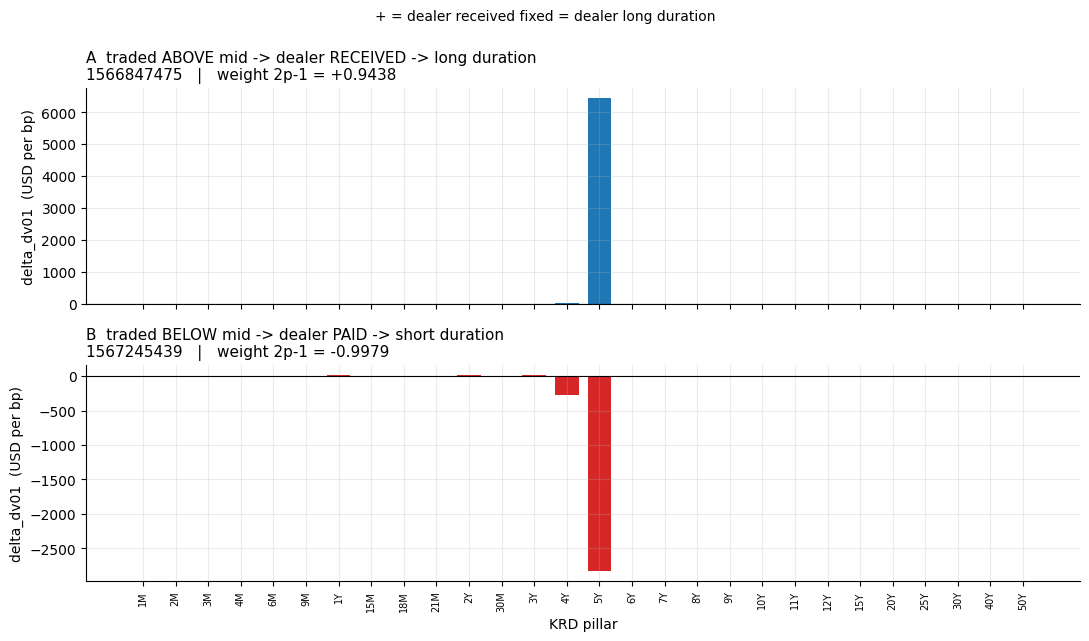

In [9]:
# ============================ COMPUTED ============================
# The two prints' key-rate profiles, side by side.
from SDRUtils.dealer_direction import krd as krd_mod

banner("COMPUTED", "signed key-rate DV01 of the two prints (28 pillars)")

pillars = list(krd_mod.PILLARS)
fig, axes = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True)
for ax, (label, t, colr) in zip(axes, (
        ("A  traded ABOVE mid -> dealer RECEIVED -> long duration", TR, "#1f77b4"),
        ("B  traded BELOW mid -> dealer PAID -> short duration", MIRROR, "#d62728"))):
    dv = t["krd"]["delta_dv01"]
    y = [dv.get(p_, 0.0) for p_ in pillars]
    ax.bar(range(len(pillars)), y, color=colr, width=0.72)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_ylabel("delta_dv01  (USD per bp)")
    ax.set_title(f"{label}\n{t['unit_key']}   |   weight 2p-1 = "
                 f"{t['call']['signed_weight']:+.4f}", loc="left")
axes[-1].set_xticks(range(len(pillars)))
axes[-1].set_xticklabels(pillars, rotation=90, fontsize=7)
axes[-1].set_xlabel("KRD pillar")
fig.suptitle("+ = dealer received fixed = dealer long duration", y=0.995, fontsize=10)
fig.tight_layout()
savefig(fig, "03_one_trade_krd")
plt.show()

---
# 4. The universe

The accounting question before any signal question: **how much of the tape can
the pinned convention orient at all?**

`universe.unit_frame` produces one row per unit with its exclusion reason;
`universe.build_universe` returns the kept `Unit` objects and the excluded rows
from *the same frame*, so a unit cannot be counted in one and missing from the
other. DV01 throughout is the annuity proxy (`sanity.expected_dv01`), never the
tape's own `risk` column.

Two views follow: the pilot window, **computed**; and the full 610-day study,
**loaded**.

In [10]:
# ============================ COMPUTED ============================
# One day, then the window.
banner("COMPUTED", f"universe accounting over {cfg.window}")

acc = pipe.units.accounting
print(pipe.units.by_day.to_string(
    index=False, float_format=lambda v: f"{v:.4f}"))
print()
print(f"units            {acc['n_units']:,}")
print(f"kept             {acc['n_kept']:,}  ({acc['unit_retention']:.2%} of units)")
print(f"DV01 proxy       {acc['dv01_total']:,.0f}")
print(f"DV01 kept        {acc['dv01_kept']:,.0f}  ({acc['dv01_retention']:.2%})")
print(f"recovered PKG-N  {acc['n_pkg_recovered']}   "
      f"PKG-4+ refused as SIGNS_AMBIGUOUS  {acc['n_pkg_ambiguous']}")
print(f"lifecycle kept   {acc['n_lifecycle_kept']}   with an upfront "
      f"{acc['n_upfront_kept']}")
print(f"\nvenue (kept)     {acc['venue_counts']}")
print(f"structure (kept) {acc['kind_counts']}")
print(f"index (kept)     {acc['index_counts']}")
print(f"\nthe window's {acc['unit_retention']:.2%} / {acc['dv01_retention']:.2%} sits "
      f"close to the 610-day 75.28% / 56.96% below,\nso it is not an "
      f"unrepresentative three days.")

--- COMPUTED: universe accounting over 2025-06-16_2025-06-18

as_of_date  n_units  n_kept  unit_retention  dv01_retention  n_pkg_recovered  n_upfront  n_lifecycle
2025-06-16     1971    1596          0.8097          0.5854                1        511           88
2025-06-17     2343    1758          0.7503          0.5642                7        512           56
2025-06-18     2579    1932          0.7491          0.5948                5        581           98

units            6,893
kept             5,286  (76.69% of units)
DV01 proxy       334,258,538
DV01 kept        194,294,365  (58.13%)
recovered PKG-N  13   PKG-4+ refused as SIGNS_AMBIGUOUS  159
lifecycle kept   242   with an upfront 1604

venue (kept)     {'D2C': 4953, 'D2D': 188, 'VENUE_UNKNOWN': 145}
structure (kept) {'OUTRIGHT': 3891, 'CURVE': 869, 'FLY': 513, 'PKG': 13}
index (kept)     {'SOFR': 5032, 'FED_FUNDS': 254}

the window's 76.69% / 58.13% sits close to the 610-day 75.28% / 56.96% below,
so it is not an unrepresent

In [11]:
# ============================ COMPUTED ============================
# The exclusion table, WITH DV01 shares. This is the accounting that matters.
banner("COMPUTED", "exclusions by reason x detail, DV01 share of the window")

ex = pipe.units.exclusions.copy()
ex_show = ex[["reason", "detail", "n_units", "n_legs", "dv01_proxy",
              "dv01_share_pct"]]
print(ex_show.head(14).to_string(index=False,
                                 float_format=lambda v: f"{v:,.4f}"))
print(f"\n({len(ex)} rows in all; DV01 shares sum to "
      f"{ex['dv01_share_pct'].sum():.2f}%, the '(kept)' row included)")
kept_share = float(ex.loc[ex["reason"] == "(kept)", "dv01_share_pct"].sum())
print(f"kept row = {kept_share:.2f}% of DV01, matching the accounting above "
      f"({acc['dv01_retention']:.2%})")
assert abs(kept_share / 100 - acc["dv01_retention"]) < 1e-9

--- COMPUTED: exclusions by reason x detail, DV01 share of the window

           reason                         detail  n_units  n_legs       dv01_proxy  dv01_share_pct
           (kept)                              -     5286    7233 194,294,365.0878         58.1270
 UNORIENTABLE_PKG     PKG-4+/PKG_SIGNS_AMBIGUOUS      159    1638  43,253,406.3959         12.9401
 UNORIENTABLE_PKG                     SPREADOVER      578     578  26,582,747.7748          7.9528
 UNORIENTABLE_PKG         PKG-4+/PKG_OPA_MISSING       34     415  15,967,652.4627          4.7770
 UNORIENTABLE_PKG               MATCHED_MATURITY      184     184  10,535,659.4900          3.1519
 UNORIENTABLE_PKG                        INVOICE      154     154  10,326,694.6492          3.0894
 UNORIENTABLE_PKG               SPREADOVER_CURVE       74     148   7,465,326.6973          2.2334
 UNORIENTABLE_PKG         PKG-4+/PKG_TIEOUT_FAIL       14      89   4,954,947.1146          1.4824
 UNORIENTABLE_PKG                 INVO

--- COMPUTED: exclusion shares, pilot window



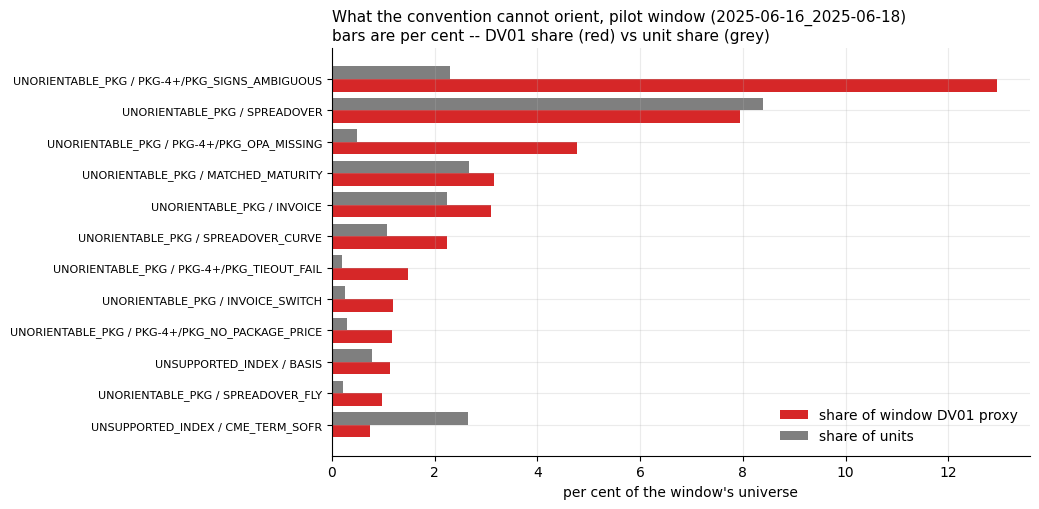

In [12]:
# ============================ COMPUTED ============================
# Plot the exclusion shares: units vs DV01. They are NOT the same picture.
banner("COMPUTED", "exclusion shares, pilot window")

e = pipe.units.exclusions.copy()
e = e[e["reason"] != "(kept)"]
e["label"] = e["reason"] + " / " + e["detail"].replace("-", "")
e = e.sort_values("dv01_proxy", ascending=True).tail(12)
e["unit_share_pct"] = 100 * e["n_units"] / acc["n_units"]

fig, ax = plt.subplots(figsize=(10.5, 5.2))
y = np.arange(len(e))
ax.barh(y - 0.2, e["dv01_share_pct"], height=0.4, color="#d62728",
        label="share of window DV01 proxy")
ax.barh(y + 0.2, e["unit_share_pct"], height=0.4, color="#7f7f7f",
        label="share of units")
ax.set_yticks(y)
ax.set_yticklabels(e["label"], fontsize=8)
ax.set_xlabel("per cent of the window's universe")
ax.set_title("What the convention cannot orient, pilot window "
             f"({cfg.window})\nbars are per cent -- DV01 share (red) vs unit "
             "share (grey)", loc="left")
ax.legend(loc="lower right")
fig.tight_layout()
savefig(fig, "04_exclusions_pilot")
plt.show()

### The 610-day universe — **loaded**

The window above is three days. The universe study is 610 tape days
(2024-03-01 .. 2026-08-07, window **U** in `data/PROVENANCE.md` §0). The next
cell reads its report file; it does not re-run it.

In [13]:
# ============================ LOADED ============================
# The 610-day universe report. data/PROVENANCE.md section 2.
import re

txt = load_artifact(DATA_DIR / "universe_exclusions_610d.txt", "§2")

# the file's first seven lines are a rateslib licence notice captured off stderr
lines = txt.splitlines()
start = next(i for i, l in enumerate(lines) if l.startswith("tape "))
body = "\n".join(lines[start:])


def _num(pat, s=body, cast=float):
    m = re.search(pat, s)
    assert m, f"pattern not found in the report: {pat}"
    return cast(m.group(1).replace(",", ""))


U_UNITS = _num(r"(?m)^\s+units\s+([\d,]+)\s*$", cast=int)
U_KEPT = _num(r"(?m)^\s+kept\s+([\d,]+)\s+\(([\d.]+)%\)", cast=int)
U_KEPT_PCT = float(re.search(r"(?m)^\s+kept\s+[\d,]+\s+\(([\d.]+)%\)",
                             body).group(1))
U_DV01 = _num(r"DV01 proxy total\s+([\d,]+)")
U_DV01_KEPT = _num(r"DV01 proxy kept\s+([\d,]+)\s+\(([\d.]+)%\)")
U_DV01_PCT = float(re.search(r"DV01 proxy kept\s+[\d,]+\s+\(([\d.]+)%\)", body).group(1))
U_DAYS = _num(r"days\s+(\d+)\s+units/day", cast=int)

print(f"window U   {U_DAYS} tape days")
print(f"units      {U_UNITS:,}")
print(f"kept       {U_KEPT:,}   ({U_KEPT_PCT:.2f}% of units)")
print(f"DV01 proxy {U_DV01:,.0f}")
print(f"DV01 kept  {U_DV01_KEPT:,.0f}   ({U_DV01_PCT:.2f}%)")

assert U_UNITS == 1_437_838 and U_DAYS == 610
assert abs(U_KEPT_PCT - 75.28) < 0.005 and abs(U_DV01_PCT - 56.96) < 0.005

# the exclusion table, by pinned constant and by detail
def _parse_block(header):
    """Lines of one fixed-width table: after `header`, up to the next '====' rule."""
    tail = body.split(header, 1)[1].splitlines()
    keep, started = [], False
    for line in tail:
        if line.startswith("===="):
            if started:
                break
            continue
        started = True
        keep.append(line)
    out = []
    for line in keep:
        m = re.match(r"^(\S.*?)\s{2,}(\d[\d,]*)\s+(\d[\d,]*)\s+([\d.e+]+)\s+([\d.]+)\s*$",
                     line)
        if m and not m.group(1).startswith(("exclusion", "reason")):
            out.append({"label": m.group(1).strip(),
                        "n_units": int(m.group(2).replace(",", "")),
                        "n_legs": int(m.group(3).replace(",", "")),
                        "dv01_proxy": float(m.group(4)),
                        "dv01_share_pct": float(m.group(5))})
    return pd.DataFrame(out)


U_BY_CONST = _parse_block("EXCLUSIONS by pinned constant -- DV01 share of the "
                          "whole universe\n====")
U_BY_DETAIL = _parse_block("EXCLUSIONS by constant / detail\n====")
assert len(U_BY_CONST) == 7 and len(U_BY_DETAIL) >= 20, \
    f"exclusion tables parsed as {len(U_BY_CONST)} / {len(U_BY_DETAIL)} rows"
print(f"\nby pinned constant ({len(U_BY_CONST)} rows):")
print(U_BY_CONST.to_string(index=False, float_format=lambda v: f"{v:,.6f}"))

UNORIENTABLE = float(U_BY_CONST.loc[U_BY_CONST["label"] == "UNORIENTABLE_PKG",
                                    "dv01_share_pct"].iloc[0])
print(f"\nthe dominant exclusion is UNORIENTABLE_PKG at {UNORIENTABLE:.6f}% of "
      f"universe DV01")
assert abs(UNORIENTABLE - 39.973637) < 1e-5
print(f"\nby detail (top 8 of {len(U_BY_DETAIL)}):")
print(U_BY_DETAIL.head(8).to_string(index=False,
                                    float_format=lambda v: f"{v:,.6f}"))

--- LOADED: notebooks\dealer_direction\data\universe_exclusions_610d.txt  (11,342 chars)   [data/PROVENANCE.md §2]

window U   610 tape days
units      1,437,838
kept       1,082,393   (75.28% of units)
DV01 proxy 80,660,906,449
DV01 kept  45,941,783,080   (56.96%)

by pinned constant (7 rows):
            label  n_units  n_legs            dv01_proxy  dv01_share_pct
 UNORIENTABLE_PKG   272373  768706 32,243,100,000.000000       39.973637
UNSUPPORTED_INDEX    52672   54470  1,371,419,000.000000        1.700227
    PRICING_ERROR    19212   19341    505,366,400.000000        0.626532
    NO_FIXED_RATE     8006   10164    471,457,400.000000        0.584493
 RISK_IMPLAUSIBLE     2735    3080     97,939,480.000000        0.121421
NOT_ECONOMIC_FLOW      302     307     21,415,360.000000        0.026550
  STANDARD_COUPON      145     153      8,427,934.000000        0.010449

the dominant exclusion is UNORIENTABLE_PKG at 39.973637% of universe DV01

by detail (top 8 of 24):
                   

--- LOADED: 610-day exclusion shares, re-plotted from the report file   [data/PROVENANCE.md §2]



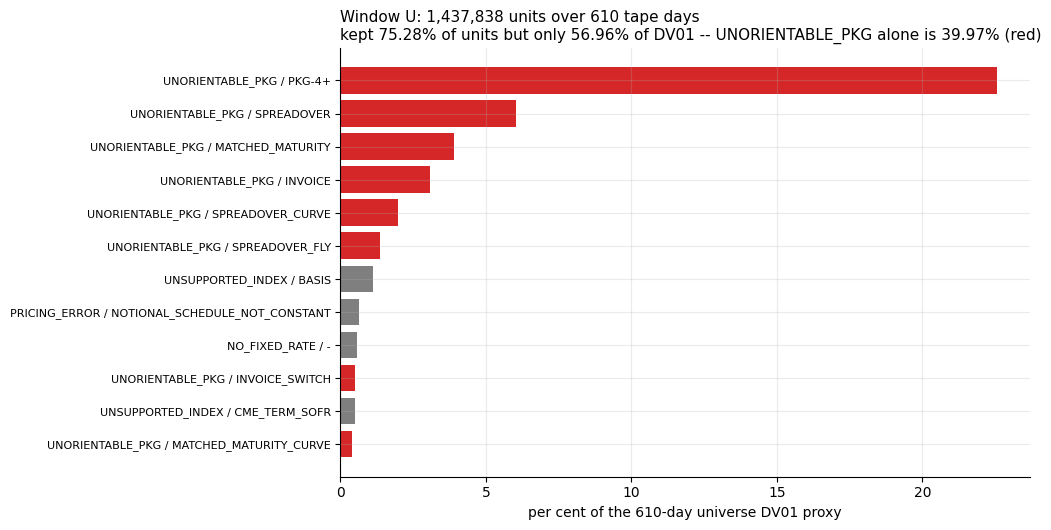

The unit share and the DV01 share are different pictures: what is excluded is
systematically LARGER than what is kept. That skew is the subject of section 8.


In [14]:
# ============================ LOADED ============================
# Plot the 610-day exclusion picture. data/PROVENANCE.md section 2.
banner("LOADED", "610-day exclusion shares, re-plotted from the report file",
       "data/PROVENANCE.md §2")

d = U_BY_DETAIL.sort_values("dv01_share_pct", ascending=True).tail(12)
fig, ax = plt.subplots(figsize=(10.5, 5.4))
colors = ["#d62728" if r.startswith("UNORIENTABLE_PKG") else "#7f7f7f"
          for r in d["label"]]
ax.barh(np.arange(len(d)), d["dv01_share_pct"], color=colors)
ax.set_yticks(np.arange(len(d)))
ax.set_yticklabels(d["label"], fontsize=8)
ax.set_xlabel("per cent of the 610-day universe DV01 proxy")
ax.set_title(f"Window U: {U_UNITS:,} units over {U_DAYS} tape days\n"
             f"kept {U_KEPT_PCT:.2f}% of units but only {U_DV01_PCT:.2f}% of DV01 "
             f"-- UNORIENTABLE_PKG alone is {UNORIENTABLE:.2f}% (red)", loc="left")
fig.tight_layout()
savefig(fig, "04_exclusions_610d")
plt.show()
print("The unit share and the DV01 share are different pictures: what is excluded "
      "is\nsystematically LARGER than what is kept. That skew is the subject of "
      "section 8.")

### Package recovery: **57.89%**, not 79.12% and not 71.92%

A `PKG-4+` package prints one *package price* and a fee per leg. In principle
the fees identify which legs the dealer received on, which would recover a large
part of the 39.97% of DV01 that `UNORIENTABLE_PKG` gives up. Two earlier numbers
were published for that recovery, and **both are withdrawn**:

| number | what it claimed | why it fails | status |
|---|---|---|---|
| **79.12%** | orienting every price-bearing `PKG-4+` takes DV01 retention 56.96% → 79.12% | assumed every price-bearing package *can* be oriented | **RETRACTED** (PROVENANCE §5.1) |
| **71.92%** | a seam-coverage projection of the same thing | its gate asks only whether a package price *exists*, not whether the orientation is *identified*; the file calls itself "the CRUDE gate … an upper bound only" | **SUPERSEDED** (PROVENANCE §5.2) |
| **72.40%** | ppfix's "retention if ambiguity is ignored" | a different computation from 71.92%, failing for the same reason — ambiguity cannot be ignored | not the standing number |
| **57.89%** | retention when the recovery is **gated on identification** | — | **STANDING** |

The recovery is **0.93 pp, not 22 pp**, because **64.22% of `PKG-4+` DV01 is
genuinely unidentifiable**: several mutually inconsistent sign vectors fit inside
the same tolerance. That is a precise claim about identification, not a claim
that the data is noisy.

The gate that separates the two is the **identification margin** (the distance
from the best sign vector to the runner-up), not the tie-out residual. The next
cell loads the evidence: match rate rises 45% → 99% across margin bands and is
**flat** across tie-out bands.

In [15]:
# ============================ LOADED ============================
# Package recovery. IN-TREE: scratch/ppfix_results.txt @ dba6d234.
pf = load_artifact(REPO / "scratch" / "ppfix_results.txt", "§3 (IN-TREE)")

def _pct(pat):
    m = re.search(pat, pf)
    assert m, pat
    return float(m.group(1))

PP_IDENT = _pct(r"HEADLINE  retained DV01, identified only\s*:\s*([\d.]+)%")
PP_IGNORE = _pct(r"retained DV01 if ambiguity ignored:\s*([\d.]+)%")
PP_BASE = _pct(r"kept, excluding ALL PKG-4\+\s+[\d,]+\s+\(([\d.]+)%\)")
PP_AMBIG_DV01 = _pct(r"PKG_SIGNS_AMBIGUOUS\s+\d+\s+[\d,.]+\s+[\d.]+\s+([\d.]+)")

print(f"retention with NO package recovery        {PP_BASE:.2f}%")
print(f"retention, recovery gated on identification {PP_IDENT:.2f}%   <- STANDING")
print(f"retention if ambiguity is ignored          {PP_IGNORE:.2f}%   "
      f"(not the standing number)")
print(f"recovery                                   {PP_IDENT - PP_BASE:+.2f} pp")
print(f"\nPKG-4+ DV01 that is PKG_SIGNS_AMBIGUOUS   {PP_AMBIG_DV01:.2f}%")
assert abs(PP_IDENT - 57.89) < 0.005 and abs(PP_BASE - 56.96) < 0.005
assert abs(PP_AMBIG_DV01 - 64.22) < 0.005

# ambiguity by leg count, and the two band tables
blk = pf.split("=== 5.", 1)[1].split("=== 6.", 1)[0]
legrows = [dict(zip(["legs", "n", "tieout_p50", "margin_p50", "share_ambiguous"],
                    l.split()))
           for l in blk.splitlines() if re.match(r"^\d\+?\s", l.strip())]
LEGTAB = pd.DataFrame(legrows).astype(
    {"n": int, "tieout_p50": float, "margin_p50": float, "share_ambiguous": float})
print("\nambiguity by leg count -- identification does NOT transfer upward:")
print(LEGTAB.to_string(index=False))

margin = pd.DataFrame(
    [{"band": f"[{a}, {b})", "n": int(n), "match_pct": float(m)}
     for a, b, n, m in re.findall(
         r"margin \[\s*([\d.]+),\s*([\d.a-z]+)\)\s+n=\s*(\d+)\s+match\s+([\d.]+)%", pf)])
tieout = pd.DataFrame(
    [{"band": f"[{a}, {b})", "n": int(n), "match_pct": float(m)}
     for a, b, n, m in re.findall(
         r"tieout \[([\d.e-]+),\s*([\d.e-]+)\)\s+n=\s*(\d+)\s+match\s+([\d.]+)%", pf)])
print("\nmatch rate by IDENTIFICATION MARGIN band (the gate that is used):")
print(margin.to_string(index=False))
print("\nmatch rate by TIE-OUT band (the statistic that was already there):")
print(tieout.to_string(index=False))
assert abs(margin["match_pct"].iloc[0] - 45.45) < 0.005
assert abs(margin["match_pct"].iloc[-1] - 99.17) < 0.005

--- LOADED: scratch\ppfix_results.txt  (9,124 chars)   [data/PROVENANCE.md §3 (IN-TREE)]

retention with NO package recovery        56.96%
retention, recovery gated on identification 57.89%   <- STANDING
retention if ambiguity is ignored          72.40%   (not the standing number)
recovery                                   +0.93 pp

PKG-4+ DV01 that is PKG_SIGNS_AMBIGUOUS   64.22%

ambiguity by leg count -- identification does NOT transfer upward:
legs    n  tieout_p50  margin_p50  share_ambiguous
   4 9866      0.0667      0.4387          61.4535
   5 3542      0.0828      0.2563          70.8075
   6 4681      0.0519      0.0927          87.0968
   7 1803      0.0617        0.08           90.904
  8+ 9716      0.0043      0.0054           97.252

match rate by IDENTIFICATION MARGIN band (the gate that is used):
        band   n  match_pct
 [0.0, 0.05)  33      45.45
[0.05, 0.25)  66      68.18
 [0.25, 1.0) 106       93.4
  [1.0, 5.0) 191      97.91
  [5.0, inf) 606      99.17

match 

--- LOADED: match rate vs identification margin and vs tie-out residual   [data/PROVENANCE.md §3, scratch/ppfix_results.txt]



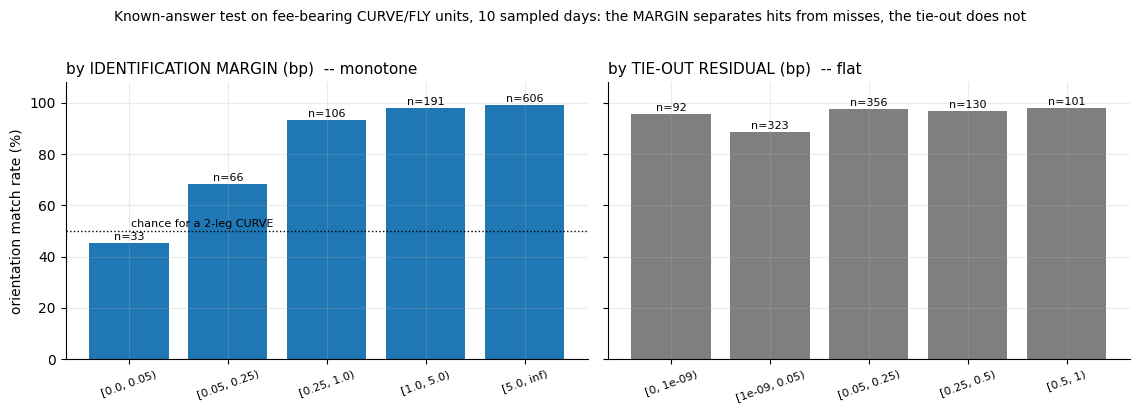

In [16]:
# ============================ LOADED ============================
# The gate's evidence, plotted. Monotone in margin, flat in tie-out.
banner("LOADED", "match rate vs identification margin and vs tie-out residual",
       "data/PROVENANCE.md §3, scratch/ppfix_results.txt")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), sharey=True)
for ax, d, title, colr in (
        (axes[0], margin, "by IDENTIFICATION MARGIN (bp)  -- monotone", "#1f77b4"),
        (axes[1], tieout, "by TIE-OUT RESIDUAL (bp)  -- flat", "#7f7f7f")):
    ax.bar(range(len(d)), d["match_pct"], color=colr)
    for i, (n, m) in enumerate(zip(d["n"], d["match_pct"])):
        ax.text(i, m + 1.2, f"n={n}", ha="center", fontsize=8)
    ax.set_xticks(range(len(d)))
    ax.set_xticklabels(d["band"], rotation=20, fontsize=8)
    ax.set_ylim(0, 108)
    ax.set_title(title, loc="left")
axes[0].axhline(50, color="k", ls=":", lw=1)
axes[0].text(0.02, 51.5, "chance for a 2-leg CURVE", fontsize=8)
axes[0].set_ylabel("orientation match rate (%)")
fig.suptitle("Known-answer test on fee-bearing CURVE/FLY units, 10 sampled days: "
             "the MARGIN separates hits from misses, the tie-out does not",
             fontsize=10, y=1.02)
fig.tight_layout()
savefig(fig, "04_pkg_recovery_gate")
plt.show()

---
# 5. Direction at scale

A deviation from mid is not a direction on its own — the mid has its own error.
The model is a **two-component mixture**: a print lands at `b0 ± h` (the half
bid-offer) plus a normal mid error with scale `s`. Integrating gives

$$
p(\text{customer paid fixed}) \;=\; \sigma\!\left(\frac{d - b_0}{\tau}\right),
\qquad \tau = \frac{s^{2}}{2h}
$$

so `tau` is the bp scale on which the tape can tell a side at all. A wide `tau`
against a small deviation gives `p` near 0.5 and `2p-1` near zero — the print
contributes almost nothing, which is the right answer, not a dropped
observation.

**Where the calibration comes from.** `probability.rolling_calibrations` fits
this on a **strictly prior** 60-calendar-day window of rate-rule deviations,
refit every five sessions; each classification date is governed by the most
recent fit at or before it. Nothing about a pilot day enters its own `tau`.
`dd_nb.taus` re-uses `s2_positioning`'s own rolling calibrations here — the same
code on a far wider sample than three days could supply — and **raises** if the
fit governing a day was not strictly prior to it.

In [17]:
# ============ COMPUTED  (on the LOADED s2 calibration, §7.1) ============
# Where each day's calibration came from, and how stale it is.
banner("COMPUTED", "calibration provenance", inputs=CALIB_IN)

print(f"mode {pipe.taus.mode}")
print(pipe.taus.provenance.to_string(index=False))
prov = pipe.taus.provenance
assert (pd.to_datetime(prov["window_hi"]) < pd.to_datetime(prov["date"])).all(), \
    "a calibration window is not strictly prior to the day it governs"
print("\nevery governing window ends strictly BEFORE the day it governs "
      "(dd_nb.taus raises otherwise)")
print(f"{prov['n_fits'].iloc[0]}-{prov['n_fits'].iloc[-1]} bucket fits per donor")
print(f"\nAND THEY ARE LOADED, NOT FITTED. Source:\n  {cfg.s2_calibrations}")
print(f"  {len(pipe.taus.by_day)} of that file's donor fits govern this window. "
      f"Nothing in this kernel fits a\n  mixture: every b0, h, s, tau and dead "
      f"zone below, and therefore every p and every\n  weight in sections 5-8, "
      f"comes off it.   [data/PROVENANCE.md §7.1]")
print(f"  If the file is absent, dd_nb.taus raises FileNotFoundError naming it "
      f"and the three-stage\n  regeneration command -- it does NOT fall back to "
      f"an in-window fit, because that fit is a\n  different claim and would "
      f"surface here as this cell's strictly-prior assertion, blaming\n  window "
      f"ordering for a missing file.")

--- COMPUTED: calibration provenance
    NOT COMPUTED HERE: tau / b0 / dead zone -- hence p and every weight -- LOADED from D:\dd_signals_cache\s2_pos\calibrations.pkl  [data/PROVENANCE.md §7.1]; nothing in this kernel fits them

mode trailing_s2
      date donor_date  window_lo  window_hi  staleness_days  n_fits
2025-06-16 2025-06-11 2025-04-11 2025-06-10               5     397
2025-06-17 2025-06-11 2025-04-11 2025-06-10               6     397
2025-06-18 2025-06-18 2025-04-18 2025-06-17               0     409

every governing window ends strictly BEFORE the day it governs (dd_nb.taus raises otherwise)
397-409 bucket fits per donor

AND THEY ARE LOADED, NOT FITTED. Source:
  D:\dd_signals_cache\s2_pos\calibrations.pkl
  3 of that file's donor fits govern this window. Nothing in this kernel fits a
  mixture: every b0, h, s, tau and dead zone below, and therefore every p and every
  weight in sections 5-8, comes off it.   [data/PROVENANCE.md §7.1]
  If the file is absent, dd_nb.taus r

--- COMPUTED: rate-rule deviations over the window

3,403 rate-rule deviations
count   3,403.0000
mean       -0.4293
std        26.0230
min      -429.7800
1%        -61.6891
5%         -4.9237
25%        -0.1745
50%        -0.0090
75%         0.1506
95%         1.8501
99%        72.4748
max       569.9040

share above mid (customer paid): 47.99%


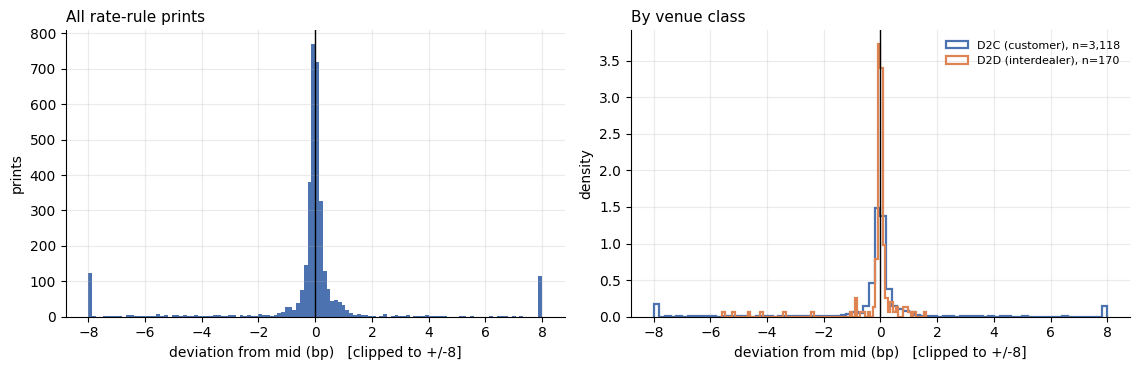

In [18]:
# ============================ COMPUTED ============================
# The deviation distribution the rule reads.
banner("COMPUTED", "rate-rule deviations over the window")

dev = pipe.calls.called
dev = dev[(dev["rule"] == conv.RULE_RATE) & dev["deviation_bps"].notna()]
print(f"{len(dev):,} rate-rule deviations")
q = dev["deviation_bps"].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99])
print(q.to_string(float_format=lambda v: f"{v:,.4f}"))
print(f"\nshare above mid (customer paid): "
      f"{(dev['deviation_bps'] > 0).mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
clip = dev["deviation_bps"].clip(-8, 8)
axes[0].hist(clip, bins=120, color="#4c72b0")
axes[0].axvline(0, color="k", lw=1)
axes[0].set_xlabel("deviation from mid (bp)   [clipped to +/-8]")
axes[0].set_ylabel("prints")
axes[0].set_title("All rate-rule prints", loc="left")
for v, lab, colr in (("D2C", "customer", "#4c72b0"), ("D2D", "interdealer", "#dd8452")):
    s = dev.loc[dev["venue_class"] == v, "deviation_bps"].clip(-8, 8)
    axes[1].hist(s, bins=80, histtype="step", lw=1.6, density=True,
                 color=colr, label=f"{v} ({lab}), n={len(s):,}")
axes[1].axvline(0, color="k", lw=1)
axes[1].set_xlabel("deviation from mid (bp)   [clipped to +/-8]")
axes[1].set_ylabel("density")
axes[1].set_title("By venue class", loc="left")
axes[1].legend(fontsize=8)
fig.tight_layout()
savefig(fig, "05_deviations")
plt.show()

--- COMPUTED: the two-component mixture for one bucket, and the p it implies
    NOT COMPUTED HERE: tau / b0 / dead zone -- hence p and every weight -- LOADED from D:\dd_signals_cache\s2_pos\calibrations.pkl  [data/PROVENANCE.md §7.1]; nothing in this kernel fits them

(this is the bucket the section-3 print was classified in)
bucket        venue_class=D2C|rate_index=SOFR|structure=OUTRIGHT|special_tenor_type=IMM|tenor_band=5Y-7Y
n / trimmed   1,360 / 1,314
b0 (mid bias) -0.093585 bp
h (half b/o)  0.012063 bp   h used 0.018613 bp
s (mid error) 0.372265 bp
separation    0.032403  = h/s   (gate MIN_SEPARATION = 0.05)
tau           3.722652 bp   = s^2 / (2h)
dead zone     +/- 0.747027 bp
flags         LEPTOKURTIC_MOMENT_CHECK_FAILED,SEPARATION_BELOW_FLOOR,ROBUST_SCALE_FALLBACK

check: s^2/(2h) = 3.722652 bp reproduces the reported tau


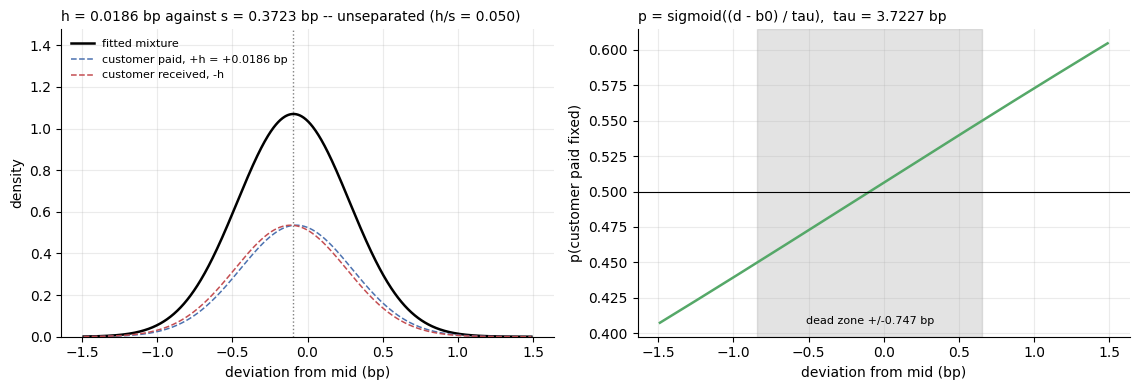

Read the right-hand panel: over the whole +/-4s range plotted (-1.49 .. +1.49 bp)
p only travels 0.407 -> 0.605. With tau = 3.72 bp against a mid error of
s = 0.372 bp, a print has to miss by BASIS POINTS before the tape has an opinion --
and the section-3 print, at +13.10 bp, is exactly such a print (p = 0.972).


In [19]:
# ============ COMPUTED  (on the LOADED s2 calibration, §7.1) ============
# The fitted mixture, drawn on top of the deviations it was fitted from.
banner("COMPUTED",
       "the two-component mixture for one bucket, and the p it implies",
       inputs=CALIB_IN)

rep = pipe.taus.report
# the demonstrative print from section 3 was classified out of this bucket, so the
# two sections are looking at the same fit.
TR_BUCKET = TR["tau"]["tau_bucket"]
sel = rep[rep["bucket"] == TR_BUCKET]
if sel.empty:                                    # pragma: no cover
    sel = rep[(rep["n_trimmed"] >= P.MIN_BUCKET_N)
              & (rep["bucket"] != "GLOBAL")].nlargest(1, "n_trimmed")
FIT_ROW = sel.iloc[0]
print(f"(this is the bucket the section-3 print was classified in)")
print(f"bucket        {FIT_ROW['bucket']}")
print(f"n / trimmed   {FIT_ROW['n']:,.0f} / {FIT_ROW['n_trimmed']:,.0f}")
print(f"b0 (mid bias) {FIT_ROW['b0_bps']:+.6f} bp")
print(f"h (half b/o)  {FIT_ROW['h_bps']:.6f} bp   h used {FIT_ROW['h_used_bps']:.6f} bp")
print(f"s (mid error) {FIT_ROW['s_bps']:.6f} bp")
print(f"separation    {FIT_ROW['separation']:.6f}  = h/s   "
      f"(gate MIN_SEPARATION = {P.MIN_SEPARATION})")
print(f"tau           {FIT_ROW['tau_bps']:.6f} bp   = s^2 / (2h)")
print(f"dead zone     +/- {FIT_ROW['dead_zone_bps']:.6f} bp")
print(f"flags         {FIT_ROW['fit_flags']}")

b0, h, s, tau = (float(FIT_ROW["b0_bps"]), float(FIT_ROW["h_used_bps"]),
                 float(FIT_ROW["s_bps"]), float(FIT_ROW["tau_bps"]))
assert abs(tau - s * s / (2 * h)) < 1e-9 * max(1.0, tau), "tau != s^2/(2h)"
print(f"\ncheck: s^2/(2h) = {s * s / (2 * h):.6f} bp reproduces the reported tau")

x = np.linspace(-4 * s, 4 * s, 800)


def _npdf(z, mu, sd):
    return np.exp(-0.5 * ((z - mu) / sd) ** 2) / (sd * np.sqrt(2 * np.pi))


mix = 0.5 * _npdf(x, b0 + h, s) + 0.5 * _npdf(x, b0 - h, s)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
axes[0].plot(x, mix, color="k", lw=1.8, label="fitted mixture")
axes[0].plot(x, 0.5 * _npdf(x, b0 + h, s), ls="--", lw=1.1, color="#4c72b0",
             label=f"customer paid, +h = {h:+.4f} bp")
axes[0].plot(x, 0.5 * _npdf(x, b0 - h, s), ls="--", lw=1.1, color="#c44e52",
             label="customer received, -h")
axes[0].axvline(b0, color="grey", lw=1, ls=":")
axes[0].set_ylim(0, float(mix.max()) * 1.38)
axes[0].set_xlabel("deviation from mid (bp)")
axes[0].set_ylabel("density")
axes[0].set_title(f"h = {h:.4f} bp against s = {s:.4f} bp -- "
                  f"unseparated (h/s = {h / s:.3f})", loc="left", fontsize=10)
axes[0].legend(fontsize=8, loc="upper left")

pp_ = 1.0 / (1.0 + np.exp(-(x - b0) / tau))
axes[1].plot(x, pp_, color="#55a868", lw=1.8)
axes[1].axhline(0.5, color="k", lw=0.8)
dz = float(FIT_ROW["dead_zone_bps"])
axes[1].axvspan(b0 - dz, b0 + dz, color="grey", alpha=0.22)
axes[1].annotate(f"dead zone +/-{dz:.3f} bp", xy=(b0, 0.04), xycoords=("data",
                 "axes fraction"), ha="center", fontsize=8)
axes[1].set_xlabel("deviation from mid (bp)")
axes[1].set_ylabel("p(customer paid fixed)")
axes[1].set_title(f"p = sigmoid((d - b0) / tau),  tau = {tau:.4f} bp", loc="left",
                  fontsize=10)
fig.tight_layout()
savefig(fig, "05_mixture_fit")
plt.show()
print(f"Read the right-hand panel: over the whole +/-4s range plotted "
      f"({x.min():+.2f} .. {x.max():+.2f} bp)\np only travels "
      f"{pp_.min():.3f} -> {pp_.max():.3f}. With tau = {tau:.2f} bp against a "
      f"mid error of\ns = {s:.3f} bp, a print has to miss by BASIS POINTS before "
      f"the tape has an opinion --\nand the section-3 print, at "
      f"{TR['structure']['deviation_bps']:+.2f} bp, is exactly such a print "
      f"(p = {TR['call']['p']:.3f}).")

## The fit's own gate, refusing a bucket

`h/s` is the **separation**: how far apart the two components are relative to
the mid's own noise. Below `probability.MIN_SEPARATION = 0.05` the components
are not separated at all, and the module refuses to report the fitted `h` as a
confident spread — it floors `h`, caps `tau`, and flags the bucket
`SEPARATION_BELOW_FLOOR`. `p` then stays within a few points of 0.5 and the
print contributes essentially nothing.

> **That gate is the single thing that stopped a false positive in the signal
> work.** Recorded in `docs/dealer_direction/signals/S_DEVIATIONS.md`: the
> mixture fit refused to resolve `h` on **all 14 per-venue swap-spread cost
> buckets** (separation 0.025–0.050, flagged `SEPARATION_BELOW_FLOOR` and
> `LEPTOKURTIC`) — 21 buckets counting the `venue = ALL` scope, which reaches
> down to 0.013; the cell below reconciles the two counts —
> and validation showed the fit is unbiased only above the gate and biased
> **−80% downward** below it. Had the gate not existed, `2h` would have argued
> the S1 cost hurdle **down by 5–20×** and *both* hypotheses would have
> "cleared". The gate was written before any of that.

There is a second refusal in the same family. `Calibration.for_key` will not
serve a leaf bucket whose trimmed sample is below its own floor
(`MIN_BUCKET_N = 800`, or `MIN_BUCKET_N_ANCHORED = 400` for an anchored fit);
it pools up the ladder and labels the answer `POOLED_TO_PARENT`, recording both
the bucket that was *asked for* and the bucket that *answered*.

In [20]:
# ============ COMPUTED  (on the LOADED s2 calibration, §7.1) ============
# Both refusals, on this window's own calibration.
banner("COMPUTED", "the mixture fit refusing buckets", inputs=CALIB_IN)

rep = pipe.taus.report.copy()
rep["flagset"] = rep["fit_flags"].fillna("")
n_tot = len(rep)
n_unsep = int(rep["flagset"].str.contains(P.FIT_UNSEPARATED).sum())
n_small = int(rep["flagset"].str.contains(P.FIT_UNDERSIZED).sum())
n_lepto = int(rep["flagset"].str.contains(P.FIT_LEPTOKURTIC).sum())
n_imprec = int(rep["flagset"].str.contains(P.FIT_IMPRECISE).sum())
print(f"{n_tot} bucket fits in the governing calibration")
print(f"  {P.FIT_UNSEPARATED:<34} {n_unsep:>4}  ({n_unsep/n_tot:.1%})  "
      f"h/s below MIN_SEPARATION = {P.MIN_SEPARATION}")
print(f"  {P.FIT_UNDERSIZED:<34} {n_small:>4}  ({n_small/n_tot:.1%})  "
      f"n_trimmed below MIN_BUCKET_N = {P.MIN_BUCKET_N}")
print(f"  {P.FIT_LEPTOKURTIC:<34} {n_lepto:>4}  ({n_lepto/n_tot:.1%})")
print(f"  {P.FIT_IMPRECISE:<34} {n_imprec:>4}  ({n_imprec/n_tot:.1%})")

unsep = rep[rep["flagset"].str.contains(P.FIT_UNSEPARATED)].nlargest(
    6, "n_trimmed")[["bucket", "n_trimmed", "h_bps", "s_bps", "separation",
                     "h_used_bps", "tau_bps", "dead_zone_bps"]]
print("\nsix refused-for-separation buckets (largest samples). Note h_used > h: "
      "the fit's own h\nwas floored at MIN_SEPARATION * s, which CAPS tau rather "
      "than reporting a confident wide spread.")
print(unsep.to_string(index=False, float_format=lambda v: f"{v:,.6f}"))
assert (unsep["separation"] < P.MIN_SEPARATION).all()
assert (unsep["h_used_bps"] >= unsep["h_bps"]).all()

# The two gates are near-complementary on this calibration, and that is worth saying.
resolved = rep[~rep["flagset"].str.contains(P.FIT_UNSEPARATED)]
both = resolved[resolved["n_trimmed"] >= P.MIN_BUCKET_N]
print(f"\nAND THE TWO GATES BETWEEN THEM LEAVE NOTHING: {len(resolved)} of "
      f"{n_tot} fits resolve h above the\nseparation gate, and "
      f"{len(both)} of those also reach MIN_BUCKET_N = {P.MIN_BUCKET_N}.")
print(f"Every bucket that resolves a spread is too small to be trusted with it, "
      f"and every bucket\nlarge enough is unseparated -- so `for_key` pools the "
      f"resolved ones away and the served\ntau is the wide, capped one. That is "
      f"the model declining to claim a side it cannot see.")
if len(resolved):
    print(f"\nthe largest fits that DO resolve h (all below MIN_BUCKET_N):")
    print(resolved.nlargest(4, "n_trimmed")[
        ["bucket", "n_trimmed", "h_bps", "s_bps", "separation", "tau_bps",
         "fit_flags"]].to_string(index=False, float_format=lambda v: f"{v:,.5f}"))
    print("""  -- and look at their h: tens of BASIS POINTS for a half bid-offer.
     These are not resolved spreads; they are 100-300 observations of a
     heavy-tailed population fitting a wide two-component model to its own
     outliers. That is exactly what MIN_BUCKET_N exists to refuse, and why
     clearing the separation gate alone is not enough to be served.""")

--- COMPUTED: the mixture fit refusing buckets
    NOT COMPUTED HERE: tau / b0 / dead zone -- hence p and every weight -- LOADED from D:\dd_signals_cache\s2_pos\calibrations.pkl  [data/PROVENANCE.md §7.1]; nothing in this kernel fits them

397 bucket fits in the governing calibration
  SEPARATION_BELOW_FLOOR              304  (76.6%)  h/s below MIN_SEPARATION = 0.05
  N_BELOW_MINIMUM                     341  (85.9%)  n_trimmed below MIN_BUCKET_N = 800
  LEPTOKURTIC_MOMENT_CHECK_FAILED     150  (37.8%)
  TAU_SE_ABOVE_TOLERANCE               91  (22.9%)

six refused-for-separation buckets (largest samples). Note h_used > h: the fit's own h
was floored at MIN_SEPARATION * s, which CAPS tau rather than reporting a confident wide spread.
                                                        bucket  n_trimmed    h_bps    s_bps  separation  h_used_bps  tau_bps  dead_zone_bps
                                                        GLOBAL      42194 0.012809 0.426029    0.030066    0.021301 4

In [21]:
# ==== COMPUTED  (stage cache §7.2, LOADED s2 calibration §7.1) ====
# Calibration.for_key refusing an undersized leaf and pooling to its parent.
banner("COMPUTED", "for_key: an undersized leaf is refused and pooled",
       inputs=BOTH_IN)

cal = pipe.taus.for_day(DAYS[0])
key_cols = list(P.BUCKET_COLS)
seen = (pipe.pricing.priced[pipe.pricing.priced["rule"] == conv.RULE_RATE]
        .rename(columns={"kind": "structure"}))
demo = []
for _, r in seen.drop_duplicates(key_cols).head(400).iterrows():
    k = P.BucketKey(*[r[c] for c in key_cols])
    try:
        f = cal.for_key(k)
    except KeyError:
        continue
    demo.append({"asked_for": f.bucket, "answered_by": f.pooled_from or f.bucket,
                 "pooled": f.pooled_from is not None, "n_trimmed": f.n_trimmed,
                 "min_n_required": f.min_n_required, "tau_bps": f.tau,
                 "flags": ",".join(f.flags)})
D = pd.DataFrame(demo)
pooled = D[D["pooled"]]
print(f"{len(D)} distinct bucket keys asked for; {len(pooled)} were POOLED "
      f"({len(pooled)/max(len(D),1):.0%})")
if len(pooled):
    ex1 = pooled.iloc[0]
    print(f"\nexample -- asked for:\n    {ex1['asked_for']}")
    print(f"  answered by:\n    {ex1['answered_by']}")
    print(f"  because the leaf's own fit had n_trimmed < min_n_required, so "
          f"for_key climbed the pooling ladder")
    print(f"  flags on the returned fit: {ex1['flags']}")
    assert P.FIT_POOLED in ex1["flags"]
print("\ndistribution of who answered:")
print(pooled["answered_by"].value_counts().head(6).to_string())

--- COMPUTED: for_key: an undersized leaf is refused and pooled
    NOT COMPUTED HERE: tau / b0 / dead zone -- hence p and every weight -- LOADED from D:\dd_signals_cache\s2_pos\calibrations.pkl  [data/PROVENANCE.md §7.1]; nothing in this kernel fits them
    NOT COMPUTED HERE: stages served from disk on this run: load_legs, price_units, krd_frame   (D:\ddnb_cache)  [data/PROVENANCE.md §7.2, §7.3]

129 distinct bucket keys asked for; 114 were POOLED (88%)

example -- asked for:
    venue_class=D2D|rate_index=SOFR|structure=FLY|special_tenor_type=IMM|tenor_band=5Y-7Y
  answered by:
    rate_index=SOFR|special_tenor_type=IMM|tenor_band=5Y-7Y
  because the leaf's own fit had n_trimmed < min_n_required, so for_key climbed the pooling ladder
  flags on the returned fit: LEPTOKURTIC_MOMENT_CHECK_FAILED,SEPARATION_BELOW_FLOOR,ROBUST_SCALE_FALLBACK,POOLED_TO_PARENT

distribution of who answered:
answered_by
rate_index=SOFR|tenor_band=15Y-20Y                        11
rate_index=SOFR           

In [22]:
# ============================ LOADED ============================
# The S1 cost buckets the gate refused. IN-TREE: BT/dd_signals/out/costs.csv @ c0b7d0f0.
costs = load_artifact(REPO / "BT" / "dd_signals" / "out" / "costs.csv",
                      "§3 (IN-TREE)")
s1c = costs[costs["instrument"] == "S1_SWAP_SPREAD"].copy()
refused = s1c[s1c["flags"].fillna("").str.contains("SEPARATION_BELOW_FLOOR")]
print(f"S1 swap-spread cost buckets in the file: {len(s1c)}   "
      f"refused by the gate: {len(refused)}   "
      f"({len(s1c['tenor_bucket'].unique())} tenors x "
      f"{len(s1c['venue'].unique())} venue scopes {sorted(s1c['venue'].unique())})")

# RECONCILIATION with S_DEVIATIONS.md, which says "all 14 ... separation
# 0.025-0.050". That 14 is the D2C+D2D pair, not the whole file: the ALL rows
# reach down to 0.013. Both statements are true of different row sets; say which.
byv = refused[refused["venue"] != "ALL"]
print(f"\n  whole file      {len(refused):>2} buckets, separation "
      f"{refused['separation_h_over_s'].min():.3f} .. "
      f"{refused['separation_h_over_s'].max():.3f}")
print(f"  venue != ALL    {len(byv):>2} buckets, separation "
      f"{byv['separation_h_over_s'].min():.3f} .. "
      f"{byv['separation_h_over_s'].max():.3f}"
      f"   <- this is S_DEVIATIONS.md's 'all 14 ... 0.025-0.050'")
print(f"  gate            {P.MIN_SEPARATION}   -- every one of the "
      f"{len(refused)} is below it")
assert len(byv) == 14 and len(refused) == len(s1c)

print()
print(refused[["tenor_bucket", "venue", "n_trimmed", "h_fit_bps", "s_fit_bps",
               "separation_h_over_s", "fit_status",
               "round_trip_fit_bps", "round_trip_ceiling_bps"]]
      .to_string(index=False, float_format=lambda v: f"{v:,.5f}"))
print("\nround_trip_fit_bps is what 2h would have claimed the round trip costs; "
      "round_trip_ceiling_bps\nis the model-free lattice hurdle that was used "
      "instead. The ratio is the size of the\nfalse positive the gate prevented:")
rr = refused.dropna(subset=["round_trip_fit_bps", "round_trip_ceiling_bps"])
ratio = rr["round_trip_ceiling_bps"] / rr["round_trip_fit_bps"]
print(f"  ceiling / fit  min {ratio.min():.1f}x   median {ratio.median():.1f}x   "
      f"max {ratio.max():.1f}x   over {len(rr)} buckets")

--- LOADED: BT\dd_signals\out\costs.csv  (47 rows)   [data/PROVENANCE.md §3 (IN-TREE)]

S1 swap-spread cost buckets in the file: 21   refused by the gate: 21   (7 tenors x 3 venue scopes ['ALL', 'D2C', 'D2D'])

  whole file      21 buckets, separation 0.013 .. 0.050
  venue != ALL    14 buckets, separation 0.025 .. 0.050   <- this is S_DEVIATIONS.md's 'all 14 ... 0.025-0.050'
  gate            0.05   -- every one of the 21 is below it

tenor_bucket venue  n_trimmed  h_fit_bps  s_fit_bps  separation_h_over_s       fit_status  round_trip_fit_bps  round_trip_ceiling_bps
         10Y   ALL        204    0.02397    0.47935              0.05000 UNRESOLVED_FLOOR             0.04793                 0.96334
         20Y   ALL         65    0.00715    0.51749              0.01382 UNRESOLVED_FLOOR             0.01430                 1.04313
          2Y   ALL         41    0.88346   17.66913              0.05000 UNRESOLVED_FLOOR             1.76691                35.86436
         30Y   ALL      

--- COMPUTED: the p distribution and the dead zone
    NOT COMPUTED HERE: tau / b0 / dead zone -- hence p and every weight -- LOADED from D:\dd_signals_cache\s2_pos\calibrations.pkl  [data/PROVENANCE.md §7.1]; nothing in this kernel fits them
    NOT COMPUTED HERE: stages served from disk on this run: load_legs, price_units, krd_frame   (D:\ddnb_cache)  [data/PROVENANCE.md §7.2, §7.3]

4,938 calls   mean |2p-1| = 0.1958
in the dead zone: 2,822 (57.1%)

by rule:
                  rule  n_units  mean_abs_signed_weight  mean_p  n_dead_zone
        NPV_VS_UPFRONT     1522                  0.3668  0.5563            0
PACKAGE_PRICE_VS_MODEL       13                  0.0619  0.5101           11
           RATE_VS_MID     3403                  0.1198  0.4945         2811


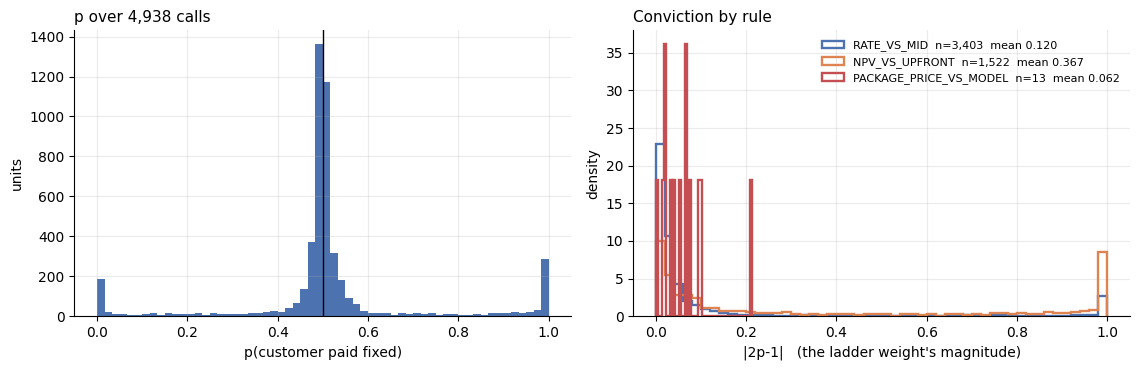

The mass at |2p-1| ~ 0 is not a failure. It is the model saying the print is
indistinguishable from mid on this bucket's own scale, and 2p-1 = 0 loads nothing.


In [23]:
# ==== COMPUTED  (stage cache §7.2, LOADED s2 calibration §7.1) ====
# The p that comes out, and how much of the book is in the dead zone.
banner("COMPUTED", "the p distribution and the dead zone", inputs=BOTH_IN)

c = pipe.calls.called
print(f"{len(c):,} calls   mean |2p-1| = {c['signed_weight'].abs().mean():.4f}")
print(f"in the dead zone: {int(c['in_dead_zone'].sum()):,} "
      f"({c['in_dead_zone'].mean():.1%})")
print("\nby rule:")
print(dd_nb.rule_mix(pipe.calls).to_string(index=False,
                                           float_format=lambda v: f"{v:.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
axes[0].hist(c["p"], bins=60, color="#4c72b0")
axes[0].axvline(0.5, color="k", lw=1)
axes[0].set_xlabel("p(customer paid fixed)")
axes[0].set_ylabel("units")
axes[0].set_title(f"p over {len(c):,} calls", loc="left")
for rule, colr in (("RATE_VS_MID", "#4c72b0"), ("NPV_VS_UPFRONT", "#dd8452"),
                   ("PACKAGE_PRICE_VS_MODEL", "#c44e52")):
    s = c.loc[c["rule"] == rule, "signed_weight"].abs()
    if len(s) > 3:
        axes[1].hist(s, bins=50, histtype="step", lw=1.7, density=True, color=colr,
                     label=f"{rule}  n={len(s):,}  mean {s.mean():.3f}")
axes[1].set_xlabel("|2p-1|   (the ladder weight's magnitude)")
axes[1].set_ylabel("density")
axes[1].set_title("Conviction by rule", loc="left")
axes[1].legend(fontsize=8)
fig.tight_layout()
savefig(fig, "05_p_distribution")
plt.show()
print("The mass at |2p-1| ~ 0 is not a failure. It is the model saying the print "
      "is\nindistinguishable from mid on this bucket's own scale, and 2p-1 = 0 "
      "loads nothing.")

---
# 6. The three rules

| rule | reads | how `p` is produced |
|---|---|---|
| `RATE_VS_MID` | the quoted structure rate against the curve mid | `probability.direction_probability` |
| `NPV_VS_UPFRONT` | the paid upfront against the payer-frame NPV | `upfront.classify`, with a `TauUpfront` from the same fit |
| `PACKAGE_PRICE_VS_MODEL` | a `PKG-N`'s package price against the sum of its legs' model values | **no `p` exists** — see below |

**Routing is by `kind` first, and that ordering is the whole point.**
`conventions.base_orientation(PKG, n, RULE_UPFRONT)` *succeeds* and returns
`(1,)*n`. So a leg-count-blind router does not drop a recovered package — it
sends it into the upfront branch with **every leg pointed the same way**,
silently discarding the internal orientation the package price recovers. That is
what the reference pipeline `BT/dd_signals/s2_positioning.py` does.

In [24]:
# ==== COMPUTED  (stage cache §7.2, LOADED s2 calibration §7.1) ====
# How much of the book each rule carries, and what each rule refused.
banner("COMPUTED", "rule mix and rule-level exclusions", inputs=BOTH_IN)

print(dd_nb.rule_mix(pipe.calls).to_string(index=False,
                                           float_format=lambda v: f"{v:.4f}"))
print("\nrule x exclusion (a refusal is carried on the call, never swallowed -- "
      "the ladder\nneeds a call for every unit or the coverage accounting has a hole):")
print(pipe.calls.exclusions.to_string(index=False))
print(f"\ndiagnostics:")
for k, v in pipe.calls.diagnostics.items():
    print(f"  {k}: {v}")

# --- 'units with an upfront' is NOT 'upfront-rule units' --------------------
# Section 4's window criteria quote 1,604. That is the universe count over ALL
# rate indices; the rule population is narrower because pricing is SOFR-only,
# and 13 units that carry an upfront are routed to the package rule instead.
UP_KEPT = pipe.units.accounting["n_upfront_kept"]
_upf = pipe.pricing.units[pipe.pricing.units["upfront"].notna()]
UP_PRICED = len(_upf)
_cf = pipe.calls.frame
UP_RULE = int((_cf["rule"] == conv.RULE_UPFRONT).sum())
UP_CALLED = int(((_cf["rule"] == conv.RULE_UPFRONT) & _cf["exclusion"].isna()).sum())
PKG_RULE = int((_cf["rule"] == dd_nb.pp.RULE_PACKAGE_PRICE).sum())
print("\nRECONCILIATION -- 'kept units carrying an upfront' is not "
      "'upfront-RULE units':")
print(f"  kept units carrying an upfront, ALL indices   {UP_KEPT:>6,}"
      f"   (universe accounting, n_upfront_kept)")
print(f"  ... of those, in the SOFR-only pricing set    {UP_PRICED:>6,}"
      f"   (indices={cfg.indices})")
print(f"  routed to NPV_VS_UPFRONT                      {UP_RULE:>6,}"
      f"   ({UP_CALLED:,} called + {UP_RULE - UP_CALLED} excluded)")
print(f"  routed to PACKAGE_PRICE_VS_MODEL instead      {PKG_RULE:>6,}")
print("  the pricing population's units-with-an-upfront, by rule:")
print(textwrap.indent(_upf["rule"].value_counts().to_string(), "    "))
assert UP_PRICED <= UP_KEPT, \
    "the priced subset cannot exceed the kept universe it is drawn from"

--- COMPUTED: rule mix and rule-level exclusions
    NOT COMPUTED HERE: tau / b0 / dead zone -- hence p and every weight -- LOADED from D:\dd_signals_cache\s2_pos\calibrations.pkl  [data/PROVENANCE.md §7.1]; nothing in this kernel fits them
    NOT COMPUTED HERE: stages served from disk on this run: load_legs, price_units, krd_frame   (D:\ddnb_cache)  [data/PROVENANCE.md §7.2, §7.3]

                  rule  n_units  mean_abs_signed_weight  mean_p  n_dead_zone
        NPV_VS_UPFRONT     1522                  0.3668  0.5563            0
PACKAGE_PRICE_VS_MODEL       13                  0.0619  0.5101           11
           RATE_VS_MID     3403                  0.1198  0.4945         2811

rule x exclusion (a refusal is carried on the call, never swallowed -- the ladder
needs a call for every unit or the coverage accounting has a hole):
                  rule exclusion  n_units
        NPV_VS_UPFRONT  (called)     1522
        NPV_VS_UPFRONT  NO_CURVE       15
PACKAGE_PRICE_VS_MODEL  (cal

### Trap A — the upfront rule's point call and its `p` are allowed to disagree

`upfront.classify` documents this explicitly: `dealer_sign` is the **point call**
(mid at face value) while `p` **marginalises over the mid's own error**, and
where they differ `FLAG_SIGN_FRAGILE` fires. But
`ladder._assert_weight_agrees_with_side` *refuses* a call whose `sign(2p-1)`
disagrees with its `dealer_sign` — and the first such unit stops the pass.

The reference pipeline never hit this because it merged weights onto the KRD
frame by hand instead of calling the ladder. Here the `DirectionCall` carries the
**weight's own side** — the ladder aggregates `2p-1`, so that is the side that is
actually loaded — and the point call travels beside it as `dealer_sign_point`.

**This is also the honest answer to "where two rules apply to the same unit,
do they agree?"** They cannot both apply: a unit either carries an upfront or it
does not, and `traded_price_bps` / `mid_price_bps` are `NaN` on every
upfront-routed unit (checked below). The measurable agreement question is
therefore *within* the upfront rule — two estimators of the same side, on the
same unit.

In [25]:
# ==== COMPUTED  (stage cache §7.2, LOADED s2 calibration §7.1) ====
# Trap A, measured. And why the "two rules on one unit" question has no data.
banner("COMPUTED", "the point call vs the marginalised p", inputs=BOTH_IN)

u = pipe.pricing.priced
cross = u.groupby("rule")[["traded_price_bps", "mid_price_bps", "deviation_bps",
                           "upfront", "npv_pay"]].apply(lambda g: g.notna().sum())
print("non-null count of each rule's inputs, by rule:")
print(cross.to_string())
print("  (this is the PRICING frame, where `deviation_bps` is the rate-rule "
      "deviation and\n   nothing else -- hence the zeros. The CALL frame reuses "
      "that column name for the\n   upfront rule's edge; the lower table renames "
      "it so the two cannot be read as one.)")
n_both = int((u["traded_price_bps"].notna() & u["upfront"].notna()).sum())
print(f"\nunits carrying BOTH a quoted structure price and an upfront: {n_both}")
print("so no unit is reachable by two rules; the agreement question is within "
      "the upfront rule.")
assert n_both == 0

up = pipe.calls.called[pipe.calls.called["rule"] == conv.RULE_UPFRONT]
dis = up[up["sign_disagrees"]]
print(f"\nupfront calls              {len(up):,}")
print(f"point call disagrees with sign(2p-1): {len(dis):,}  "
      f"({len(dis)/len(up):.1%})")
print(f"on those, |2p-1| is tiny -- median {dis['signed_weight'].abs().median():.2e}, "
      f"max {dis['signed_weight'].abs().max():.2e}")
print("\nthe disagreements, largest |weight| first:")
# RENAMED, and the rename is the point. `deviation_bps` on an upfront call is
# not the rate-rule deviation the table above counts as zero: dd_nb fills it
# with upfront.classify's `edge_bps` -- the paid upfront against the payer-frame
# NPV, in bp of structure_dv01. Same column name, different quantity, different
# frame. Left as `deviation_bps`, a row reading `+0.00622, p 0.4917` looks like
# a sign inversion, and it is not one.
_show = dis.assign(_aw=dis["signed_weight"].abs()).nlargest(6, "_aw")[
    ["unit_key", "deviation_bps", "p", "signed_weight", "dealer_sign",
     "dealer_sign_point", "tau_bps", "rule_flags"]].rename(
         columns={"deviation_bps": "edge_bps_UPFRONT"})
print(_show.to_string(index=False, float_format=lambda v: f"{v:,.6g}"))
print("  edge_bps_UPFRONT is upfront.classify's edge: paid upfront against the "
      "payer-frame NPV,\n  in bp of structure_dv01. p is formed from THAT, not "
      "from a mid deviation -- there is no\n  mid deviation on these units. "
      "(dd_nb.CALL_COLS documents all three meanings the column\n  carries, one "
      "per rule.)")
print(f"\nunhandled, the FIRST of these {len(dis)} stops ladder.unit_ladder_rows.")
assert len(dis) == pipe.calls.diagnostics["sign_fragile_disagreements"]

--- COMPUTED: the point call vs the marginalised p
    NOT COMPUTED HERE: tau / b0 / dead zone -- hence p and every weight -- LOADED from D:\dd_signals_cache\s2_pos\calibrations.pkl  [data/PROVENANCE.md §7.1]; nothing in this kernel fits them
    NOT COMPUTED HERE: stages served from disk on this run: load_legs, price_units, krd_frame   (D:\ddnb_cache)  [data/PROVENANCE.md §7.2, §7.3]

non-null count of each rule's inputs, by rule:
                        traded_price_bps  mid_price_bps  deviation_bps  upfront  npv_pay
rule                                                                                    
NPV_VS_UPFRONT                         0              0              0     1522     1522
PACKAGE_PRICE_VS_MODEL                 0              0              0       13       13
RATE_VS_MID                         3403           3403           3403        0        0
  (this is the PRICING frame, where `deviation_bps` is the rate-rule deviation and
   nothing else -- hence the zeros. 

### Trap B — the package rule has no `p`. This is the S3 gap, illustrated, not solved.

`package_price.classify` returns a sign and a `deviation_bps`; **nothing has ever
fitted a mixture on package residuals.** The ladder raises on a `p = None` call,
so `p` is **borrowed**: the pooled rate-rule fit for the unit's bucket, with `b0`
forced to zero.

Zeroing the bias is not tidying. The rate-rule `b0` is in bp of the *structure's
quoted price*; the package deviation is in bp of *package DV01*. It does not
transfer. Zeroing it also makes `sign(2p-1) == package_price`'s own
`dealer_sign` **by construction**, which is asserted per unit. Every such call is
labelled `BORROWED_B0_ZEROED:<donor>`.

**And the borrowed tau is on the wrong scale — the numbers say so.**

In [26]:
# ==== COMPUTED  (stage cache §7.2, LOADED s2 calibration §7.1) ====
# The 13 recovered packages: two-sided orientations, borrowed p, wrong scale.
from SDRUtils.dealer_direction import package_price as pp

banner("COMPUTED", "the recovered PKG-N population", inputs=BOTH_IN)

pk = pipe.calls.called[pipe.calls.called["rule"] == pp.RULE_PACKAGE_PRICE]
print(pk[["unit_key", "as_of_date", "n_legs", "venue_class", "is_lifecycle",
          "deviation_bps", "tieout_bps", "margin_bps", "p", "signed_weight",
          "dealer_sign", "in_dead_zone", "base_orientation"]].to_string(
              index=False, float_format=lambda v: f"{v:,.5g}"))

orients = [tuple(c.base_orientation) for c in pipe.calls.calls
           if c.rule == pp.RULE_PACKAGE_PRICE and c.base_orientation is not None]
two_sided = [o for o in orients if len(set(o)) > 1]
print(f"\n{len(orients)} recovered orientations, of which {len(two_sided)} are "
      f"TWO-SIDED")
assert len(two_sided) == len(orients) and len(orients) >= 1

upw = pipe.calls.called[pipe.calls.called["rule"] == conv.RULE_UPFRONT]
print(f"\nmean |2p-1|   package rule {pk['signed_weight'].abs().mean():.4f}   "
      f"vs upfront rule {upw['signed_weight'].abs().mean():.4f}")
print(f"in the dead zone: {int(pk['in_dead_zone'].sum())} of {len(pk)}")
print(f"tau bucket labels: {sorted(set(pk['tau_bucket']))[:2]} ...")
assert pk["tau_bucket"].str.startswith("BORROWED_B0_ZEROED:").all()
print("\nThe borrowed tau is on the wrong scale and it shows: the package calls "
      "are an order of\nmagnitude less decisive than the upfront calls, and most "
      "of them land in the dead zone.\nPresent these as the S3 gap ILLUSTRATED, "
      "not solved.")

--- COMPUTED: the recovered PKG-N population
    NOT COMPUTED HERE: tau / b0 / dead zone -- hence p and every weight -- LOADED from D:\dd_signals_cache\s2_pos\calibrations.pkl  [data/PROVENANCE.md §7.1]; nothing in this kernel fits them
    NOT COMPUTED HERE: stages served from disk on this run: load_legs, price_units, krd_frame   (D:\ddnb_cache)  [data/PROVENANCE.md §7.2, §7.3]

      unit_key as_of_date  n_legs venue_class  is_lifecycle  deviation_bps  tieout_bps  margin_bps       p  signed_weight  dealer_sign  in_dead_zone                              base_orientation
PTP_1566381686 2025-06-16       4         D2C         False       -0.43078     0.41408      4.3977 0.47924      -0.041511           -1          True                               (1, -1, -1, -1)
PTP_1568922961 2025-06-17       4         D2C         False        -0.1218     0.16998     0.88927 0.49175      -0.016507           -1          True                                (1, -1, 1, -1)
PTP_1568932934 2025-06-17       

In [27]:
# ============================ COMPUTED ============================
# What the leg-count-blind router would have done to those 13 packages.
banner("COMPUTED", "conventions.base_orientation(PKG, n, RULE_UPFRONT) succeeds")

rows = []
for c in pipe.calls.calls:
    if c.rule != pp.RULE_PACKAGE_PRICE or c.base_orientation is None:
        continue
    n = len(c.base_orientation)
    fallback = conv.base_orientation(conv.PKG, n, conv.RULE_UPFRONT)   # succeeds!
    recovered = tuple(int(s) for s in c.base_orientation)
    inverted = sum(1 for a, b in zip(recovered, fallback) if a != b)
    rows.append({"unit_key": c.unit_key, "n_legs": n,
                 "recovered_from_package_price": recovered,
                 "upfront_fallback": tuple(fallback),
                 "legs_inverted": inverted})
R = pd.DataFrame(rows)
print(R.to_string(index=False))
print(f"\nbase_orientation(PKG, n, RULE_UPFRONT) does NOT raise -- it returns "
      f"(1,)*n. So a router\nthat asks 'can this be oriented?' before asking "
      f"'what kind is it?' sends every one of\nthese {len(R)} units into the "
      f"upfront branch with every leg pointed the same way.")
print(f"legs that would have been inverted: {int(R['legs_inverted'].sum())} of "
      f"{int(R['n_legs'].sum())}  "
      f"({R['legs_inverted'].sum()/R['n_legs'].sum():.0%})")
print(f"units with at least one inverted leg: {int((R['legs_inverted'] > 0).sum())} "
      f"of {len(R)}")
assert (R["legs_inverted"] > 0).all(), \
    "if the fallback matched, this seam would not matter"

--- COMPUTED: conventions.base_orientation(PKG, n, RULE_UPFRONT) succeeds

      unit_key  n_legs                  recovered_from_package_price                        upfront_fallback  legs_inverted
PTP_1566381686       4                               (1, -1, -1, -1)                            (1, 1, 1, 1)              3
PTP_1568922961       4                                (1, -1, 1, -1)                            (1, 1, 1, 1)              2
PTP_1568932934       4                                (-1, -1, 1, 1)                            (1, 1, 1, 1)              2
PTP_1568939013       4                                (-1, -1, 1, 1)                            (1, 1, 1, 1)              2
PTP_1568992780       4                                (-1, -1, 1, 1)                            (1, 1, 1, 1)              2
PTP_1569332810       5                             (1, 1, 1, -1, -1)                         (1, 1, 1, 1, 1)              2
PTP_1569345585       4                               (-1,

In [28]:
# ==== COMPUTED  (stage cache §7.2, LOADED s2 calibration §7.1) ====
# One recovered package, traced. The hardest case for the orientation machinery.
banner("COMPUTED", "one_trade on a recovered PKG-N", inputs=BOTH_IN)

PKG_KEY = pk.assign(_ad=pk["deviation_bps"].abs()).nlargest(
    1, "_ad")["unit_key"].iloc[0]
TPK = dd_nb.one_trade(pipe, PKG_KEY)
t = TPK
print(f"{t['unit_key']}   {t['kind']}-{t['n_legs']}   {t['rule']}   "
      f"{t['venue_class']}   {t['as_of_date']}   lifecycle={t['is_lifecycle']}")
print(f"  package_transaction_price present; tie-out "
      f"{t['structure']['tieout_bps']:.6f} bp, identification margin "
      f"{t['structure']['margin_bps']:.6f} bp")
print(f"  deviation {t['structure']['deviation_bps']:+.6f} bp of package DV01 "
      f"({t['structure']['structure_dv01']:,.0f} USD/bp)")
print(f"  tau {t['tau']['tau_bps']:.6f} bp from {t['tau']['tau_bucket']}   "
      f"borrowed={t['tau']['borrowed']}")
print(f"  p {t['call']['p']:.6f} -> weight {t['call']['signed_weight']:+.6f}  "
      f"dead zone {t['call']['in_dead_zone']}")
print(textwrap.indent(textwrap.fill(t["call"]["dealer_side_words"], 96), "  "))
NET = float(sum(t["krd"]["delta_dv01"].values()))
GROSS = float(sum(t["krd"]["dv01_if_received"].values()))
print(f"  net sum(delta_dv01) {NET:+,.1f} USD/bp"
      f"   = weight {t['call']['signed_weight']:+.6f}"
      f" x sum(dv01_if_received) {GROSS:+,.1f}")
print(f"  base_orientation           {t['orientation']['base_orientation']}")
print(f"  received hypothesis signs  {t['orientation']['received_hypothesis_signs']}")
print(f"  per-leg received signs     {t['orientation']['per_leg_received_signs']}")
print(f"  KRD pillars {t['krd']['n_pillars']}, TENOR10 roll-up "
      f"{ {k: round(v, 1) for k, v in t['krd']['tenor_bucket_delta_dv01'].items()} }")
print(f"  recheck agrees: {t['recheck']['agrees']}")

# The sentence above is conditional on this net, and this is why it has to be.
if int(np.sign(NET)) != int(t["call"]["dealer_sign"]):
    print("\n  THE CALL AND THE NET GO OPPOSITE WAYS, AND BOTH ARE RIGHT.")
    print(f"  The call is "
          f"{'RECEIVED' if t['call']['dealer_sign'] > 0 else 'PAID'}, but the "
          f"recovered orientation points the legs two ways\n  and the legs on "
          f"the other side of the call carry more DV01 -- read the TENOR10 "
          f"roll-up\n  above. The PER-LEG received signs are the invariant; the "
          f"net is not. Section 7's\n  '+ = dealer received fixed = long "
          f"duration' cell measures how often the net follows\n  the call, split "
          f"by structure kind -- an outright always does, a package usually\n  "
          f"does not. A canned 'dealer RECEIVED -> delta_dv01 > 0' here would be "
          f"a false claim\n  about the sign of the risk this very trace just "
          f"computed.")
else:
    print("\n  The net follows the call on this unit. It need not: the "
          "convention is PER LEG, and\n  section 7's '+ = dealer received fixed "
          "= long duration' cell gives the agreement rate\n  by structure kind.")
assert dd_nb.net_claim_ok(t), \
    "the direction sentence claims a net sign the KRD does not show"
assert t["recheck"]["agrees"]
assert len(set(t["orientation"]["base_orientation"])) > 1

--- COMPUTED: one_trade on a recovered PKG-N
    NOT COMPUTED HERE: tau / b0 / dead zone -- hence p and every weight -- LOADED from D:\dd_signals_cache\s2_pos\calibrations.pkl  [data/PROVENANCE.md §7.1]; nothing in this kernel fits them
    NOT COMPUTED HERE: stages served from disk on this run: load_legs, price_units, krd_frame   (D:\ddnb_cache)  [data/PROVENANCE.md §7.2, §7.3]



PTP_1571033727   PKG-4   PACKAGE_PRICE_VS_MODEL   D2C   2025-06-18   lifecycle=False
  package_transaction_price present; tie-out 0.201270 bp, identification margin 1.633229 bp
  deviation +1.875721 bp of package DV01 (18,147 USD/bp)
  tau 4.323425 bp from BORROWED_B0_ZEROED:venue_class=D2C|rate_index=SOFR|structure=PKG|special_tenor_type=IMM|tenor_band=10Y-15Y   borrowed=True
  p 0.606793 -> weight +0.213586  dead zone False
  dealer RECEIVED fixed -> customer paid fixed -> dealer long duration ON THE LEGS IT ORIENTS --
  but the NET does not follow the call here: sum(delta_dv01) = -5,243.5 USD/bp, not delta_dv01 >
  0. A two-sided structure nets the way its largest leg points; the per-leg received signs are the
  invariant, not the net.
  net sum(delta_dv01) -5,243.5 USD/bp   = weight +0.213586 x sum(dv01_if_received) -24,549.9
  base_orientation           (-1, 1, 1, 1)
  received hypothesis signs  (-1, 1, 1, 1)
  per-leg received signs     (-1, 1, 1, 1)
  KRD pillars 28, TENOR10 rol

---
# 7. Risk buckets — the 28-pillar signed key-rate ladder

`krd.KrdProjector` produces `dv01_if_received`: the key-rate profile the dealer
would hold **if the dealer received fixed**. It is signed by the *structure* (or,
for a recovered package, by its `base_orientation`) and it is **not** yet signed
by the direction call. The ladder then applies the weight:

```
delta_dv01 = signed_weight * dv01_if_received = (2p - 1) * dv01_if_received
```

The projector shares one pricer with the repricer, and blocks curve builds by
`block_minutes` — which is why the pricing population is sorted by snap instant
and not by execution timestamp: the block anchor is the first unit to ask for it,
so an out-of-order unit would be served a curve from *after* its own print and
`krd.LookaheadCurve` fires.

In [29]:
# ==== COMPUTED  (stage cache §7.2, LOADED s2 calibration §7.1) ====
banner("COMPUTED", "the risk stage", inputs=BOTH_IN)

k = pipe.krd.krd
print(f"KRD rows              {len(k):,}")
print(f"units with risk       {k['unit_key'].nunique():,}")
print(f"pillars per unit      min {k.groupby('unit_key').size().min()}, "
      f"max {k.groupby('unit_key').size().max()} of {len(krd_mod.PILLARS)}")
print(f"projection failures   {len(pipe.krd.failures)}")
print(f"TENOR10 buckets       {sorted(set(k['tenor_bucket']))}")
print(f"\nladder unit rows      {len(pipe.ladder.unit_rows):,}")
print(f"ladder cells          {len(pipe.ladder.ladder):,}")
print(f"ladder excluded       {len(pipe.ladder.excluded):,}")

d = float((pipe.ladder.unit_rows["delta_dv01"]
           - pipe.ladder.unit_rows["signed_weight"]
           * pipe.ladder.unit_rows["dv01_if_received"]).abs().max())
w = float((2 * pipe.ladder.unit_rows["p"] - 1
           - pipe.ladder.unit_rows["signed_weight"]).abs().max())
print(f"\nmax |delta_dv01 - signed_weight * dv01_if_received| = {d:.3e}")
print(f"max |2p - 1 - signed_weight|                        = {w:.3e}")
assert d < 1e-9 and w < 1e-12

--- COMPUTED: the risk stage
    NOT COMPUTED HERE: tau / b0 / dead zone -- hence p and every weight -- LOADED from D:\dd_signals_cache\s2_pos\calibrations.pkl  [data/PROVENANCE.md §7.1]; nothing in this kernel fits them
    NOT COMPUTED HERE: stages served from disk on this run: load_legs, price_units, krd_frame   (D:\ddnb_cache)  [data/PROVENANCE.md §7.2, §7.3]

KRD rows              138,012
units with risk       4,929
pillars per unit      min 28, max 28 of 28
projection failures   0
TENOR10 buckets       ['0-1Y', '1-2Y', '10-15Y', '15-20Y', '2-3Y', '20-30Y', '3-5Y', '30Y+', '5-7Y', '7-10Y']

ladder unit rows      138,012
ladder cells          532
ladder excluded       103

max |delta_dv01 - signed_weight * dv01_if_received| = 0.000e+00
max |2p - 1 - signed_weight|                        = 0.000e+00


In [30]:
# ============================ COMPUTED ============================
# The ladder's remainder: 9 of the "PRICING_ERROR" exclusions are not errors.
banner("COMPUTED", "the ladder remainder, one level finer than the ladder's vocabulary")

rem = pipe.ladder.remainder
print(rem.groupby(["failure_reason", "why"], observed=True).size().to_string())
flat = rem[rem["why"] == "FLAT_PROFILE"]
print(f"\n{len(flat)} units are FLAT_PROFILE, not a pricing error.")
print("These are two-leg packages whose legs are IDENTICAL -- same effective date, "
      "same\nmaturity, same notional, same rate -- so the CURVE orientation "
      "(-1, +1) builds an\nexactly offsetting portfolio, all 28 pillar deltas are "
      "0.0, and dust_frac = 0 drops\nexact zeros. Their quoted price is "
      "identically zero too (-R0 + R1 on one rate), so they\ncarry p = 0.5 and no "
      "weight. Nothing is lost; a coverage table that reports them as\npricing "
      "errors is simply wrong about nine units.")
if len(flat):
    fk = flat["unit_key"].iloc[0]
    lg = pipe.pricing.legs[pipe.pricing.legs["unit_key"] == fk]
    print(f"\nexample {fk}:")
    # Same units trap as section 3: the tape's `fixed_rate` is a DECIMAL and
    # `mid_pct` is a PERCENT. Shown side by side and unlabelled, 0.0407 beside
    # 4.04859 reads as a 4 bp market and a 400 bp print. Both scales, named.
    _lg = lg[["leg_index", "effective_date", "expiration_date", "notional",
              "fixed_rate", "mid_pct", "pv01"]].copy()
    _lg.insert(5, "fixed_PERCENT", _lg["fixed_rate"] * 100.0)
    _lg = _lg.rename(columns={"fixed_rate": "fixed_rate_DECIMAL",
                              "mid_pct": "mid_PERCENT"})
    print(_lg.to_string(index=False))
    print("  fixed_rate_DECIMAL is the tape column verbatim; fixed_PERCENT is it "
          "x100, which is the\n  scale mid_PERCENT is already on. The two legs "
          "are identical, so the CURVE orientation\n  (-1, +1) cancels them "
          "exactly.")

--- COMPUTED: the ladder remainder, one level finer than the ladder's vocabulary

failure_reason  why          
NO_CURVE        RULE:NO_CURVE    94
PRICING_ERROR   FLAT_PROFILE      9

9 units are FLAT_PROFILE, not a pricing error.
These are two-leg packages whose legs are IDENTICAL -- same effective date, same
maturity, same notional, same rate -- so the CURVE orientation (-1, +1) builds an
exactly offsetting portfolio, all 28 pillar deltas are 0.0, and dust_frac = 0 drops
exact zeros. Their quoted price is identically zero too (-R0 + R1 on one rate), so they
carry p = 0.5 and no weight. Nothing is lost; a coverage table that reports them as
pricing errors is simply wrong about nine units.

example PTS_1567068930:
 leg_index effective_date expiration_date  notional  fixed_rate_DECIMAL  fixed_PERCENT  mid_PERCENT     pv01
         0     2025-08-12      2055-08-12     4e+06              0.0407           4.07      4.04859 6,873.71
         1     2025-08-12      2055-08-12     4e+06      

In [31]:
# ==== COMPUTED  (stage cache §7.2, LOADED s2 calibration §7.1) ====
# The sign lands: dealer received => positive DV01. Checked, not asserted.
banner("COMPUTED", "+ = dealer received fixed = long duration",
       inputs=BOTH_IN)

ur = pipe.ladder.unit_rows
tot = (ur.groupby("unit_key", observed=True)
       .agg(delta=("delta_dv01", "sum"),
            w=("signed_weight", "first")).reset_index())
tot = tot[tot["delta"].abs() > 1e-9]
agree = (np.sign(tot["delta"]) == np.sign(tot["w"]))
print(f"{len(tot):,} units with non-zero net key-rate DV01")
print(f"sign(sum delta_dv01) == sign(2p-1):  {agree.sum():,} "
      f"({agree.mean():.4%})")
bad = tot[~agree]
print(f"disagreements: {len(bad)}")
if len(bad):
    b = bad.merge(pipe.calls.called[["unit_key", "kind", "n_legs", "rule"]],
                  on="unit_key", how="left")
    print(b.head(8).to_string(index=False, float_format=lambda v: f"{v:,.4g}"))
    print("\n(a CURVE or FLY can carry a net DV01 whose sign is the structure's, "
          "not the call's --\nthe convention is per LEG, and a steepener received "
          "at the back is net long only if the\nback leg's DV01 dominates. The "
          "per-leg signs in section 3 are the invariant, not the net.\nThis is "
          "the cell section 6's recovered-package trace points at, and it is why "
          "that trace's\ndirection sentence is conditional on the net rather "
          "than canned.)")
print("\nby structure kind:")
kk = tot.merge(pipe.calls.called[["unit_key", "kind"]], on="unit_key", how="left")
kk["agrees"] = np.sign(kk["delta"]) == np.sign(kk["w"])
print(kk.groupby("kind")["agrees"].agg(["size", "mean"]).to_string(
    float_format=lambda v: f"{v:.4f}"))

--- COMPUTED: + = dealer received fixed = long duration
    NOT COMPUTED HERE: tau / b0 / dead zone -- hence p and every weight -- LOADED from D:\dd_signals_cache\s2_pos\calibrations.pkl  [data/PROVENANCE.md §7.1]; nothing in this kernel fits them
    NOT COMPUTED HERE: stages served from disk on this run: load_legs, price_units, krd_frame   (D:\ddnb_cache)  [data/PROVENANCE.md §7.2, §7.3]

4,929 units with non-zero net key-rate DV01
sign(sum delta_dv01) == sign(2p-1):  4,594 (93.2035%)
disagreements: 335
          unit_key   delta         w  kind  n_legs        rule
CURVE_1_1565217537  -10.16   0.03129 CURVE       2 RATE_VS_MID
CURVE_2_1567497194  -156.9    0.9962 CURVE       2 RATE_VS_MID
CURVE_3_1566898884   660.2        -1 CURVE       2 RATE_VS_MID
CURVE_3_1567497198  -369.3    0.9839 CURVE       2 RATE_VS_MID
CURVE_4_1566975099  0.9342  -0.01605 CURVE       2 RATE_VS_MID
CURVE_6_1571323944 0.05106 -0.002485 CURVE       2 RATE_VS_MID
CURVE_7_1568992205   13.18  -0.08181 CURVE      

--- COMPUTED: one day's aggregate signed key-rate profile, by venue class
    NOT COMPUTED HERE: tau / b0 / dead zone -- hence p and every weight -- LOADED from D:\dd_signals_cache\s2_pos\calibrations.pkl  [data/PROVENANCE.md §7.1]; nothing in this kernel fits them
    NOT COMPUTED HERE: stages served from disk on this run: load_legs, price_units, krd_frame   (D:\ddnb_cache)  [data/PROVENANCE.md §7.2, §7.3]



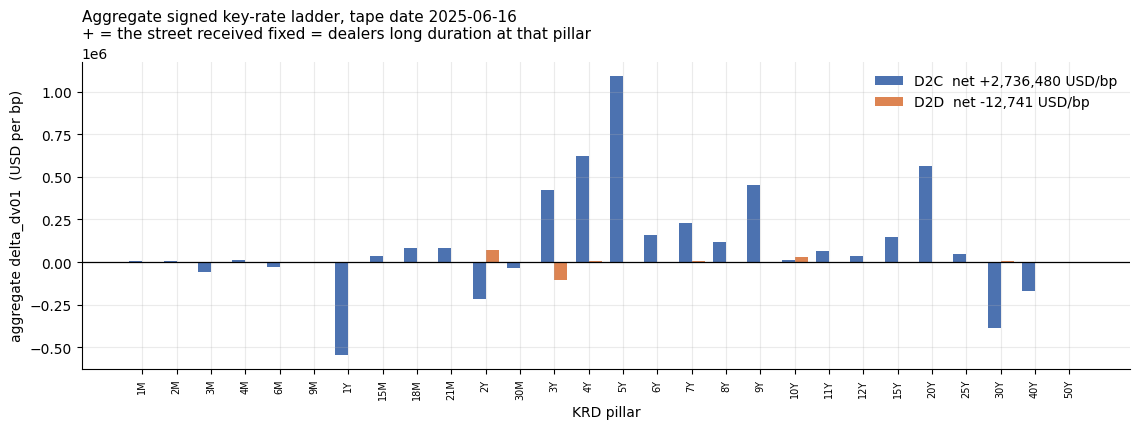

                      sum  count
venue_class                     
D2C           2,736,480.3     28
D2D             -12,741.0     28
VENUE_UNKNOWN  -446,101.0     28


In [32]:
# ==== COMPUTED  (stage cache §7.2, LOADED s2 calibration §7.1) ====
# A day's aggregate signed key-rate ladder.
banner("COMPUTED",
       "one day's aggregate signed key-rate profile, by venue class",
       inputs=BOTH_IN)

DAY = DAYS[0]
kd = pipe.krd.krd.merge(
    pipe.pricing.units[["unit_key", "as_of_date"]].rename(
        columns={"as_of_date": "tape_date"}), on="unit_key", how="left")
kd = kd[kd["tape_date"] == DAY]
agg = (kd.groupby(["venue_class", "bucket_key"], observed=True)["delta_dv01"]
       .sum().reset_index())
order = {p_: i for i, p_ in enumerate(krd_mod.PILLARS)}
agg["_o"] = agg["bucket_key"].map(order)
agg = agg.sort_values("_o")

fig, ax = plt.subplots(figsize=(11.5, 4.4))
width = 0.38
venues = [v for v in ("D2C", "D2D") if v in set(agg["venue_class"])]
for i, (v, colr) in enumerate(zip(venues, ("#4c72b0", "#dd8452"))):
    s = agg[agg["venue_class"] == v].set_index("bucket_key")["delta_dv01"]
    y = [s.get(p_, 0.0) for p_ in krd_mod.PILLARS]
    ax.bar(np.arange(len(krd_mod.PILLARS)) + (i - 0.5) * width, y, width=width,
           color=colr, label=f"{v}  net {sum(y):+,.0f} USD/bp")
ax.axhline(0, color="k", lw=0.9)
ax.set_xticks(range(len(krd_mod.PILLARS)))
ax.set_xticklabels(krd_mod.PILLARS, rotation=90, fontsize=7)
ax.set_ylabel("aggregate delta_dv01  (USD per bp)")
ax.set_xlabel("KRD pillar")
ax.set_title(f"Aggregate signed key-rate ladder, tape date {DAY}\n"
             "+ = the street received fixed = dealers long duration at that pillar",
             loc="left")
ax.legend()
fig.tight_layout()
savefig(fig, "07_day_ladder")
plt.show()
print(agg.groupby("venue_class")["delta_dv01"].agg(["sum", "count"]).to_string(
    float_format=lambda v: f"{v:,.1f}"))

---
# 8. Positioning — the daily indicator, and the read it refuses

`indicator.daily_levels` rolls the per-unit ladder rows into ten `TENOR10`
buckets, per **availability** date, per venue class, per series (`FLOW` /
`LIFECYCLE`). Availability, not execution: Part 43's Appendix C delay is not one
number, and dating a print on execution claims it was actionable before the tape
published it.

> **The edge dates of this frame are truncated by construction and the frame
> cannot say so.** On this window 3.96% of units are stamped off their own tape
> date. So there is a 2025-06-15 row built only from the backward-stamped part of
> 06-16's tape, and a 2025-06-24 row holding 33 late-published prints — while the
> 06-16 and 06-18 cells are *missing* the forward-lagged prints from tape days
> this window did not load. Read as sessions they are a 95% drop in flow that
> never happened. The only real fix is loading a wider tape window than the one
> being reported, which is a property of any availability-stamped series.

In [33]:
# ============================ COMPUTED ============================
# The three clock populations. The eight-day one is the point.
banner("COMPUTED", "visibility lag: availability date minus tape date")

vl = dd_nb.visibility_lag(pipe.ladder)
print(vl.to_string(index=False))
n_units = pipe.ladder.unit_rows["unit_key"].nunique()
off = int(vl.loc[vl["lag_days"] != 0, "n_units"].sum())
print(f"\n{off} of {n_units:,} units ({off/n_units:.2%}) are stamped off their "
      f"own tape date")
late = vl[vl["lag_days"] >= 2]
if len(late):
    print(f"\n{int(late['n_units'].sum())} uncleared off-facility prints from "
          f"{DAYS[0]} do not become\nactionable until "
          f"{(pd.Timestamp(DAYS[0]) + pd.Timedelta(days=int(late['lag_days'].max()))).date()}"
          f" -- {int(late['lag_days'].max())} days. A ladder stamped on execution "
          f"would claim\nall {int(late['n_units'].sum())} were tradeable on the "
          f"{pd.Timestamp(DAYS[0]).day}th.")

--- COMPUTED: visibility lag: availability date minus tape date

 lag_days                      visibility_source  n_units
       -1       APPENDIX_C:ON_FACILITY_NON_BLOCK      159
       -1               APPENDIX_C:INDETERMINATE        1
       -1      APPENDIX_C:UNCLEARED_OFF_FACILITY        1
        0       APPENDIX_C:ON_FACILITY_NON_BLOCK     3916
        0               APPENDIX_C:INDETERMINATE      543
        0      APPENDIX_C:UNCLEARED_OFF_FACILITY      214
        0                   APPENDIX_C:SEF_BLOCK       45
        0 APPENDIX_C:CLEARED_OFF_FACILITY_CAPPED       16
        1               APPENDIX_C:INDETERMINATE        1
        8      APPENDIX_C:UNCLEARED_OFF_FACILITY       33

195 of 4,929 units (3.96%) are stamped off their own tape date

33 uncleared off-facility prints from 2025-06-16 do not become
actionable until 2025-06-24 -- 8 days. A ladder stamped on execution would claim
all 33 were tradeable on the 16th.


In [34]:
# ==== COMPUTED  (stage cache §7.2, LOADED s2 calibration §7.1) ====
# The daily frame, with its edge dates flagged as partial.
banner("COMPUTED", "indicator.daily_levels -- D2C FLOW", inputs=BOTH_IN)

daily = pipe.daily
print(f"{len(daily)} cells   "
      f"{daily['visibility_date'].nunique()} availability dates x "
      f"{daily['bucket_key'].nunique()} buckets x "
      f"{daily['venue_class'].nunique()} venues x "
      f"{daily['series'].nunique()} series")

FULL = set(DAYS)     # only the loaded tape dates can be full availability dates
by_date = (daily.assign(_d=daily["visibility_date"].astype(str))
           .groupby("_d")
           .agg(cells=("bucket_key", "size"), venues=("venue_class", "nunique"),
                units=("n_units", "max"),
                abs_dv01=("abs_dv01", "sum")).reset_index())
by_date["full_session"] = by_date["_d"].isin(FULL)
print("every availability date in the frame:")
print(by_date.to_string(index=False, float_format=lambda v: f"{v:,.0f}"))
print("  2025-06-15 and 2025-06-24 are NOT sessions. 06-15 is the backward-stamped")
print("  part of 06-16's tape; 06-24 is the 33 uncleared off-facility prints from")
print("  06-16 arriving eight days late. Both are edges of the loaded window.\n")

bl = dd_nb.bucket_levels(daily)      # D2C, FLOW
bl["partial"] = ~bl["visibility_date"].astype(str).isin(FULL)
print()
print(bl[["visibility_date", "bucket_key", "delta_dv01", "abs_dv01", "n_units",
          "mean_abs_signed_weight", "partial"]].to_string(
              index=False, float_format=lambda v: f"{v:,.1f}"))
part = bl[bl["partial"]]
print(f"\n{len(part)} of {len(bl)} D2C/FLOW cells sit on a PARTIAL availability "
      f"date "
      f"({sorted(set(part['visibility_date'].astype(str)))}):\nthey are edge "
      f"effects of the window, not sessions. Drop them or say what they are.")

--- COMPUTED: indicator.daily_levels -- D2C FLOW
    NOT COMPUTED HERE: tau / b0 / dead zone -- hence p and every weight -- LOADED from D:\dd_signals_cache\s2_pos\calibrations.pkl  [data/PROVENANCE.md §7.1]; nothing in this kernel fits them
    NOT COMPUTED HERE: stages served from disk on this run: load_legs, price_units, krd_frame   (D:\ddnb_cache)  [data/PROVENANCE.md §7.2, §7.3]

190 cells   5 availability dates x 10 buckets x 3 venues x 2 series
every availability date in the frame:
        _d  cells  venues  units   abs_dv01  full_session
2025-06-15     30       2     64  3,059,354         False
2025-06-16     50       3   1284 55,523,635          True
2025-06-17     50       3   1527 68,487,197          True
2025-06-18     50       3   1569 69,477,064          True
2025-06-24     10       1     33    206,851         False
  2025-06-15 and 2025-06-24 are NOT sessions. 06-15 is the backward-stamped
  part of 06-16's tape; 06-24 is the 33 uncleared off-facility prints from
  06-16 

--- COMPUTED: within-bucket levels, D2C FLOW
    NOT COMPUTED HERE: tau / b0 / dead zone -- hence p and every weight -- LOADED from D:\dd_signals_cache\s2_pos\calibrations.pkl  [data/PROVENANCE.md §7.1]; nothing in this kernel fits them
    NOT COMPUTED HERE: stages served from disk on this run: load_legs, price_units, krd_frame   (D:\ddnb_cache)  [data/PROVENANCE.md §7.2, §7.3]



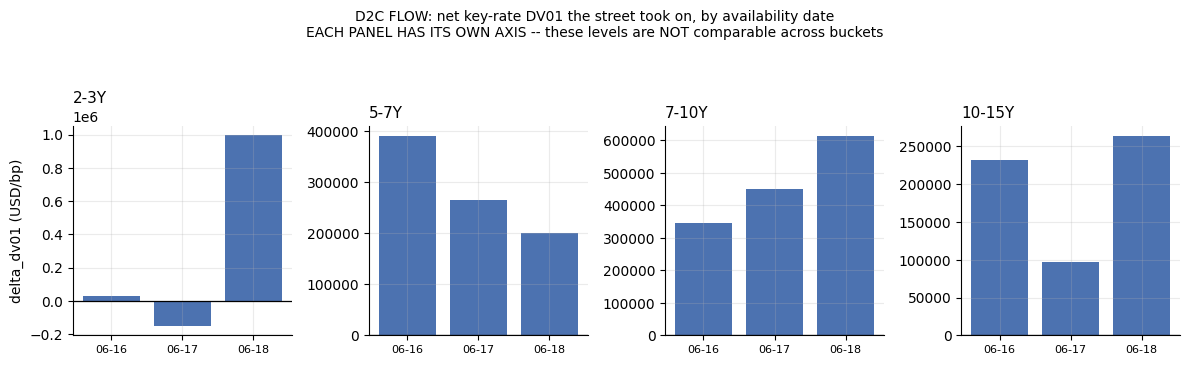

In [35]:
# ==== COMPUTED  (stage cache §7.2, LOADED s2 calibration §7.1) ====
# Levels WITHIN one bucket over time. Never across buckets -- see the next cell.
banner("COMPUTED", "within-bucket levels, D2C FLOW", inputs=BOTH_IN)

# `indicator` is imported HERE rather than borrowed from a later cell. The
# previous form tested `if "ind" in dir()` -- and the cell that imports `ind`
# comes AFTER this one, so the else-branch always fired and the bucket order
# was alphabetical by accident. Harmless on this window, and a latent
# execution-order dependency in a notebook that promises not to have them.
from SDRUtils.dealer_direction import indicator as ind

full = bl[~bl["partial"]].copy()
present = [x for x in ind.TENOR_BUCKETS if x in set(full["bucket_key"])]
buckets = [b for b in ("2-3Y", "5-7Y", "7-10Y", "10-15Y")
           if b in set(full["bucket_key"])] or present[:4]
assert buckets, "the daily frame has no full-session bucket to plot"
fig, axes = plt.subplots(1, len(buckets), figsize=(3.0 * len(buckets), 3.4),
                         sharex=True)
axes = np.atleast_1d(axes)
for ax, b in zip(axes, buckets):
    s = full[full["bucket_key"] == b].sort_values("visibility_date")
    ax.bar(range(len(s)), s["delta_dv01"], color="#4c72b0")
    ax.axhline(0, color="k", lw=0.9)
    ax.set_xticks(range(len(s)))
    ax.set_xticklabels([str(d)[5:] for d in s["visibility_date"]], fontsize=8)
    ax.set_title(f"{b}", loc="left")
    ax.set_ylabel("delta_dv01 (USD/bp)" if ax is axes[0] else "")
fig.suptitle("D2C FLOW: net key-rate DV01 the street took on, by availability "
             "date\nEACH PANEL HAS ITS OWN AXIS -- these levels are NOT "
             "comparable across buckets", fontsize=10, y=1.06)
fig.tight_layout()
savefig(fig, "08_bucket_levels")
plt.show()

## The guard: cross-bucket **levels** are refused, and the refusal carries its measurement

DV01 retention is not constant across the curve. It was measured at **0.761 at
0–1Y against 0.495 at 15–20Y — a 1.54× distortion** — because package exclusion
does not fall evenly. So "the 0–1Y level exceeds the 15–20Y level" is a statement
about *which buckets survive package exclusion*, not about what dealers hold.

`indicator.DailyPositioning` therefore has **no accessor that returns every
bucket's level in one column**. `cross_section()` and `pivot_levels()` exist only
to *refuse*, with the measurement in the error message. `cumulate()` refuses for
a different reason: compression and allocation are never publicly reported, so
risk leaves a dealer's book with no offsetting print and a running sum carries an
unbounded, **monotone** error.

The escape hatch, `rescale_for_cross_section(retention_factors)`, makes the
caller supply the factors and names the output column after the assumption.

In [36]:
# ============================ COMPUTED ============================
# The guard, fired. (Every refusal is caught -- an uncaught raise kills nbconvert.)
from SDRUtils.dealer_direction import indicator as ind

banner("COMPUTED", "DailyPositioning refusing the forbidden reads")

cells = pipe.daily.copy()
for c in ("z", "coverage_frac", "observed"):
    if c not in cells:
        cells[c] = np.nan
DP = ind.DailyPositioning(_cells=cells, drift=pd.DataFrame(), params={})

for call, label in ((lambda: DP.cross_section(), "DP.cross_section()"),
                    (lambda: DP.pivot_levels(), "DP.pivot_levels()"),
                    (lambda: DP.cumulate(), "DP.cumulate()"),
                    (lambda: DP.inventory(), "DP.inventory()  (synonym)")):
    try:
        call()
    except Exception as exc:
        print(f"{label}\n  raises {type(exc).__name__}:")
        print(textwrap.indent(textwrap.fill(str(exc).split(chr(10))[0], 92), "    "))
        for extra in str(exc).split(chr(10))[1:]:
            print(textwrap.indent(extra.strip(), "    "))
        print()
    else:                                                # pragma: no cover
        raise AssertionError(f"{label} did not refuse")

--- COMPUTED: DailyPositioning refusing the forbidden reads

DP.cross_section()
  raises CrossSectionalLevelComparison:
    the LEVEL is not comparable across tenor buckets and this object will not assemble that
    comparison. DV01 retention was measured at 0.761 at 0-1Y against 0.495 at 15-20Y -- a 1.54x
    cross-bucket scaling distortion -- so 'the 0-1Y level exceeds the 15-20Y level' is a
    statement about which buckets survive package exclusion, not about what dealers hold.
    (docs/dealer_direction/2026-08-11-package-exclusion-skew.md §1, §8.1)
    * to read one bucket against its own history: .bucket(key, venue_class=..., series=...)
    * to compare buckets at all: .standardised(), whose z-score cancels a CONSTANT retention factor exactly -- read its drift flags first, because 1-2Y's retention is not constant
    * to insist on levels: .rescale_for_cross_section(retention_factors), which makes you supply the factors and assumes the excluded flow has the same directional mix

--- LOADED: notebooks\dealer_direction\data\bucket_retention_DERIVED.csv  (10 rows)   [data/PROVENANCE.md §2 (DERIVED)]

bucket  tape_dv01_bn  tape_share_pct  retained_share_pct  excl_rate_pct  retention_factor  vs_best_bucket
  0-1Y          4.51            5.59                7.47           23.9             0.761               1
  1-2Y          4.55            5.64                5.16          47.83             0.522            0.69
  2-3Y          5.01            6.22                6.57          39.81             0.602            0.79
  3-5Y          8.61           10.67               10.38           44.6             0.554            0.73
  5-7Y         15.65            19.4               17.86          47.58             0.524            0.69
 7-10Y          8.07           10.01                9.43          46.32             0.537            0.71
10-15Y         16.38            20.3               21.41          39.93             0.601            0.79
15-20Y          3.48           

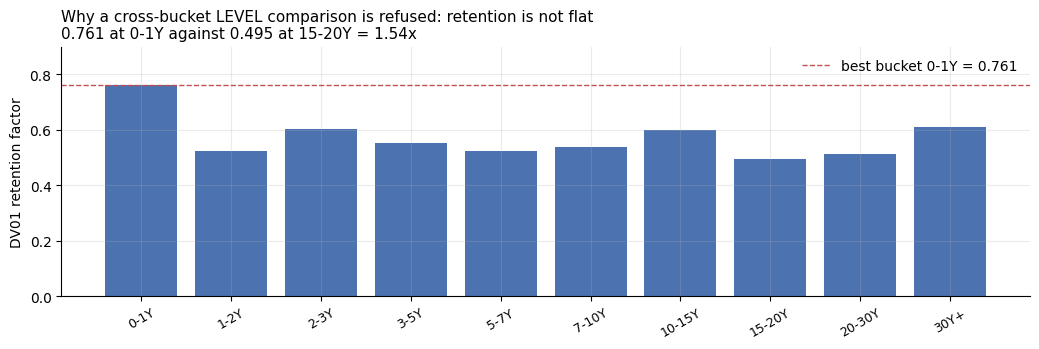

In [37]:
# ============================ LOADED ============================
# The measurement behind the refusal. DERIVED file, data/PROVENANCE.md section 2.
ret = load_artifact(DATA_DIR / "bucket_retention_DERIVED.csv", "§2 (DERIVED)")
print(ret[["bucket", "tape_dv01_bn", "tape_share_pct", "retained_share_pct",
           "excl_rate_pct", "retention_factor", "vs_best_bucket"]].to_string(
               index=False, float_format=lambda v: f"{v:,.4g}"))

BEST = float(ret["retention_factor"].max())
WORST = float(ret["retention_factor"].min())
b_best = ret.loc[ret["retention_factor"].idxmax(), "bucket"]
b_worst = ret.loc[ret["retention_factor"].idxmin(), "bucket"]
print(f"\nretention {BEST:.3f} at {b_best} against {WORST:.3f} at {b_worst}  ->  "
      f"a {BEST/WORST:.2f}x cross-bucket distortion")
assert abs(BEST - 0.761) < 5e-4 and abs(BEST / WORST - 1.54) < 0.01

# the parse is validated against a relation it does not impose
d1 = float((ret["retention_factor"] - (1 - ret["excl_rate_pct"] / 100)).abs().max())
d2 = float((ret["vs_best_bucket"] - ret["retention_factor"] / BEST).abs().max())
print(f"\nparse check (relations the parse does NOT impose):")
print(f"  |retention_factor - (1 - excl_rate/100)| max {d1:.5f}  "
      f"(within the doc's 3 d.p. rounding)")
print(f"  |vs_best_bucket - retention/{BEST:.3f}|   max {d2:.5f}")
assert d1 < 0.001 and d2 < 0.01

fig, ax = plt.subplots(figsize=(10.5, 3.6))
o = list(ind.TENOR_BUCKETS)
r2 = ret.set_index("bucket").reindex([b for b in o if b in set(ret["bucket"])])
ax.bar(range(len(r2)), r2["retention_factor"], color="#4c72b0")
ax.axhline(BEST, color="#c44e52", ls="--", lw=1,
           label=f"best bucket {b_best} = {BEST:.3f}")
ax.set_xticks(range(len(r2)))
ax.set_xticklabels(r2.index, rotation=30, fontsize=9)
ax.set_ylabel("DV01 retention factor")
ax.set_ylim(0, 0.9)
ax.set_title("Why a cross-bucket LEVEL comparison is refused: retention is not "
             f"flat\n{BEST:.3f} at {b_best} against {WORST:.3f} at {b_worst} "
             f"= {BEST/WORST:.2f}x", loc="left")
ax.legend()
fig.tight_layout()
savefig(fig, "08_retention_skew")
plt.show()

In [38]:
# ============================ COMPUTED ============================
# z is EXACTLY invariant to a constant retention factor. That is the whole argument.
banner("COMPUTED", "z(r*L) == z(L) exactly, for constant r; and it breaks when r drifts")

rng = np.random.default_rng(20250616)
L = rng.standard_normal(250) * 4.0e5 + 1.0e5          # a bucket's true level series


def z_of(v, win=250):
    v = np.asarray(v, float)
    return (v - v.mean()) / v.std(ddof=1)


base = z_of(L)
for r in (0.761, 0.495, 0.10, 1.0):
    zr = z_of(r * L)
    print(f"  constant retention r = {r:<6.3f}  max |z(rL) - z(L)| = "
          f"{np.abs(zr - base).max():.3e}")
    assert np.abs(zr - base).max() < 1e-12

drift = np.linspace(0.761, 0.761 + 0.0507 * (250 / 252), 250)   # +5.07 pp/yr, the 1-2Y case
zd = z_of(drift * L)
print(f"\n  DRIFTING retention 0.761 -> {drift[-1]:.3f} over a year "
      f"(+5.07 pp/yr, the measured 1-2Y case)")
print(f"    max |z(rL) - z(L)| = {np.abs(zd - base).max():.4f}   "
      f"corr = {np.corrcoef(zd, base)[0,1]:.6f}")
print(f"    mean z of the first 60 obs {zd[:60].mean():+.4f} vs the last 60 "
      f"{zd[-60:].mean():+.4f}  <- a trend that is MEASUREMENT")
assert np.abs(zd - base).max() > 1e-6

print("""
  Write the observed level as r_b * L. Then

      z = (r_b*L - r_b*mu) / (r_b*sigma) = (L - mu) / sigma

  so a CONSTANT retention factor cancels exactly -- which is why z may cross
  buckets and levels may not. The cancellation needs r_b constant in time, and
  indicator.PINNED_DRIFT_BUCKETS records the one bucket where it was measured
  not to be: 1-2Y, at +5.07 pp/yr (t = +3.21), the meeting-dated front end.
  Every published row carries its coverage fraction, a measured drift trend and
  a flag for exactly this reason.""")
print(f"\n  indicator.MEASURED_RETENTION_FACTORS = "
      f"{ {k: round(v,3) for k, v in list(ind.MEASURED_RETENTION_FACTORS.items())[:5]} } ...")
print(f"  indicator.PINNED_DRIFT_BUCKETS       = {ind.PINNED_DRIFT_BUCKETS}")
print(f"  indicator.Z_MIN_OBS = {ind.Z_MIN_OBS} sessions of own history -- which is "
      f"why THIS window\n  publishes levels and no z: three days cannot make one.")

--- COMPUTED: z(r*L) == z(L) exactly, for constant r; and it breaks when r drifts

  constant retention r = 0.761   max |z(rL) - z(L)| = 8.882e-16
  constant retention r = 0.495   max |z(rL) - z(L)| = 8.882e-16
  constant retention r = 0.100   max |z(rL) - z(L)| = 4.441e-16
  constant retention r = 1.000   max |z(rL) - z(L)| = 0.000e+00

  DRIFTING retention 0.761 -> 0.811 over a year (+5.07 pp/yr, the measured 1-2Y case)
    max |z(rL) - z(L)| = 0.0783   corr = 0.999824
    mean z of the first 60 obs +0.1391 vs the last 60 -0.1828  <- a trend that is MEASUREMENT

  Write the observed level as r_b * L. Then

      z = (r_b*L - r_b*mu) / (r_b*sigma) = (L - mu) / sigma

  so a CONSTANT retention factor cancels exactly -- which is why z may cross
  buckets and levels may not. The cancellation needs r_b constant in time, and
  indicator.PINNED_DRIFT_BUCKETS records the one bucket where it was measured
  not to be: 1-2Y, at +5.07 pp/yr (t = +3.21), the meeting-dated front end.
  Every publi

---
# 9. The regression studies

Four registered tests have been run on this pipeline. **Three are dead and the
fourth is uninformative.** This section does two different things and the
difference matters:

1. **First, a live estimator validation on synthetic data — COMPUTED.** A known
   lead-lag effect is planted at a known lag with a known sign, and the estimator
   is asked to find it; then a mirror case (mass deliberately *pre*-print); then
   a null. If the estimator could not recover a planted effect, nothing it says
   about the real data would mean anything.

2. **Then the real results — LOADED and labelled as loaded.** Re-running a
   pre-registered test on a different window and reporting the new number is a
   second draw, not a robustness check. These are read off the files the studies
   wrote.

## 9a. Estimator validation, on synthetic data — **COMPUTED**

The estimator below is R0's own, extracted verbatim from branch `r0-leadlag` @
`c97205bd` (`r0_leadlag/run_r0.py`) via `git show`. It is pasted rather than
imported because that module calls `matplotlib.use("Agg")` at import time.

$$
Y_{b,t} \;=\; \alpha_b \;+\; \sum_{k=-30}^{+30}\beta_k\,X_{b,t-k}
\;+\;\text{bin-of-day FE}\;+\;5\ \text{lags of } Y \;+\;\varepsilon
$$

`k > 0` means X precedes Y — the post-print hedge channel. The pre-registration
fixes **day-clustered** standard errors as governing, so the Newey-West arm is
switched off here (it is a 60-lag Bartlett loop that costs two minutes and does
not govern).

Both series are standardised by a trailing rolling scale, so the estimand is not
the DGP's `true_b` but `true_b * scale_X / scale_Y`. That prediction is formed
**a priori**, from the scales the estimator will itself use, and the estimate is
then checked against it — a self-test that compared the estimate to itself would
not be one.

In [39]:
# ============================ COMPUTED ============================
# R0's estimator, extracted verbatim from r0-leadlag @ c97205bd (run_r0.py).
import scipy.sparse as sp

KMIN, KMAX = -30, 30
N_YLAGS = 5
TSTAT_CRIT = 1.96
DECISION_BUCKETS = ["SFR_FF", "TU", "FV", "TY_UXY", "US"]
ROLL_WIN, ROLL_MINP = 1440, 240
EDGE = max(abs(KMIN), abs(KMAX))
LAGS = list(range(KMIN, KMAX + 1))
XCOLS = [f"x{k:+d}" for k in LAGS]
YCOLS = [f"ylag{j}" for j in range(1, N_YLAGS + 1)]
REGCOLS = XCOLS + YCOLS
IPOS = [REGCOLS.index(f"x{k:+d}") for k in LAGS if k >= 1]
INEG = [REGCOLS.index(f"x{k:+d}") for k in LAGS if k <= -1]


class FEAbsorber:
    """Exact within-transformation for one or two additive factors."""

    def __init__(self, codes_list):
        self.codes = codes_list
        self.n = len(codes_list[0])
        if len(codes_list) == 1:
            g = codes_list[0]
            self.counts = np.bincount(g).astype(float)
            self.k_fe = int(self.counts.size)
            self.mode = "oneway"
        else:
            blocks, off = [], 0
            for g in codes_list:
                ng = int(g.max()) + 1
                blocks.append(sp.csr_matrix(
                    (np.ones(self.n), (np.arange(self.n), g)), shape=(self.n, ng)))
                off += ng
            self.D = sp.hstack(blocks).tocsr()
            DtD = (self.D.T @ self.D).toarray()
            self.P = np.linalg.pinv(DtD, rcond=1e-10)
            self.k_fe = off - (len(codes_list) - 1)
            self.mode = "twoway"

    def absorb(self, M):
        M = np.asarray(M, dtype=float)
        one_d = M.ndim == 1
        if one_d:
            M = M[:, None]
        if self.mode == "oneway":
            g = self.codes[0]
            sums = np.zeros((self.counts.size, M.shape[1]))
            for j in range(M.shape[1]):
                sums[:, j] = np.bincount(g, weights=M[:, j],
                                         minlength=self.counts.size)
            R = M - (sums / self.counts[:, None])[g]
        else:
            alpha = self.P @ (self.D.T @ M)
            R = M - self.D @ alpha
        return R[:, 0] if one_d else R


def ols_with_ses(Zy, ZX, cluster, block, k_fe):
    """OLS on FE-absorbed data; cluster-robust (day) covariance. NW arm omitted."""
    n, k = ZX.shape
    bread = np.linalg.pinv(ZX.T @ ZX, rcond=1e-12)
    beta = bread @ (ZX.T @ Zy)
    e = Zy - ZX @ beta
    kk = k + k_fe
    U = ZX * e[:, None]
    order = np.argsort(cluster, kind="stable")
    cs = cluster[order]
    bounds = np.flatnonzero(np.r_[True, cs[1:] != cs[:-1], True])
    G = len(bounds) - 1
    aggm = np.add.reduceat(U[order], bounds[:-1], axis=0)
    c_cl = (G / max(G - 1, 1)) * ((n - 1) / max(n - kk, 1))
    V_cl = bread @ (aggm.T @ aggm) @ bread * c_cl
    return dict(beta=beta, V_cl=V_cl, n=n, k=k, k_fe=k_fe, G=G)


def lincomb(res, idx):
    c = np.zeros(res["beta"].size)
    c[idx] = 1.0
    v = float(c @ res["beta"])
    se = float(np.sqrt(max(c @ res["V_cl"] @ c, 0.0)))
    return dict(val=v, se_cl=se, t_cl=v / se if se > 0 else np.nan)


def rolling_scale(v, bucket_code):
    s = pd.Series(v)
    out = np.empty_like(v, dtype=float)
    for b in np.unique(bucket_code):
        m = bucket_code == b
        sb = s[m]
        r = sb.rolling(ROLL_WIN, min_periods=ROLL_MINP).std().shift(1)
        full = float(sb.std(ddof=1))
        if not np.isfinite(full) or full == 0:
            full = 1.0
        out[m] = r.fillna(full).where(np.isfinite(r) & (r > 0), full).to_numpy()
    return out


def shift_global(a, k):
    out = np.full(a.shape, np.nan)
    if k > 0:
        out[k:] = a[:-k]
    elif k < 0:
        out[:k] = a[-k:]
    else:
        out[:] = a
    return out


def build_grid(y):
    """Synthetic-panel form: sessions are full by construction."""
    g = y[y["bucket"].isin(DECISION_BUCKETS)].copy()
    g = g.sort_values(["bucket", "minute_utc"], kind="stable").reset_index(drop=True)
    step = g.groupby("bucket")["minute_utc"].diff().dt.total_seconds()
    new_sess = (step != 60) | step.isna()
    g["sess_idx"] = new_sess.groupby(g["bucket"]).cumsum().astype(int)
    g["sess_key"] = g["bucket"] + "|" + g["sess_idx"].astype(str)
    g["pos"] = g.groupby("sess_key").cumcount()
    g["slen"] = g.groupby("sess_key")["pos"].transform("size")
    last_min = g.groupby("sess_key")["minute_utc"].transform("max")
    g["session_date"] = last_min.dt.tz_convert("America/Chicago").dt.date.astype(str)
    g["bin_of_day"] = g["minute_utc"].dt.hour * 60 + g["minute_utc"].dt.minute
    g["keep"] = (g["pos"] >= EDGE) & (g["pos"] <= g["slen"] - 1 - EDGE)
    return g


def make_design(grid, xser):
    bcode = pd.factorize(grid["bucket"])[0]
    ystd = grid["signed_volume"].to_numpy(float) / rolling_scale(
        grid["signed_volume"].to_numpy(float), bcode)
    xstd = xser / rolling_scale(xser, bcode)
    cols = [shift_global(xstd, k) for k in LAGS]
    cols += [shift_global(ystd, j) for j in range(1, N_YLAGS + 1)]
    M = np.column_stack(cols)
    keep = grid["keep"].to_numpy() & np.isfinite(np.column_stack(cols)).all(axis=1) \
        & np.isfinite(ystd)
    return ystd[keep], M[keep], keep


def run_one(grid, xser):
    yv, M, keep = make_design(grid, xser)
    sub = grid.loc[keep]
    cl = pd.factorize(sub["session_date"])[0]
    bcode = pd.factorize(sub["bucket"])[0]
    bod = pd.factorize(sub["bin_of_day"])[0]
    fe = FEAbsorber([bcode, bod])
    res = ols_with_ses(fe.absorb(yv), fe.absorb(M), cl, bcode, fe.k_fe)
    res["n_days"] = int(pd.Series(sub["session_date"]).nunique())
    return res


print("estimator extracted from r0-leadlag @ c97205bd : r0_leadlag/run_r0.py")
print(f"  grid k = {KMIN}..{KMAX}, {N_YLAGS} Y lags, two-way FE "
      f"(bucket x bin-of-day), day-clustered SEs")

estimator extracted from r0-leadlag @ c97205bd : r0_leadlag/run_r0.py
  grid k = -30..30, 5 Y lags, two-way FE (bucket x bin-of-day), day-clustered SEs


In [40]:
# ============================ COMPUTED ============================
# Plant a known effect; recover it. Then the mirror. Then the null.
banner("COMPUTED", "estimator validation on synthetic panels with a KNOWN answer")


def synth_panel(true_k, true_b, seed, n_sess=40, n_bins=700):
    """Same shape as the real panel, with a KNOWN beta profile."""
    rng = np.random.default_rng(seed)
    rows, t0 = [], pd.Timestamp("2026-01-05 00:00", tz="UTC")
    for b in DECISION_BUCKETS[:3]:
        for s in range(n_sess):
            mins = (t0 + pd.Timedelta(days=s)
                    + pd.to_timedelta(np.arange(n_bins), unit="m"))
            rows.append(pd.DataFrame({"bucket": b, "minute_utc": mins}))
    g = pd.concat(rows, ignore_index=True)
    g["signed_volume"] = 0.0
    grid = build_grid(g)
    n = len(grid)
    x = rng.standard_normal(n) * rng.choice([0.0, 1.0], size=n, p=[0.4, 0.6])
    bod = np.sin(2 * np.pi * grid["bin_of_day"].to_numpy() / 1440.0) * 0.8
    be = pd.factorize(grid["bucket"])[0] * 0.5
    y, e = np.zeros(n), rng.standard_normal(n)
    sess = grid["sess_key"].to_numpy()
    for i in range(n):
        ar = 0.30 * y[i - 1] if i > 0 and sess[i - 1] == sess[i] else 0.0
        j = i - true_k
        xk = x[j] if (0 <= j < n and sess[j] == sess[i] and true_b != 0.0) else 0.0
        y[i] = bod[i] + be[i] + ar + true_b * xk + e[i]
    grid = grid.copy()
    grid["signed_volume"] = y
    bc = pd.factorize(grid["bucket"])[0]
    # the a-priori prediction: the prereg standardises BOTH series
    expected = true_b * float(np.mean(rolling_scale(x, bc))) / \
        float(np.mean(rolling_scale(y, bc)))
    return run_one(grid, x), expected


i3, im3 = REGCOLS.index("x+3"), REGCOLS.index("x-3")
RTOL = 0.05
_t = time.perf_counter()
checks, profiles = [], {}

# (1) known effect at k = +3, negative sign
r1, exp1 = synth_panel(+3, -0.30, seed=11)
b1, se1 = r1["beta"], np.sqrt(np.diag(r1["V_cl"]))
sp1, sn1 = lincomb(r1, IPOS), lincomb(r1, INEG)
profiles["(1) effect at k=+3"] = (b1, se1)
print("(1) DGP  Y_t = -0.30*X_(t-3) + 0.30*Y_(t-1) + bin-of-day + bucket + eps")
print(f"    predicted standardised beta at k=+3 = {exp1:+.4f}  (a priori)")
print(f"    beta(k=+3) = {b1[i3]:+.4f}   t_cl = {b1[i3]/se1[i3]:+8.2f}   "
      f"rel err vs prediction = {b1[i3]/exp1 - 1:+.3%}")
print(f"    beta(k=-3) = {b1[im3]:+.4f}  (true 0)   "
      f"max |beta| over k != +3 = {np.abs(np.delete(b1[:61], i3)).max():.4f}")
print(f"    sum(k>=1) = {sp1['val']:+.4f} (t {sp1['t_cl']:+.2f})   "
      f"sum(k<=-1) = {sn1['val']:+.4f} (t {sn1['t_cl']:+.2f})")
checks += [("magnitude recovered", abs(b1[i3] / exp1 - 1) < RTOL),
           ("significant NEGATIVE at the right lag", b1[i3] / se1[i3] < -5),
           ("nothing anywhere else", abs(np.delete(b1[:61], i3)).max() < 0.05),
           ("nothing at k=-3", abs(b1[im3]) < 0.02),
           ("post-print mass, as injected", sp1["t_cl"] < -5)]

# (2) mirror: the same effect placed PRE-print must not show up post-print
r2, exp2 = synth_panel(-3, -0.30, seed=12)
b2, se2 = r2["beta"], np.sqrt(np.diag(r2["V_cl"]))
sp2, sn2 = lincomb(r2, IPOS), lincomb(r2, INEG)
profiles["(2) mirror at k=-3"] = (b2, se2)
print(f"\n(2) MIRROR  Y_t = -0.30*X_(t+3) ...   predicted {exp2:+.4f} at k=-3")
print(f"    beta(k=-3) = {b2[im3]:+.4f}  t {b2[im3]/se2[im3]:+.2f}     "
      f"beta(k=+3) = {b2[i3]:+.4f}  t {b2[i3]/se2[i3]:+.2f}")
print(f"    sum(k>=1) = {sp2['val']:+.4f} (t {sp2['t_cl']:+.2f})   "
      f"sum(k<=-1) = {sn2['val']:+.4f} (t {sn2['t_cl']:+.2f})")
checks += [("mirror magnitude recovered", abs(b2[im3] / exp2 - 1) < RTOL),
           ("lag orientation NOT transposed", abs(b2[i3]) < 0.02),
           ("pre-print mass, as injected", sn2["t_cl"] < -5)]

# (3) null: nothing planted, nothing may be found
r3, _ = synth_panel(+3, 0.0, seed=13)
b3, se3 = r3["beta"], np.sqrt(np.diag(r3["V_cl"]))
sp3, sn3 = lincomb(r3, IPOS), lincomb(r3, INEG)
profiles["(3) NULL"] = (b3, se3)
print(f"\n(3) NULL DGP   sum(k>=1) = {sp3['val']:+.4f} (t {sp3['t_cl']:+.2f})   "
      f"sum(k<=-1) = {sn3['val']:+.4f} (t {sn3['t_cl']:+.2f})")
checks.append(("no false significance under the null",
               abs(sp3["t_cl"]) < TSTAT_CRIT and abs(sn3["t_cl"]) < TSTAT_CRIT))

# (4) FE absorption against explicit dummies
rng = np.random.default_rng(7)
n = 4000
bc, bd = rng.integers(0, 4, n), rng.integers(0, 25, n)
Xs = rng.standard_normal((n, 6))
ys = Xs @ np.array([1, -2, .5, 0, .3, -.7]) + bc * .9 + np.sin(bd) * 1.3 \
    + rng.standard_normal(n)
fe = FEAbsorber([bc, bd])
bf = np.linalg.lstsq(fe.absorb(Xs), fe.absorb(ys), rcond=None)[0]
Dfull = np.column_stack([Xs, np.eye(4)[bc][:, 1:], np.eye(25)[bd][:, 1:], np.ones(n)])
bfull = np.linalg.lstsq(Dfull, ys, rcond=None)[0][:6]
dmax = float(np.abs(bf - bfull).max())
print(f"\n(4) two-way FE absorption vs explicit dummies: max |diff| = {dmax:.2e}")
checks.append(("FE absorption is exact", dmax < 1e-9))

# (5) the cluster-robust SE against statsmodels
try:
    import statsmodels.api as sm
    cl = rng.integers(0, 30, n)
    mine = ols_with_ses(fe.absorb(ys), fe.absorb(Xs), cl, np.zeros(n, int), 0)
    smr = sm.OLS(fe.absorb(ys), fe.absorb(Xs)).fit(
        cov_type="cluster", cov_kwds={"groups": cl, "use_correction": True})
    rel = float(np.abs(np.sqrt(np.diag(mine["V_cl"])) / smr.bse - 1).max())
    print(f"(5) day-clustered SE vs statsmodels cov_type='cluster': "
          f"max rel diff = {rel:.2e}")
    checks.append(("cluster SE matches statsmodels", rel < 1e-8))
except Exception as exc:
    print(f"(5) statsmodels cross-check unavailable: {exc}")

print(f"\n{sum(c for _, c in checks)}/{len(checks)} validation checks passed "
      f"in {time.perf_counter()-_t:.1f}s")
for name, okv in checks:
    print(f"  [{'ok ' if okv else 'FAIL'}] {name}")
assert all(c for _, c in checks), "the estimator failed its own known-answer test"

--- COMPUTED: estimator validation on synthetic panels with a KNOWN answer



(1) DGP  Y_t = -0.30*X_(t-3) + 0.30*Y_(t-1) + bin-of-day + bucket + eps
    predicted standardised beta at k=+3 = -0.2067  (a priori)
    beta(k=+3) = -0.2106   t_cl =   -68.62   rel err vs prediction = +1.864%
    beta(k=-3) = -0.0044  (true 0)   max |beta| over k != +3 = 0.0092
    sum(k>=1) = -0.1990 (t -8.87)   sum(k<=-1) = -0.0146 (t -0.86)



(2) MIRROR  Y_t = -0.30*X_(t+3) ...   predicted -0.2053 at k=-3
    beta(k=-3) = -0.2021  t -60.75     beta(k=+3) = +0.0003  t +0.11
    sum(k>=1) = -0.0082 (t -0.59)   sum(k<=-1) = -0.2001 (t -9.48)



(3) NULL DGP   sum(k>=1) = -0.0056 (t -0.26)   sum(k<=-1) = +0.0071 (t +0.34)

(4) two-way FE absorption vs explicit dummies: max |diff| = 4.22e-15


(5) day-clustered SE vs statsmodels cov_type='cluster': max rel diff = 3.55e-15

11/11 validation checks passed in 1.6s
  [ok ] magnitude recovered
  [ok ] significant NEGATIVE at the right lag
  [ok ] nothing anywhere else
  [ok ] nothing at k=-3
  [ok ] post-print mass, as injected
  [ok ] mirror magnitude recovered
  [ok ] lag orientation NOT transposed
  [ok ] pre-print mass, as injected
  [ok ] no false significance under the null
  [ok ] FE absorption is exact
  [ok ] cluster SE matches statsmodels


--- COMPUTED: recovered beta profiles on the synthetic panels



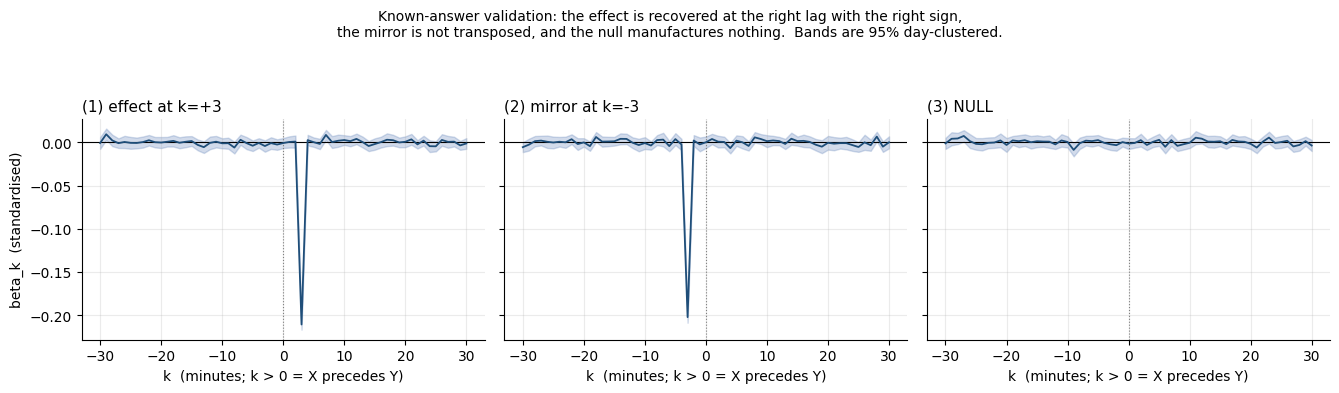

In [41]:
# ============================ COMPUTED ============================
# The three recovered profiles. The estimator finds what is there and nothing else.
banner("COMPUTED", "recovered beta profiles on the synthetic panels")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6), sharey=True)
kk = np.array(LAGS)
for ax, (title, (b, se)) in zip(axes, profiles.items()):
    ax.axhline(0, color="k", lw=0.8)
    ax.axvline(0, color="grey", lw=0.8, ls=":")
    ax.fill_between(kk, b[:61] - 1.96 * se[:61], b[:61] + 1.96 * se[:61],
                    color="#4c72b0", alpha=0.25)
    ax.plot(kk, b[:61], color="#1f4e79", lw=1.3)
    ax.set_xlabel("k  (minutes; k > 0 = X precedes Y)")
    ax.set_title(title, loc="left")
axes[0].set_ylabel("beta_k  (standardised)")
fig.suptitle("Known-answer validation: the effect is recovered at the right lag "
             "with the right sign,\nthe mirror is not transposed, and the null "
             "manufactures nothing.  Bands are 95% day-clustered.",
             fontsize=10, y=1.08)
fig.tight_layout()
savefig(fig, "09_estimator_validation")
plt.show()

## 9b. R0 and R0b — the intraday lead-lag premise. **LOADED.**

**Window R**, not window U: X spans 2026-05-01 .. 2026-08-07, Y 2026-05-07 ..
2026-08-06, **67 CME session dates**. "610 days" must never be attached to an
R0/R0b number.

R0 and R0b differ by **X's direction sign and nothing else**. R0 signs a print
against a *trailing median* mid; R0b against a *real-time Citi USD-SOFR-1D minute
curve* par rate at the print's snapped execution minute. The branch gates this:
`build_x_r0b.py` re-derives R0's own X from the same frame and reports
`unmatched cells 0`, `max |d signed_dv01| = 0.000e+00`.

**The decision row is `clock=diss, split=all, scope=pooled`, day-clustered.** The
pre-registration names the dissemination clock as governing and fixed
day-clustering in advance. A reader who takes the `exec` row as the verdict gets
R0b's pre-print sum at `t = +2.56` rather than the governing `+1.955`.

In [42]:
# ============================ LOADED ============================
# Verdicts and coefficient profiles. data/PROVENANCE.md sections 1a, 1b.
R0V = load_artifact(DATA_DIR / "r0_verdict.txt", "§1a").strip()
R0D = load_artifact(DATA_DIR / "r0_d1_downgrade.txt", "§1a").strip()
R0BV = load_artifact(DATA_DIR / "r0b_verdict.txt", "§1a").strip()
R0_BETAS = load_artifact(DATA_DIR / "r0_betas.csv", "§1b")
R0B_BETAS = load_artifact(DATA_DIR / "r0b_betas.csv", "§1b")
r0t = load_artifact(DATA_DIR / "r0_table.csv", "§1c")
r0bt = load_artifact(DATA_DIR / "r0b_table.csv", "§1c")

print(f"R0   pre-registered decision rule : {R0V}")
print(f"R0   after the power downgrade    : {R0D}")
print(f"R0b  same rule                    : {R0BV}")
assert (R0V, R0D, R0BV) == ("FAIL", "UNINFORMATIVE", "FAIL")
print("""
What FAIL means: 'mass concentrated at k < 0, OR post-print mass indistinguishable
from zero'. It is an absence of measurable post-print response on THIS proxy, on
THIS 67-session window. It is NOT evidence that dealers do not hedge.""")

DEC = dict(clock="diss", split="all", scope="pooled")
row0 = r0t.query("clock == @DEC['clock'] and split == @DEC['split'] "
                 "and scope == @DEC['scope']").iloc[0]
row0b = r0bt.query("clock == @DEC['clock'] and split == @DEC['split'] "
                   "and scope == @DEC['scope']").iloc[0]
dec = pd.DataFrame([
    {"study": "R0  (trailing-median mid)", **{k: row0[k] for k in
     ("n_obs", "n_days", "sum_beta_kneg", "t_cluster_kneg", "sum_beta_kpos",
      "t_cluster_kpos", "beta_k0", "post_print_share")}},
    {"study": "R0b (real-time curve mid)", **{k: row0b[k] for k in
     ("n_obs", "n_days", "sum_beta_kneg", "t_cluster_kneg", "sum_beta_kpos",
      "t_cluster_kpos", "beta_k0", "post_print_share")}}])
print("\nTHE DECISION ROW  (clock=diss, split=all, scope=pooled; day-clustered t):")
print(dec.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

--- LOADED: notebooks\dealer_direction\data\r0_verdict.txt  (5 chars)   [data/PROVENANCE.md §1a]

--- LOADED: notebooks\dealer_direction\data\r0_d1_downgrade.txt  (14 chars)   [data/PROVENANCE.md §1a]

--- LOADED: notebooks\dealer_direction\data\r0b_verdict.txt  (5 chars)   [data/PROVENANCE.md §1a]

--- LOADED: notebooks\dealer_direction\data\r0_betas.csv  (732 rows)   [data/PROVENANCE.md §1b]

--- LOADED: notebooks\dealer_direction\data\r0b_betas.csv  (732 rows)   [data/PROVENANCE.md §1b]

--- LOADED: notebooks\dealer_direction\data\r0_table.csv  (60 rows)   [data/PROVENANCE.md §1c]

--- LOADED: notebooks\dealer_direction\data\r0b_table.csv  (60 rows)   [data/PROVENANCE.md §1c]

R0   pre-registered decision rule : FAIL
R0   after the power downgrade    : UNINFORMATIVE
R0b  same rule                    : FAIL

What FAIL means: 'mass concentrated at k < 0, OR post-print mass indistinguishable
from zero'. It is an absence of measurable post-print response on THIS proxy, on
THIS 67-sessio


THE DECISION ROW  (clock=diss, split=all, scope=pooled; day-clustered t):
                    study  n_obs  n_days  sum_beta_kneg  t_cluster_kneg  sum_beta_kpos  t_cluster_kpos  beta_k0  post_print_share
R0  (trailing-median mid) 402946      67        -0.1075         -5.8963         0.0076          0.5947  -0.0013            0.0662
R0b (real-time curve mid) 402946      67         0.0159          1.9552        -0.0011         -0.1268  -0.0012            0.0670


In [43]:
# ============================ LOADED ============================
# The trough, and why it is an artifact. data/PROVENANCE.md sections 1b, 5.5.
banner("LOADED", "R0's only significant finding, and R0b turning it over",
       "data/PROVENANCE.md §1b, §5.5")

print(f"R0   sum(beta_k, k <= -1) = {row0['sum_beta_kneg']:+.4f}   "
      f"t_cluster = {row0['t_cluster_kneg']:+.2f}    <- R0's ONLY significant result")
print(f"R0b  sum(beta_k, k <= -1) = {row0b['sum_beta_kneg']:+.4f}   "
      f"t_cluster = {row0b['t_cluster_kneg']:+.3f}   <- opposite sign, and NOT "
      f"significant")
print(f"     (Newey-West on the same R0b row is t = {row0b['t_nw_kneg']:+.2f}; "
      f"the prereg fixed\n      day-clustering in advance, so +1.955 governs and "
      f"consoles printing '+1.96' are rounding.)")
assert abs(row0["sum_beta_kneg"] + 0.1075) < 5e-4
assert abs(row0["t_cluster_kneg"] + 5.90) < 0.01
assert abs(row0b["sum_beta_kneg"] - 0.0159) < 5e-4
assert abs(row0b["t_cluster_kneg"] - 1.955) < 0.01
print("""
The two mid rules produce OPPOSITE-SIGNED pre-print mass on the same data, so the
trough is an artifact of R0's own mid rule -- real as a coefficient, meaningless
as a finding. R0's own R0_RESULT.md hypothesised exactly this before R0b was run.
r0b_sign_decomp.csv attributes it: staleness vs cell bias.""")
sd = load_artifact(DATA_DIR / "r0b_sign_decomp.csv", "§1d")
print(sd.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

--- LOADED: R0's only significant finding, and R0b turning it over   [data/PROVENANCE.md §1b, §5.5]

R0   sum(beta_k, k <= -1) = -0.1075   t_cluster = -5.90    <- R0's ONLY significant result
R0b  sum(beta_k, k <= -1) = +0.0159   t_cluster = +1.955   <- opposite sign, and NOT significant
     (Newey-West on the same R0b row is t = +2.38; the prereg fixed
      day-clustering in advance, so +1.955 governs and consoles printing '+1.96' are rounding.)

The two mid rules produce OPPOSITE-SIGNED pre-print mass on the same data, so the
trough is an artifact of R0's own mid rule -- real as a coefficient, meaningless
as a finding. R0's own R0_RESULT.md hypothesised exactly this before R0b was run.
r0b_sign_decomp.csv attributes it: staleness vs cell bias.
--- LOADED: notebooks\dealer_direction\data\r0b_sign_decomp.csv  (3 rows)   [data/PROVENANCE.md §1d]

        source  p_cur  p_med  att_median_rule  att_reference  slack
staleness only 0.0773 0.2917           0.4165         0.8454 0.1828
cell

--- LOADED: R0 and R0b beta profiles, re-plotted from r0_betas.csv / r0b_betas.csv   [data/PROVENANCE.md §1b]



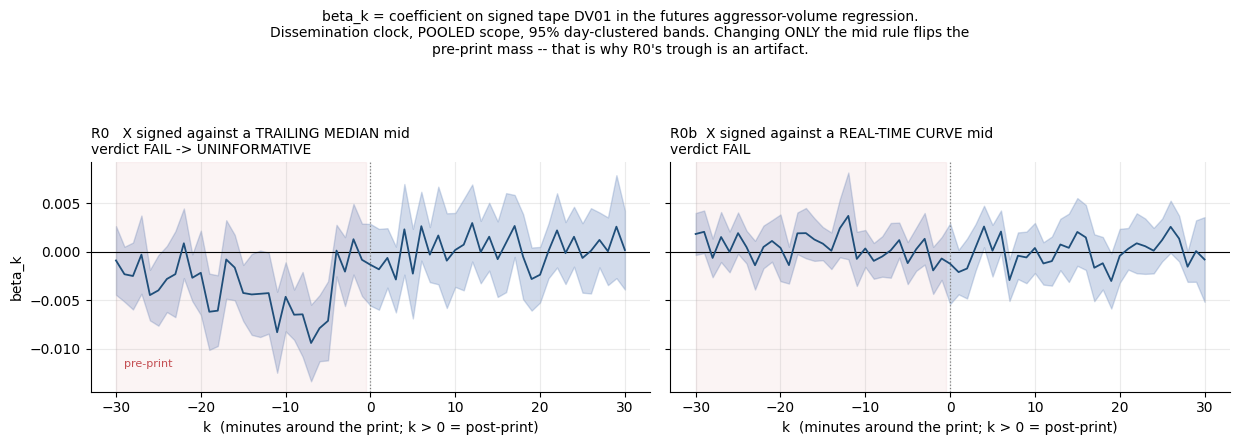

These are NOT a hedge ratio, a P&L or a tradable edge. Nothing in R0/R0b was traded or costed.


In [44]:
# ============================ LOADED ============================
# Re-plot both beta profiles from the CSVs (never from the PNGs -- those are
# tie-out artefacts only). data/PROVENANCE.md section 1b.
banner("LOADED", "R0 and R0b beta profiles, re-plotted from r0_betas.csv / "
       "r0b_betas.csv", "data/PROVENANCE.md §1b")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0), sharey=True)
for ax, (df, name, verdict) in zip(axes, (
        (R0_BETAS, "R0   X signed against a TRAILING MEDIAN mid", R0V + " -> " + R0D),
        (R0B_BETAS, "R0b  X signed against a REAL-TIME CURVE mid", R0BV))):
    d = df.query("clock == 'diss' and bucket == 'POOLED'").sort_values("k")
    ax.axhline(0, color="k", lw=0.8)
    ax.axvline(0, color="grey", lw=0.9, ls=":")
    ax.fill_between(d["k"], d["beta"] - 1.96 * d["se_cluster"],
                    d["beta"] + 1.96 * d["se_cluster"], color="#4c72b0", alpha=0.25)
    ax.plot(d["k"], d["beta"], color="#1f4e79", lw=1.3)
    ax.axvspan(-30, -0.5, color="#c44e52", alpha=0.06)
    ax.set_xlabel("k  (minutes around the print; k > 0 = post-print)")
    ax.set_title(f"{name}\nverdict {verdict}", loc="left", fontsize=10)
axes[0].set_ylabel("beta_k")
axes[0].text(-29, axes[0].get_ylim()[0] * 0.82, "pre-print", fontsize=8,
             color="#c44e52")
fig.suptitle("beta_k = coefficient on signed tape DV01 in the futures aggressor-"
             "volume regression.\nDissemination clock, POOLED scope, 95% "
             "day-clustered bands. Changing ONLY the mid rule flips the\n"
             "pre-print mass -- that is why R0's trough is an artifact.",
             fontsize=10, y=1.10)
fig.tight_layout()
savefig(fig, "09_r0_r0b_betas")
plt.show()
print("These are NOT a hedge ratio, a P&L or a tradable edge. Nothing in R0/R0b "
      "was traded or costed.")

In [45]:
# ============================ LOADED ============================
# The attenuation diagnostic and the informativeness gate.
# data/PROVENANCE.md section 1d.
att = load_artifact(DATA_DIR / "attenuation.csv", "§1d")
dense = load_artifact(DATA_DIR / "r0b_dense_rho.csv", "§1d")
gate = load_artifact(DATA_DIR / "r0b_gate.csv", "§1d")

THR = float(att["downgrade_threshold_rho"].iloc[0])
print(att[["bucket", "scope", "n_prints", "rho_print", "rho_minute", "rho_daily",
           "sign_agreement", "mde"]].to_string(
               index=False, float_format=lambda v: f"{v:,.4f}"))
bk = att[att["scope"] == "bucket"]
print(f"\nrho_minute across the five decision buckets: "
      f"{bk['rho_minute'].min():.3f} ({bk.loc[bk['rho_minute'].idxmin(),'bucket']}) "
      f".. {bk['rho_minute'].max():.3f} "
      f"({bk.loc[bk['rho_minute'].idxmax(),'bucket']})   "
      f"-- ALL below the {THR} downgrade threshold")
assert (bk["rho_minute"] < THR).all()

pooled_rho = dense[dense["bucket"] == "POOLED"]
d1grid = pooled_rho[pooled_rho["grid"].str.startswith("12 tenors")]
RHO = float(d1grid["rho_minute"].iloc[0])
print(f"\nheadline rho = {RHO:.6f}  -- the POOLED / rho_minute cell on D1's "
      f"12-tenor grid")
print("other grids give different numbers; quoting the wrong row silently changes "
      "the story:")
print(pooled_rho[["grid", "rho_print", "rho_minute", "rho_daily"]].to_string(
    index=False, float_format=lambda v: f"{v:,.6f}"))
assert abs(RHO - 0.404717) < 1e-5
print("\nrho is a LOWER BOUND on the proxy's correlation with the true direction. "
      "It does NOT say\nthe tape direction is 40% accurate in any everyday sense.")

g = gate[gate["scope"] == "POOLED"].iloc[0]
lo = g["sum_beta_kpos"] - 1.96 * g["se_cluster_kpos"]
hi = g["sum_beta_kpos"] + 1.96 * g["se_cluster_kpos"]
print(f"\nR0b informativeness gate, POOLED:")
print(f"  sum_beta_kpos    {g['sum_beta_kpos']:+.7f}")
print(f"  se_cluster_kpos  {g['se_cluster_kpos']:.7f}")
print(f"  mde (=1.96*se)   {g['mde']:.7f}")
print(f"  95% interval on the post-print sum, recomputed as sum +/- 1.96*se:")
print(f"      ({lo:+.5f}, {hi:+.5f})")
print(f"  informative in all six scopes: {sorted(set(gate['informative']))}")
assert abs(lo + 0.01881) < 5e-5 and abs(hi - 0.01652) < 5e-5
assert not gate["informative"].any()
print("\n=> the intraday lead-lag premise is CLOSED on this window: R0 "
      "UNINFORMATIVE on power,\n   R0b FAIL with a post-print interval that "
      "excludes anything of interest.")

--- LOADED: notebooks\dealer_direction\data\attenuation.csv  (6 rows)   [data/PROVENANCE.md §1d]

--- LOADED: notebooks\dealer_direction\data\r0b_dense_rho.csv  (24 rows)   [data/PROVENANCE.md §1d]

--- LOADED: notebooks\dealer_direction\data\r0b_gate.csv  (6 rows)   [data/PROVENANCE.md §1d]

bucket                 scope  n_prints  rho_print  rho_minute  rho_daily  sign_agreement    mde
SFR_FF                bucket     13939     0.3971      0.3454     0.0227          0.6410 0.2632
    TU                bucket     17449     0.4563      0.3791     0.1730          0.6862 0.1537
    FV                bucket     41604     0.4890      0.4141     0.2080          0.6995 0.0890
TY_UXY                bucket     42173     0.5533      0.4896     0.4175          0.6861 0.0817
    US                bucket     25827     0.4725      0.3167     0.2407          0.6730 0.1855
POOLED pooled(DV01-weighted)    140992     0.4985      0.4047     0.2743          0.6832 0.0620

rho_minute across the five decisi

## 9c. S1 — swap-spread flow → swap spread. **LOADED. DEAD.**

**Window S** (2024-03-01 .. 2025-08-31; the hold-out was not opened).
The headline is the **35 `primary × D2C` cells** (7 tenors × 5 horizons).

> ### ⚠ The S1 pre-registration contains a **sign error**, and it is recorded, not dropped.
>
> `S_PREREG.md:86-90` reasons "customer pays the spread → dealer receives →
> dealer is *long* the spread". **Wrong at the third step.** Paying a swap spread
> is paying fixed and buying the Treasury; that gains when the spread *widens*,
> so the customer is long and **the dealer is short**. S1's predicted sign is
> **β > 0**, not β < 0.
>
> **What it changes**: it withdraws the claim that "the deepest buckets go the
> wrong way" — under the corrected direction those are the *expected* sign. The
> `beta_sign_expected`, `sign_ok` and `verdict` columns of `s1_results.csv` were
> all computed under the erroneous sign.
>
> **What it does not change**: the verdict. Zero cells are significant in *either*
> direction. A sign error cannot rescue a result that is not significant either
> way, and the results were deliberately **not** re-read under the corrected sign
> to look for a finding. (`S_DEVIATIONS.md` §D1.)
>
> **One number in that deviation note does not reproduce, and the notebook
> checks rather than repeats it.** `S_DEVIATIONS.md:45` records "the
> DEAD-vs-`AMBIGUOUS` split is convention-dependent for **11 of 35** cells". The
> cell after next re-runs S1's own frozen verdict ladder over the artefact under
> both signs. It reproduces the file exactly under the pre-registered sign, and
> **no cell changes label** under the corrected one — because the only branch
> that reads `sign_ok` is `WRONG_SIGN`, which *also* requires a significant β,
> and nothing is significant. The correct count is **0 of 35**, which
> strengthens the note's own conclusion ("none of them crosses into PASS")
> rather than weakening it. What *does* flip on all 35 cells is the `sign_ok`
> flag itself, and that is a different quantity.

In [46]:
# ============================ LOADED ============================
# S1. IN-TREE: BT/dd_signals/out/s1_results.csv @ c0b7d0f0.
s1 = load_artifact(REPO / "BT" / "dd_signals" / "out" / "s1_results.csv",
                   "§3 (IN-TREE), and §5.3 for the sign error")
prim = s1.query("spec == 'primary' and venue == 'D2C'").copy()
print(f"the S1 headline population: {len(prim)} primary x D2C cells "
      f"({prim['tenor'].nunique()} tenors x {prim['k'].nunique()} horizons)")
print(f"significant on beta : {int(prim['beta_significant'].sum())}")
print(f"significant on edge : {int(prim['edge_significant'].sum())}")
print(f"largest |beta_t|    : {prim['beta_t'].abs().max():.4f}   against "
      f"size-corrected criticals {prim['crit_beta'].min():.4f}"
      f"-{prim['crit_beta'].max():.4f}")
prim["clears"] = prim["edge_bps_per_trade"] > prim["kill_ceiling_bps"]
print(f"edge below its own cost hurdle in {int((~prim['clears']).sum())} of "
      f"{len(prim)} cells")
assert int(prim["beta_significant"].sum()) == 0
assert int(prim["edge_significant"].sum()) == 0
assert int((~prim["clears"]).sum()) == len(prim)

cell10 = prim.query("tenor == '10Y' and k == 3").iloc[0]
best = prim.loc[prim["edge_bps_per_trade"].idxmax()]
print(f"\nthe QUOTED cell -- 10Y D2C k=3:  edge "
      f"{cell10['edge_bps_per_trade']:.3f} bp/trade against a "
      f"{cell10['kill_ceiling_bps']:.3f} bp hurdle, "
      f"{cell10['kill_ceiling_bps']/cell10['edge_bps_per_trade']:.1f}x short")
print(f"the LARGEST edge over all 35 cells -- {best['tenor']} D2C k={int(best['k'])}: "
      f"{best['edge_bps_per_trade']:.3f} bp against its OWN "
      f"{best['kill_ceiling_bps']:.3f} bp hurdle, "
      f"{best['kill_ceiling_bps']/best['edge_bps_per_trade']:.1f}x short")
print("Both readings give DEAD. Presenting 0.117 as the best cell ANYWHERE would "
      "be wrong --")
print("and two documents in this tree carried exactly that reading. An "
      "unattributed disagreement\nis not a check, so they are named:")
for _doc in ("docs/dealer_direction/signals/S_DEVIATIONS.md",
             "docs/dealer_direction/PR_BODY.md"):
    _p = REPO / _doc
    _txt = (_p.read_text(encoding="utf-8", errors="replace")
            if _p.exists() else "")
    print(f"  {_doc:<48}  present in tree: {str(_p.exists()):<5}  "
          f"carries 0.174 (the true maximum): {'0.174' in _txt}")
print("  Read at run time and NOT asserted: both are being corrected, and this "
      "cell is the check\n  behind the correction rather than a test of its "
      "progress. What the notebook owns is the\n  number; the documents own "
      "their own text.")
assert abs(cell10["edge_bps_per_trade"] - 0.117) < 5e-4
assert abs(best["edge_bps_per_trade"] - 0.174) < 5e-4

print(f"\nCOLUMN TRAP: mde_bps is the MDE in bp; mde_over_ceiling is that divided "
      f"by the hurdle.\nS1_RESULT.md's row headed 'MDE / hurdle 0.659' is "
      f"mde_bps, NOT the ratio:")
t10 = prim.query("tenor == '10Y'").sort_values("k")
print(t10[["tenor", "k", "edge_bps_per_trade", "kill_ceiling_bps", "mde_bps",
           "mde_over_ceiling"]].to_string(index=False,
                                          float_format=lambda v: f"{v:,.4f}"))

print(f"\nthe columns computed under the ERRONEOUS pre-registered sign "
      f"(S_DEVIATIONS.md D1):")
print(prim.groupby(["beta_sign_expected", "sign_ok", "verdict"]).size().to_string())

--- LOADED: BT\dd_signals\out\s1_results.csv  (140 rows)   [data/PROVENANCE.md §3 (IN-TREE), and §5.3 for the sign error]

the S1 headline population: 35 primary x D2C cells (7 tenors x 5 horizons)
significant on beta : 0
significant on edge : 0
largest |beta_t|    : 1.6551   against size-corrected criticals 2.5124-2.6309
edge below its own cost hurdle in 35 of 35 cells

the QUOTED cell -- 10Y D2C k=3:  edge 0.117 bp/trade against a 0.659 bp hurdle, 5.6x short
the LARGEST edge over all 35 cells -- 20Y D2C k=5: 0.174 bp against its OWN 1.332 bp hurdle, 7.7x short
Both readings give DEAD. Presenting 0.117 as the best cell ANYWHERE would be wrong --
and two documents in this tree carried exactly that reading. An unattributed disagreement
is not a check, so they are named:
  docs/dealer_direction/signals/S_DEVIATIONS.md     present in tree: True   carries 0.174 (the true maximum): True
  docs/dealer_direction/PR_BODY.md                  present in tree: True   carries 0.174 (the true maxim

In [47]:
# ============================ COMPUTED ============================
# Re-run S1's own frozen verdict ladder over the artefact, under BOTH signs.
# This checks S_DEVIATIONS.md D1's "11 of 35" rather than repeating it.
banner("COMPUTED", "S1's verdict ladder, re-derived from s1_results.csv under "
       "both sign conventions")

MIN_BUCKET_DAYS = 200        # BT/dd_signals/s1_spread_flow.py:132


def s1_verdict(r, expected_sign):
    """The ladder at s1_spread_flow.py:728-739, verbatim, off the CSV's columns."""
    sign_ok = np.sign(r.beta_bps_per_unit_F) == expected_sign
    sig_beta = abs(r.beta_t) > r.crit_beta
    sig_edge = abs(r.edge_t) > r.crit_edge
    if r.usable_bucket_days < MIN_BUCKET_DAYS:
        return "UNINFORMATIVE_COVERAGE"
    if (not sign_ok) and sig_beta:
        return "WRONG_SIGN"
    if (np.isfinite(r.kill_ceiling_bps) and r.edge_bps_per_trade >= r.kill_ceiling_bps
            and sig_edge and r.edge_bps_per_trade > 0):
        return "PASS"
    if np.isfinite(r.kill_floor_bps) and r.edge_upper_sizecorr < r.kill_floor_bps:
        return "DEAD"
    if np.isfinite(r.kill_ceiling_bps) and r.mde_bps > r.kill_ceiling_bps:
        return "UNINFORMATIVE_POWER"
    return "AMBIGUOUS"


chk = prim.copy()
chk["v_prereg"] = [s1_verdict(r, -1) for r in chk.itertuples()]   # as registered
chk["v_corrected"] = [s1_verdict(r, +1) for r in chk.itertuples()]  # as corrected

n_repro = int((chk["v_prereg"] == chk["verdict"]).sum())
print(f"re-derived verdict reproduces the file under the PRE-REGISTERED sign "
      f"(beta < 0): {n_repro} of {len(chk)}")
assert n_repro == len(chk), "the ladder does not reproduce the artefact"

n_flip = int((chk["v_prereg"] != chk["v_corrected"]).sum())
n_signok = int((chk["sign_ok"] != (np.sign(chk["beta_bps_per_unit_F"]) == +1)).sum())
print(f"cells whose SIGN_OK FLAG flips under the corrected sign (beta > 0): "
      f"{n_signok} of {len(chk)}")
print(f"cells whose VERDICT changes under the corrected sign:              "
      f"{n_flip} of {len(chk)}")
print(pd.crosstab(chk["v_prereg"], chk["v_corrected"]).to_string())
assert n_flip == 0

print(f"""
DISAGREEMENT WITH THE DOC, and it goes the safe way.
  S_DEVIATIONS.md:45 records the DEAD-vs-AMBIGUOUS split as 'convention-dependent
  for 11 of 35 cells'. Re-running the frozen ladder over the artefact gives {n_flip}.
  The reason is structural: `sign_ok` enters the ladder in exactly ONE branch,
  `(not sign_ok) and sig_beta -> WRONG_SIGN`, and `sig_beta` is False in all 35
  cells ({int(prim['beta_significant'].sum())} significant, max |t| """
      f"""{prim['beta_t'].abs().max():.2f} vs criticals """
      f"""{prim['crit_beta'].min():.2f}-{prim['crit_beta'].max():.2f}). With no
  significant beta the sign convention cannot reach the label at all.
  This STRENGTHENS the note's own conclusion ('none of them crosses into PASS').
  The sign error is still real, still recorded, and still the reason the 'deepest
  buckets go the wrong way' characterisation was withdrawn -- it just does not
  move a single verdict in this artefact.""")

--- COMPUTED: S1's verdict ladder, re-derived from s1_results.csv under both sign conventions

re-derived verdict reproduces the file under the PRE-REGISTERED sign (beta < 0): 35 of 35
cells whose SIGN_OK FLAG flips under the corrected sign (beta > 0): 35 of 35
cells whose VERDICT changes under the corrected sign:              0 of 35
v_corrected             AMBIGUOUS  DEAD  UNINFORMATIVE_COVERAGE
v_prereg                                                       
AMBIGUOUS                       7     0                       0
DEAD                            0    23                       0
UNINFORMATIVE_COVERAGE          0     0                       5

DISAGREEMENT WITH THE DOC, and it goes the safe way.
  S_DEVIATIONS.md:45 records the DEAD-vs-AMBIGUOUS split as 'convention-dependent
  for 11 of 35 cells'. Re-running the frozen ladder over the artefact gives 0.
  The reason is structural: `sign_ok` enters the ladder in exactly ONE branch,
  `(not sign_ok) and sig_beta -> WRONG_SIGN`, and

--- LOADED: S1: every primary D2C cell against its own cost hurdle   [data/PROVENANCE.md §3; sign error in §5.3]



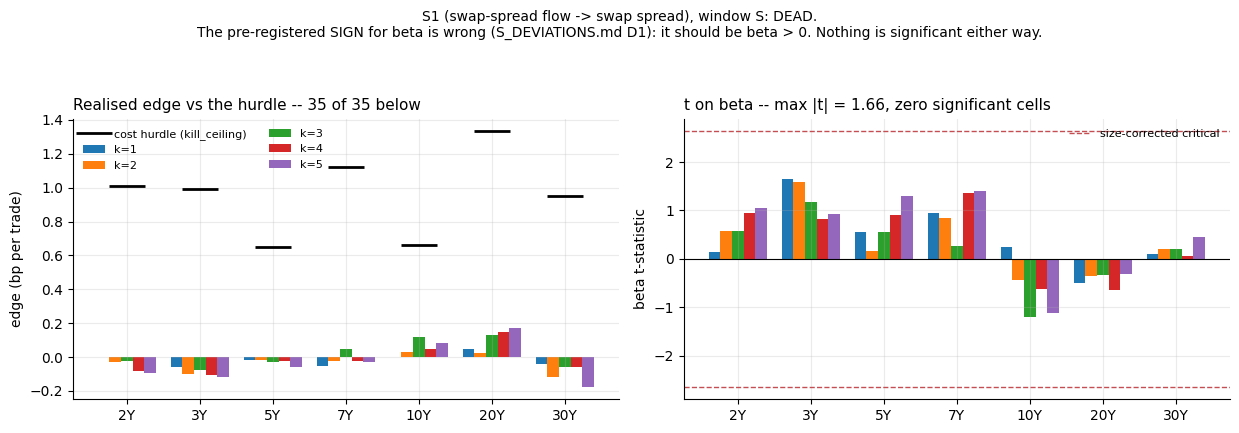

In [48]:
# ============================ LOADED ============================
# S1's 35 cells against their own hurdles. data/PROVENANCE.md section 3, section 5.3.
banner("LOADED", "S1: every primary D2C cell against its own cost hurdle",
       "data/PROVENANCE.md §3; sign error in §5.3")

_TORD = {"2Y": 0, "3Y": 1, "5Y": 2, "7Y": 3, "10Y": 4, "20Y": 5, "30Y": 6}
tenors = sorted(dict.fromkeys(prim["tenor"]), key=lambda t: _TORD.get(t, 99))
ks = sorted(prim["k"].unique())
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0))
w = 0.8 / len(ks)
for i, kk_ in enumerate(ks):
    d = prim[prim["k"] == kk_].set_index("tenor").reindex(tenors)
    axes[0].bar(np.arange(len(tenors)) + (i - (len(ks) - 1) / 2) * w,
                d["edge_bps_per_trade"], width=w, label=f"k={kk_}")
d0 = prim.groupby("tenor")["kill_ceiling_bps"].first().reindex(tenors)
axes[0].plot(np.arange(len(tenors)), d0, "k_", markersize=26, mew=2,
             label="cost hurdle (kill_ceiling)")
axes[0].set_xticks(range(len(tenors)))
axes[0].set_xticklabels(tenors)
axes[0].set_ylabel("edge (bp per trade)")
axes[0].set_title("Realised edge vs the hurdle -- 35 of 35 below", loc="left")
axes[0].legend(fontsize=8, ncol=2)

axes[1].axhline(0, color="k", lw=0.8)
for c, lab in ((prim["crit_beta"].max(), "size-corrected critical"),
               (-prim["crit_beta"].max(), None)):
    axes[1].axhline(c, color="#c44e52", ls="--", lw=1, label=lab)
for i, kk_ in enumerate(ks):
    d = prim[prim["k"] == kk_].set_index("tenor").reindex(tenors)
    axes[1].bar(np.arange(len(tenors)) + (i - (len(ks) - 1) / 2) * w,
                d["beta_t"], width=w)
axes[1].set_xticks(range(len(tenors)))
axes[1].set_xticklabels(tenors)
axes[1].set_ylabel("beta t-statistic")
axes[1].set_title(f"t on beta -- max |t| = {prim['beta_t'].abs().max():.2f}, "
                  f"zero significant cells", loc="left")
axes[1].legend(fontsize=8)
fig.suptitle("S1 (swap-spread flow -> swap spread), window S: DEAD.\n"
             "The pre-registered SIGN for beta is wrong (S_DEVIATIONS.md D1): it "
             "should be beta > 0. Nothing is significant either way.",
             fontsize=10, y=1.07)
fig.tight_layout()
savefig(fig, "09_s1_cells")
plt.show()

## 9d. S2 — positioning → reversal. **LOADED. UNINFORMATIVE.**

> ### The "powered null" claim is **WITHDRAWN**
>
> `s2_results.csv` was read as "the first cell in the programme with the power to
> have seen a hurdle-sized effect". Any one of three reasons is sufficient to
> withdraw that (`S_DEVIATIONS.md` §D2): the hurdle it is powered against is not
> a cost; the size correction S1 applied was **not** applied to S2 and flipping
> it flips the verdict (Driscoll–Kraay rejects a true null at 7.8% against a
> nominal 5%; the corrected critical 2.896 gives pooled MDE **2.239 > 2.154** →
> `UNINFORMATIVE_POWER`); and the pooled panel is **not the pre-registered
> unit** — `S_PREREG.md` registers within-bucket only. The `mde_beta` /
> `mde_beta_dk` / `mde_edge_dk` columns use the **uncorrected** normal multiplier
> `MDE_Z = 3.083`.
>
> **What stands: S2 is UNINFORMATIVE.** Pooled β = +0.024, t = +0.04, edge
> **−0.32 bp**. The edge is *negative*, so the cost caveat is not what binds — a
> negative edge clears no cost of any size.

In [49]:
# ============================ LOADED ============================
# S2. IN-TREE: BT/dd_signals/out/s2_results.csv @ c0b7d0f0.
s2 = load_artifact(REPO / "BT" / "dd_signals" / "out" / "s2_results.csv",
                   "§3 (IN-TREE), and §5.4 for the withdrawn 'powered null'")
pool = s2[s2["cell"] == "POOLED_UNCONDITIONAL"].iloc[0]
print(f"POOLED_UNCONDITIONAL   beta_z {pool['beta_z']:+.4f}   "
      f"t_z_dk {pool['t_z_dk']:+.4f}   edge {pool['edge_bps']:+.4f} bp")
print(f"                       n_obs {int(pool['n_obs']):,}   "
      f"n_days {int(pool['n_days'])}   verdict {pool['verdict']}")
assert abs(pool["beta_z"] - 0.024) < 5e-4
assert abs(pool["t_z_dk"] - 0.036) < 5e-3
assert abs(pool["edge_bps"] + 0.3165) < 5e-4

buckets = s2[s2["cell"].str.startswith("BUCKET::")].copy()
buckets["bucket"] = buckets["cell"].str.replace("BUCKET::", "", regex=False)
print(f"\nthe {len(buckets)} PRE-REGISTERED per-bucket cells "
      f"(these, not the pooled row, are the registered unit):")
print(buckets[["bucket", "n_obs", "n_days", "beta_z", "t_z_dk", "edge_bps",
               "verdict"]].to_string(index=False,
                                     float_format=lambda v: f"{v:,.4f}"))
vc = buckets["verdict"].value_counts()
print(f"\n{vc.to_dict()}")
assert int(vc.get("UNINFORMATIVE_POWER", 0)) == 8

desc = load_artifact(REPO / "BT" / "dd_signals" / "out" /
                     "s2_panel_description.csv", "§3 (IN-TREE)")
print(f"\nBUCKET COUNT TRAP: s2_results.csv carries {len(buckets)} BUCKET:: cells; "
      f"the panel files carry {len(desc)}.")
print(f"  (and the join key is not even spelled the same: the panel calls it "
      f"{[c for c in desc.columns if 'bucket' in c]}, the results file encodes "
      f"it in `cell`.)")
missing = sorted(set(desc["bucket_key"]) - set(buckets["bucket"]))
print(f"  absent from the results: {missing}")
print(f"  and that is PRE-REGISTERED, not a scope reduction: S_PREREG.md excludes "
      f"1-2Y from S2\n  because its exclusion rate drifts +5.07 pp/yr (t = +3.21) "
      f"-- the same drift section 8\n  showed breaks z's retention invariance. A "
      f"join on `bucket` silently drops it.")
assert missing == ["1-2Y"]

plac = s2[s2["cell"].str.contains("PLACEBO", na=False)]
if len(plac):
    print(f"\nthe placebo, which is NOT a leak:")
    print(plac[["cell", "beta_z", "t_z_dk", "edge_bps", "verdict"]].to_string(
        index=False, float_format=lambda v: f"{v:,.4f}"))
    print("  flow shifted FORWARD five sessions predicts a return that already "
          "happened, so it\n  measures customer flow responding to a move -- and "
          "it demonstrates the estimator can\n  resolve a real relation in this "
          "very panel.")

--- LOADED: BT\dd_signals\out\s2_results.csv  (13 rows)   [data/PROVENANCE.md §3 (IN-TREE), and §5.4 for the withdrawn 'powered null']

POOLED_UNCONDITIONAL   beta_z +0.0240   t_z_dk +0.0361   edge -0.3165 bp
                       n_obs 2,763   n_days 307   verdict UNINFORMATIVE_COST

the 9 PRE-REGISTERED per-bucket cells (these, not the pooled row, are the registered unit):
bucket  n_obs  n_days  beta_z  t_z_dk  edge_bps             verdict
  0-1Y    307     307  1.1290  1.2873    1.1353  UNINFORMATIVE_COST
10-15Y    307     307 -0.3455 -0.3312   -0.2715 UNINFORMATIVE_POWER
15-20Y    307     307 -0.1389 -0.1716   -0.8880 UNINFORMATIVE_POWER
  2-3Y    307     307 -0.3886 -0.3298   -0.8336 UNINFORMATIVE_POWER
20-30Y    307     307  0.2055  0.2017   -1.1011 UNINFORMATIVE_POWER
  3-5Y    307     307 -0.3144 -0.2952   -0.9907 UNINFORMATIVE_POWER
  30Y+    307     307  0.3330  0.5563    1.1782 UNINFORMATIVE_POWER
  5-7Y    307     307 -0.6624 -0.6201   -0.5289 UNINFORMATIVE_POWER
 7-10Y   

--- LOADED: S2 per-bucket betas and their (uncorrected) MDEs   [data/PROVENANCE.md §3, withdrawal in §5.4]



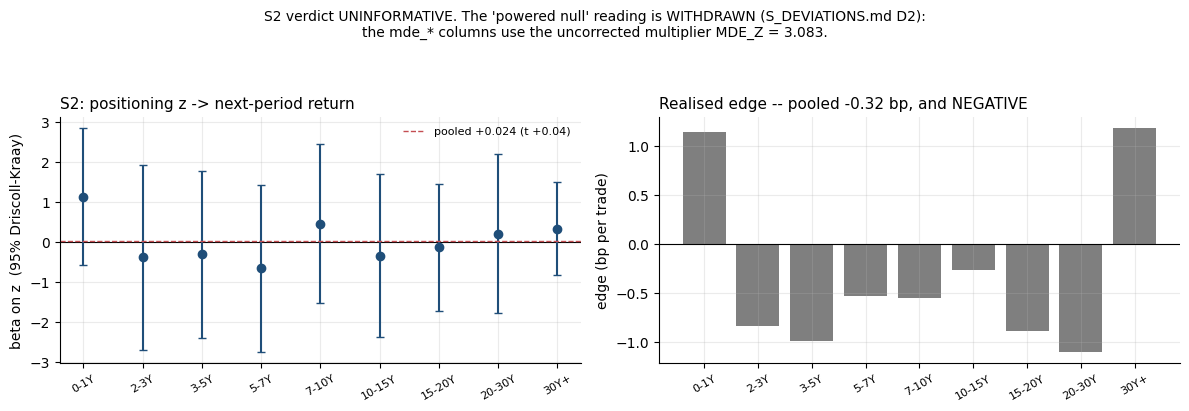

In [50]:
# ============================ LOADED ============================
banner("LOADED", "S2 per-bucket betas and their (uncorrected) MDEs",
       "data/PROVENANCE.md §3, withdrawal in §5.4")

b = buckets.copy()
o = {x: i for i, x in enumerate(ind.TENOR_BUCKETS)}
b["_o"] = b["bucket"].map(o)
b = b.sort_values("_o")
fig, axes = plt.subplots(1, 2, figsize=(12.0, 3.8))
axes[0].axhline(0, color="k", lw=0.8)
axes[0].errorbar(range(len(b)), b["beta_z"], yerr=1.96 * b["se_z_dk"], fmt="o",
                 color="#1f4e79", capsize=3)
axes[0].axhline(pool["beta_z"], color="#c44e52", ls="--", lw=1,
                label=f"pooled {pool['beta_z']:+.3f} (t {pool['t_z_dk']:+.2f})")
axes[0].set_xticks(range(len(b)))
axes[0].set_xticklabels(b["bucket"], rotation=30, fontsize=8)
axes[0].set_ylabel("beta on z  (95% Driscoll-Kraay)")
axes[0].set_title("S2: positioning z -> next-period return", loc="left")
axes[0].legend(fontsize=8)

axes[1].bar(range(len(b)), b["edge_bps"], color="#7f7f7f")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xticks(range(len(b)))
axes[1].set_xticklabels(b["bucket"], rotation=30, fontsize=8)
axes[1].set_ylabel("edge (bp per trade)")
axes[1].set_title(f"Realised edge -- pooled {pool['edge_bps']:+.2f} bp, "
                  f"and NEGATIVE", loc="left")
fig.suptitle("S2 verdict UNINFORMATIVE. The 'powered null' reading is WITHDRAWN "
             "(S_DEVIATIONS.md D2):\nthe mde_* columns use the uncorrected "
             "multiplier MDE_Z = 3.083.", fontsize=10, y=1.07)
fig.tight_layout()
savefig(fig, "09_s2_buckets")
plt.show()

---
# 10. What this cannot say

Every limit below is quantified, and none of them is fixable by trying harder on
the same data.

In [51]:
# ============================ COMPUTED + LOADED ============================
# The limits, with their numbers. Sources named per line.
from SDRUtils.dealer_direction import imputation as imp

banner("COMPUTED + LOADED", "the quantified limits")

lim = [
    ("cross-sectional LEVELS are forbidden",
     f"retention {BEST:.3f} at {b_best} vs {WORST:.3f} at {b_worst} "
     f"= {BEST/WORST:.2f}x; z is exactly invariant to a CONSTANT factor, "
     f"levels are not",
     "COMPUTED §8 + LOADED bucket_retention_DERIVED.csv"),
    ("PKG-4+ DV01 that is genuinely unidentifiable",
     f"{PP_AMBIG_DV01:.2f}% -- several mutually inconsistent sign vectors fit "
     f"inside one tolerance; the recovery is {PP_IDENT-PP_BASE:+.2f} pp, "
     f"to {PP_IDENT:.2f}%, not to 79.12% or 71.92%",
     "LOADED scratch/ppfix_results.txt"),
    ("tape DV01 that is IMPUTED rather than observed",
     f"{imp.IMPUTED_DV01_SHARE:.2%} of the DV01 proxy "
     f"({imp.IMPUTED_NOTIONAL_SHARE:.2%} of notional) sits behind a Part 43 "
     f"notional cap; leg-by-leg {imp.IMPUTED_DV01_SHARE_LEG_BY_LEG:.2%}",
     "COMPUTED from imputation.py's pinned constants"),
    ("NEWT-EXER / NEWT-NOVA contamination that CANNOT be removed",
     "~3.1% of legs. All four tape flags are literally `false` on all 2,326,781 "
     "rows, so a filter on them returns cleanly and excludes nothing. A "
     "NEWT-EXER prints at the swaption strike (~374/week) and the rate rule "
     "answers it loudly and meaninglessly; a NEWT-NOVA (~435/week) is a "
     "dealer-to-dealer transfer counted as customer flow",
     "COMPUTED from universe.EXERCISE_NOVATION_FLAGS + LOADED §2"),
    ("compression is INVISIBLE, so the series will not cumulate",
     "compression and allocation are never publicly reported: risk leaves a "
     "book with no offsetting print, so a running sum carries an unbounded, "
     "MONOTONE error. indicator.cumulate() refuses (shown firing in §8)",
     "COMPUTED §8"),
    ("the S1 pre-registration has a SIGN ERROR",
     f"the predicted sign is beta > 0, not beta < 0; beta_sign_expected / "
     f"sign_ok / verdict in s1_results.csv were all computed under the wrong "
     f"one, and sign_ok flips on {n_signok} of {len(chk)} cells. Re-running "
     f"S1's own frozen verdict ladder over the artefact under both signs "
     f"changes {n_flip} verdicts (the doc says 11; see section 9c), because "
     f"the only branch reading sign_ok also requires a significant beta and "
     f"nothing is significant. The verdict is unchanged either way",
     "COMPUTED §9c + LOADED §5.3 / S_DEVIATIONS.md D1"),
    ("the package rule has NO p of its own (the S3 gap)",
     f"all {len(pk)} recovered packages carry a BORROWED, b0-zeroed rate-rule "
     f"tau; mean |2p-1| {pk['signed_weight'].abs().mean():.3f} vs "
     f"{upw['signed_weight'].abs().mean():.3f} for the upfront rule, and "
     f"{int(pk['in_dead_zone'].sum())} of {len(pk)} in the dead zone. The "
     f"borrowed tau is on the WRONG SCALE",
     "COMPUTED §6"),
    ("the intraday lead-lag premise is CLOSED, not answered",
     f"R0 {R0V} -> {R0D} on power (rho {RHO:.3f}); R0b {R0BV} with a post-print "
     f"95% interval ({lo:+.4f}, {hi:+.4f}). 67 CME sessions, one proxy. FAIL is "
     f"an absence of measurable response, not evidence dealers do not hedge",
     "LOADED §1a-1d"),
    ("three days is a WALK-THROUGH, not a sample",
     f"nothing in sections 1-8 is a signal claim. z needs "
     f"indicator.Z_MIN_OBS = {ind.Z_MIN_OBS} sessions of own history and this "
     f"window has {len(DAYS)}",
     "COMPUTED"),
    ("the daily frame's EDGE DATES are truncated by construction",
     f"{off/n_units:.2%} of units are stamped off their own tape date, so the "
     f"first and last availability rows are partial. Read as sessions they are "
     f"a ~95% drop in flow that never happened",
     "COMPUTED §8"),
    ("FED_FUNDS is supported by construction and NOT exercised",
     f"Config.indices = {cfg.indices}. config(indices=('SOFR','FED_FUNDS')) is a "
     f"one-word change and the self-test never runs it; the window carries 254 "
     f"kept FED_FUNDS units that would arrive with it",
     "COMPUTED from dd_nb.Config"),
]
for i, (title, detail, src) in enumerate(lim, 1):
    print(f"{i:>2}. {title}")
    for line in textwrap.wrap(detail, 92):
        print(f"    {line}")
    print(f"    [{src}]\n")

--- COMPUTED + LOADED: the quantified limits

 1. cross-sectional LEVELS are forbidden
    retention 0.761 at 0-1Y vs 0.495 at 15-20Y = 1.54x; z is exactly invariant to a CONSTANT
    factor, levels are not
    [COMPUTED §8 + LOADED bucket_retention_DERIVED.csv]

 2. PKG-4+ DV01 that is genuinely unidentifiable
    64.22% -- several mutually inconsistent sign vectors fit inside one tolerance; the recovery
    is +0.93 pp, to 57.89%, not to 79.12% or 71.92%
    [LOADED scratch/ppfix_results.txt]

 3. tape DV01 that is IMPUTED rather than observed
    15.97% of the DV01 proxy (27.83% of notional) sits behind a Part 43 notional cap; leg-by-leg
    16.22%
    [COMPUTED from imputation.py's pinned constants]

 4. NEWT-EXER / NEWT-NOVA contamination that CANNOT be removed
    ~3.1% of legs. All four tape flags are literally `false` on all 2,326,781 rows, so a filter
    on them returns cleanly and excludes nothing. A NEWT-EXER prints at the swaption strike
    (~374/week) and the rate rule a

---
# Appendix — coverage, and the two traps the pilot window contains

Both are measured, both are properties of the data rather than of the pipeline,
and both would be misread if the notebook only reported a headline coverage
percentage.

In [52]:
# ============================ COMPUTED ============================
# Priced fraction, stratified -- and the two traps behind the strata.
banner("COMPUTED", "priced fraction by start class, per day and pooled")

pf_ = dd_nb.priced_fraction(pipe.pricing)
print(pf_.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
n_ok = len(pipe.pricing.priced)
n_all = len(pipe.pricing.units)
print(f"\nunit level: {n_ok:,} of {n_all:,} = {n_ok/n_all:.2%}")
print("\nfailures by day and reason:")
print(pipe.pricing.failures.groupby(["as_of_date", "failure"]).size().to_string())
print("\nTRAP 1 -- the failures are not a flaky curve. Incompletely priced "
      "New York hours\nof the snap, PER DAY (pooling three days would turn "
      "'every 22:00 ET print on 06-17\nfailed' into '36% of 22:00 ET prints "
      "failed'):")
print(dd_nb.snap_hour_coverage(pipe.pricing).to_string(
    index=False, float_format=lambda v: f"{v:.4f}"))
print("Citi's minute store publishes roughly 01:00-19:59 ET. That is the hole.")

--- COMPUTED: priced fraction by start class, per day and pooled

as_of_date   start_class  n_legs  priced_frac
2025-06-16 FORWARD_START     632       1.0000
2025-06-16    PAST_START     203       1.0000
2025-06-16          SPOT    1181       1.0000
2025-06-17 FORWARD_START     875       0.9086
2025-06-17    PAST_START     138       0.9130
2025-06-17          SPOT    1413       0.9766
2025-06-18 FORWARD_START    2010       1.0000
2025-06-18    PAST_START     172       1.0000
2025-06-18          SPOT     314       1.0000
       ALL FORWARD_START    3517       0.9773
       ALL    PAST_START     513       0.9766
       ALL          SPOT    2908       0.9887

unit level: 4,938 of 5,032 = 98.13%

failures by day and reason:
as_of_date  failure 
2025-06-17  NO_CURVE    94

TRAP 1 -- the failures are not a flaky curve. Incompletely priced New York hours
of the snap, PER DAY (pooling three days would turn 'every 22:00 ET print on 06-17
failed' into '36% of 22:00 ET prints failed'):
as_of_date

In [53]:
# ============================ COMPUTED ============================
# TRAP 2 -- a holiday moves a whole session's spot book into the forward stratum.
banner("COMPUTED", "spot_window_check: the spot window is CALENDAR days")

sw = dd_nb.spot_window_check(pipe.pricing)
print(sw.to_string(index=False))
from SDRUtils.dealer_direction import midprice
print(f"\nmidprice._SPOT_WINDOW_DAYS = {midprice._SPOT_WINDOW_DAYS} CALENDAR days, "
      f"but spot settlement is T+2 BUSINESS days.")
print("2025-06-19 is Juneteenth, so T+2 from Wednesday 2025-06-18 is Monday "
      "2025-06-23 -- five\ncalendar days out, outside the window. That is why "
      "06-18's book is labelled FORWARD_START\nwhile the two days before it are "
      "SPOT. Only the LABEL moves: no mid, no deviation and\nno risk changes.")

--- COMPUTED: spot_window_check: the spot window is CALENDAR days

as_of_date modal_effective_date  n_legs_at_modal  modal_days_from_snap                start_class_at_modal  spot_window_days
2025-06-16           2025-06-18             1109                     2                      {'SPOT': 1109}                 3
2025-06-17           2025-06-20             1213                     3 {'SPOT': 1153, 'FORWARD_START': 60}                 3
2025-06-18           2025-06-23             1138                     5             {'FORWARD_START': 1138}                 3

midprice._SPOT_WINDOW_DAYS = 3 CALENDAR days, but spot settlement is T+2 BUSINESS days.
2025-06-19 is Juneteenth, so T+2 from Wednesday 2025-06-18 is Monday 2025-06-23 -- five
calendar days out, outside the window. That is why 06-18's book is labelled FORWARD_START
while the two days before it are SPOT. Only the LABEL moves: no mid, no deviation and
no risk changes.


In [54]:
# ====== COMPUTED  (the tally depends on the stage cache, §7.2) ======
# The warnings the run raised, tallied. One of them is expected and correct.
# The tally is captured at BUILD time, inside price_units and krd_frame. A
# stage served from the stage cache therefore contributes NOTHING to it, and an
# empty tally means "nothing was rebuilt", not "nothing warns". Which of the two
# this run is belongs in the banner, not only in the body.
_from_cache = [r.stage for r in pipe.timings.itertuples()
               if r.stage in ("price_units", "krd_frame") and r.source != "COMPUTED"]
banner("COMPUTED",
       "warnings raised during the run, tallied by (category, message)"
       + (f" -- but {', '.join(_from_cache)} came off the stage cache, so no "
          f"warning of theirs was raised to be tallied"
          if _from_cache else
          " -- both warning-producing stages were rebuilt in this kernel, so "
          "the tally is the real one"),
       inputs=STAGE_IN)

w = pd.concat([f for f in (pipe.pricing.warnings, pipe.krd.warnings)
               if len(f)], ignore_index=True) if (
    len(pipe.pricing.warnings) or len(pipe.krd.warnings)) else pd.DataFrame(
        columns=["category", "message", "n"])
if len(w):
    w = w.groupby(["category", "message"], as_index=False)["n"].sum() \
         .sort_values("n", ascending=False)
    print(w.head(10).to_string(index=False))
elif _from_cache:
    print(f"(no warnings tallied -- and that is the CACHE, not a quiet run: "
          f"{', '.join(_from_cache)}\nwere served from the stage cache "
          f"[data/PROVENANCE.md §7.2] and the tally is captured at BUILD\n"
          f"time inside those stages. dd_nb.config(use_cache=False) rebuilds "
          f"them and refills it.)")
else:
    print("(no warnings -- and both warning-producing stages were rebuilt in "
          "this kernel, so the\nrun really was quiet)")
print("""
One stderr line is expected and is NOT the nearest-snapshot hazard:

    citivelo_excel: USD-SOFR-1D-CITIVELOEXCELMIN served a snapshot from a
    DIFFERENT local date (2025-06-15 for a 2025-06-16 request)

The request is a 00:xx ET print; snapshot.policy_for returns the out-of-session
policy, whose bound is OUT_OF_SESSION_MAX_LAG = 2 hours, and a 2025-06-15 22:xx ET
curve is inside it. The DIRECTION of the reach is guarded separately and
unconditionally: midprice._assert_telemetry raises CircularCurve on any negative
lag, so a curve from AFTER the print cannot be used whatever the store says.""")

--- COMPUTED: warnings raised during the run, tallied by (category, message) -- but price_units, krd_frame came off the stage cache, so no warning of theirs was raised to be tallied
    NOT COMPUTED HERE: stages served from disk on this run: load_legs, price_units, krd_frame   (D:\ddnb_cache)  [data/PROVENANCE.md §7.2, §7.3]

(no warnings tallied -- and that is the CACHE, not a quiet run: price_units, krd_frame
were served from the stage cache [data/PROVENANCE.md §7.2] and the tally is captured at BUILD
time inside those stages. dd_nb.config(use_cache=False) rebuilds them and refills it.)

One stderr line is expected and is NOT the nearest-snapshot hazard:

    citivelo_excel: USD-SOFR-1D-CITIVELOEXCELMIN served a snapshot from a
    DIFFERENT local date (2025-06-15 for a 2025-06-16 request)

The request is a 00:xx ET print; snapshot.policy_for returns the out-of-session
policy, whose bound is OUT_OF_SESSION_MAX_LAG = 2 hours, and a 2025-06-15 22:xx ET
curve is inside it. The DIRECTION

In [55]:
# ============================ COMPUTED ============================
# Persist the summary frames, and close the run.
banner("COMPUTED", f"writing summary frames to {OUT_DIR}")

paths = dd_nb.write_outputs(pipe, out_dir=OUT_DIR)
for name, p in paths.items():
    print(f"  {name:<26} {p.relative_to(NB_DIR)}   {p.stat().st_size:>7,} bytes")
figs = sorted(OUT_DIR.glob("*.png"))
print(f"\n  {len(figs)} figures:")
for p in figs:
    print(f"  {'':<26} {p.relative_to(NB_DIR)}   {p.stat().st_size:>7,} bytes")

print("\n" + "=" * 78)
print(f"digest          {pipe.digest}")
print(f"window          {cfg.window}   ({len(DAYS)} tape days)")
print(f"pipeline wall   {PIPELINE_WALL:.1f}s")
print(pipe.timings.to_string(index=False, float_format=lambda v: f"{v:8.2f}"))
print("=" * 78)
print(f"units {acc['n_units']:,} -> kept {acc['n_kept']:,} "
      f"({acc['unit_retention']:.2%} of units, {acc['dv01_retention']:.2%} of DV01)")
print(f"priced {n_ok:,}/{n_all:,} ({n_ok/n_all:.2%})   "
      f"rules {pipe.calls.diagnostics['by_rule']}")
print(f"KRD {len(pipe.krd.krd):,} rows, {len(pipe.krd.failures)} failures   "
      f"ladder {len(pipe.ladder.unit_rows):,} rows, "
      f"{len(pipe.ladder.excluded)} excluded, {len(pipe.ladder.ladder)} cells")
print(f"daily {len(pipe.daily)} TENOR10 cells")
print("\nThe tape was read read-only. Nothing was written to it.")

--- COMPUTED: writing summary frames to C:\Users\chris\clee\ARBS-dd\notebooks\dealer_direction\_out

  units_by_day               _out\2025-06-16_2025-06-18\units_by_day.csv       301 bytes
  exclusions                 _out\2025-06-16_2025-06-18\exclusions.csv     1,468 bytes
  priced_fraction            _out\2025-06-16_2025-06-18\priced_fraction.csv       476 bytes
  spot_window                _out\2025-06-16_2025-06-18\spot_window.csv       281 bytes
  snap_hour_coverage         _out\2025-06-16_2025-06-18\snap_hour_coverage.csv       154 bytes
  rule_mix                   _out\2025-06-16_2025-06-18\rule_mix.csv       247 bytes
  call_exclusions            _out\2025-06-16_2025-06-18\call_exclusions.csv       170 bytes
  calibration_provenance     _out\2025-06-16_2025-06-18\calibration_provenance.csv       212 bytes
  ladder_remainder           _out\2025-06-16_2025-06-18\ladder_remainder.csv     7,110 bytes
  visibility_lag             _out\2025-06-16_2025-06-18\visibility_lag.csv     